# VASA v1 Model Evaluation

---
Waveform fidelity

Physical validation

Component ablation

In [1]:
import os

# Force this notebook onto CPU so it does not compete with training jobs
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Suppress TensorFlow C++ backend logs:
# 0 = all logs, 1 = filter INFO, 2 = filter INFO/WARNING, 3 = filter INFO/WARNING/ERROR
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Optional: reduce AutoGraph verbosity
os.environ["AUTOGRAPH_VERBOSITY"] = "0"

#-----------------------------------------------------------------------------------------------------------------#
import sys, time, shutil, platform, multiprocessing, psutil, warnings, VASA, logging, zipfile, contextlib, io, pickle, json, hashlib, tempfile
#-----------------------------------------------------------------------------------------------------------------#
# Import Cardinal
import cardinal, cardinal_fk
#-----------------------------------------------------------------------------------------------------------------#
# Command to make all plots interactive
%matplotlib ipympl
#-----------------------------------------------------------------------------------------------------------------#
# Import packages as
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#-----------------------------------------------------------------------------------------------------------------#
# From package import function
from obspy import Stream, Trace, read
from pathlib import Path
from matplotlib import gridspec
from itertools import combinations
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm, Normalize
from obspy.geodetics import gps2dist_azimuth
from scipy.signal import butter, sosfiltfilt, correlate
from concurrent.futures import ThreadPoolExecutor, as_completed
#-----------------------------------------------------------------------------------------------------------------#
# ML Packages
import tensorflow as tf
from keras.utils import *
from tensorflow.keras import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau

tf.get_logger().setLevel(logging.ERROR)
#-----------------------------------------------------------------------------------------------------------------#
print(f"Python Platform: {platform.platform()}")
print(f"Tensorflow Version: {tf.__version__}")
print(f"Keras Version: {tf.keras.__version__}")
print()
print(f"Python {sys.version}")
print()
print(f"Number of cores available for processing: {multiprocessing.cpu_count()}")
print(f"Total memory available: {psutil.virtual_memory().total / 1e9, 'GB'}")
print()
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
#-----------------------------------------------------------------------------------------------------------------#
# Ignore non-critical warnings
warnings.filterwarnings('ignore')
#-----------------------------------------------------------------------------------------------------------------#
# Download dataset
db_dir = Path("Database/Preprocessed")
X_test = np.load(db_dir / "X_test5.npy")
meta_test = pd.read_pickle(db_dir / "meta_test.pkl").reset_index(drop=True)

# print("Number of events in train set: " + str(X_train.shape[0]))
print("Number of events in test set: " + str(X_test.shape[0]))
print("Each event has input of shape: [" + str(X_test.shape[1]) + ", " + str(X_test.shape[2]) + ", " + str(X_test.shape[3]) + "]")

2026-10-07 14:05:21.192755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791399921.210908 3448199 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791399921.216457 3448199 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Python Platform: Linux-5.15.0-1083-nvidia-x86_64-with-glibc2.35
Tensorflow Version: 2.18.0
Keras Version: 3.8.0

Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]

Number of cores available for processing: 128
Total memory available: (2164.317474816, 'GB')

Num GPUs Available: 0


2026-10-07 14:05:26.465235: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Number of events in test set: 6000
Each event has input of shape: [3, 10, 2400]


---
Load v1 model

In [2]:
%%time
print("raw X_test shape:", X_test.shape)

# Make sure final shape is [N, S, T, C] = [N, 10, 2400, 3]
X_test = np.transpose(X_test, (0, 2, 3, 1)).astype(np.float32)
print("X_test model shape:", X_test.shape)

scaling = np.load("Database/Preprocessed/global_component_scaling.npz")
global_center = scaling["global_center"]
global_scale = scaling["global_scale"]

station_order = ["BPH01", "BPH02", "BPH03",
                 "BPH06", "BPH07", "BPH08",
                 "BPH09", "BPH10", "BPH11", "BPH13"]

site_path = Path("PFO.site")
D_norm, D_km, station_coords_used = VASA.build_distance_matrix_from_site(
    site_path=site_path,
    station_order=station_order,
    use_elevation=False,
    normalize=True
)
print("Station matrix created")

keras_path = Path("Models/vasa_v1_1000epochs.keras")
extract_dir = Path("Models/vasa_v1_1000epochs_extracted")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(keras_path, "r") as z:
    z.extract("model.weights.h5", extract_dir)

weights_path = extract_dir / "model.weights.h5"
print(weights_path)

sensor_dim = 10
temporal_dim = 2400
channel_dim = 6
lr = 1e-4
num_heads = 5
num_blocks = 3

vasa_v1 = VASA.build_VASA(
    sensor_dim=sensor_dim,
    temporal_dim=temporal_dim,
    channel_dim=channel_dim,
    lr=lr,
    num_heads=num_heads,
    num_transformer_blocks=num_blocks,
)

# Build once
dummy_inputs = {
    "seismic_input": tf.zeros((1, sensor_dim, temporal_dim, channel_dim), dtype=tf.float32),
    "distance_input": tf.zeros((1, sensor_dim, sensor_dim), dtype=tf.float32),
}
_ = vasa_v1(dummy_inputs, training=False)

# Load weights into plain VASA model
vasa_v1.load_weights(str(weights_path))
print("Weights loaded")

raw X_test shape: (6000, 3, 10, 2400)
X_test model shape: (6000, 10, 2400, 3)
Station matrix created
Models/vasa_v1_1000epochs_extracted/model.weights.h5
Weights loaded
CPU times: user 2.07 s, sys: 397 ms, total: 2.47 s
Wall time: 1.91 s


---
Baseline waveform fidelity metrics

These baselines test whether VASA provides reconstruction skill beyond array consensus, nearest-station substitution, and geometry-only spatial interpolation. The calculations below keep the non-learned baselines in the original physical/preprocessed waveform space and evaluate VASA on the exact same event-target-component examples.


In [5]:
%%time
# Baseline waveform fidelity utilities
# Assumes X_test [N, S, T, 3], meta_test, station_order, D_km, D_norm,
# global_center, global_scale, and vasa_v1 are already defined.

from collections import OrderedDict

SAMPLING_RATE_HZ = 40.0
COMPONENT_NAMES = ["Z", "N", "E"]
BASELINE_METHODS = ["Array mean", "Nearest neighbor", "IDW (p=2)"]
ALL_METHODS = ["VASA"] + BASELINE_METHODS


def _event_ids(max_events=None, event_indices=None):
    """Return concrete event indices without shuffling or fitting anything."""
    n_events = int(X_test.shape[0])
    if event_indices is None:
        stop = n_events if max_events is None else min(int(max_events), n_events)
        return np.arange(stop, dtype=int)
    event_indices = np.asarray(event_indices, dtype=int)
    if max_events is not None:
        event_indices = event_indices[:int(max_events)]
    if np.any(event_indices < 0) or np.any(event_indices >= n_events):
        raise ValueError("event_indices contains values outside X_test")
    return event_indices


def _validate_inputs(X, meta, stations, distance_km, distance_norm):
    """Validate notebook objects before running the expensive loop."""
    if X.ndim != 4 or X.shape[-1] != 3:
        raise ValueError(f"Expected X_test shape [N, S, T, 3], got {X.shape}")
    if len(meta) != X.shape[0]:
        raise ValueError(f"meta_test has {len(meta)} rows but X_test has {X.shape[0]} events")
    if len(stations) != X.shape[1]:
        raise ValueError("station_order length does not match X_test sensor dimension")
    if np.asarray(distance_km).shape != (X.shape[1], X.shape[1]):
        raise ValueError("D_km shape does not match the station dimension")
    if np.asarray(distance_norm).shape != (X.shape[1], X.shape[1]):
        raise ValueError("D_norm shape does not match the station dimension")


def _safe_numeric(value):
    """Coerce metadata values to numeric, preserving missing values as NaN."""
    return pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]


def _first_existing_column(df, candidates):
    lower_to_col = {str(c).lower(): c for c in df.columns}
    for name in candidates:
        if name in df.columns:
            return name
        if name.lower() in lower_to_col:
            return lower_to_col[name.lower()]
    return None


def _build_event_metadata(meta, event_indices):
    """Attach selected event metadata to each result row by event_index."""
    meta = meta.reset_index(drop=True)
    colmap = {
        "EVID": _first_existing_column(meta, ["EVID", "evid", "event_id", "eventid", "ID"]),
        "azimuth_deg": _first_existing_column(meta, ["azimuth_deg", "AZIMUTH", "AZ", "BAZ", "back_azimuth", "backazimuth"]),
        "distance_km": _first_existing_column(meta, ["distance_km", "DISTANCE_KM", "DIST", "dist", "R_km", "radius_km"]),
        "MAG": _first_existing_column(meta, ["MAG", "mag", "magnitude", "ML", "Mw"]),
        "LAT": _first_existing_column(meta, ["LAT", "lat", "latitude", "event_lat", "EVLA"]),
        "LON": _first_existing_column(meta, ["LON", "lon", "longitude", "event_lon", "EVLO"]),
        "event_time": _first_existing_column(meta, ["event_time", "origin_time", "ORIGIN_TIME", "time", "TIME", "DATE", "date", "DATETIME"]),
    }

    rows = {}
    for idx in event_indices:
        row = meta.iloc[int(idx)]
        event_meta = {"event_index": int(idx)}
        for out_col, src_col in colmap.items():
            if src_col is None:
                event_meta[out_col] = np.nan
                continue
            value = row[src_col]
            if out_col == "azimuth_deg":
                num = _safe_numeric(value)
                event_meta[out_col] = np.nan if pd.isna(num) else float(num) % 360.0
            elif out_col in {"distance_km", "MAG", "LAT", "LON"}:
                num = _safe_numeric(value)
                event_meta[out_col] = np.nan if pd.isna(num) else float(num)
            else:
                event_meta[out_col] = value
        rows[int(idx)] = event_meta
    return rows


def array_mean_reconstruction(X_events, target_sensor_index):
    """Predict a withheld station using the sample-wise mean of all other stations."""
    X_events = np.asarray(X_events, dtype=np.float32)
    context = np.delete(X_events, int(target_sensor_index), axis=1)
    pred = np.mean(context, axis=1)
    if pred.shape != (X_events.shape[0], X_events.shape[2], 3):
        raise AssertionError(f"Array-mean prediction has unexpected shape {pred.shape}")
    return pred.astype(np.float32)


def nearest_neighbor_reconstruction(X_events, target_sensor_index, D_km):
    """Predict a withheld station using the closest available physical station."""
    target_sensor_index = int(target_sensor_index)
    distances = np.asarray(D_km, dtype=np.float64)[target_sensor_index].copy()
    distances[target_sensor_index] = np.inf
    nearest_idx = int(np.argmin(distances))
    if nearest_idx == target_sensor_index:
        raise AssertionError("Nearest-neighbor selection returned the target station")
    pred = np.asarray(X_events, dtype=np.float32)[:, nearest_idx, :, :]
    if pred.shape != (X_events.shape[0], X_events.shape[2], 3):
        raise AssertionError(f"Nearest-neighbor prediction has unexpected shape {pred.shape}")
    return pred.astype(np.float32), nearest_idx, float(distances[nearest_idx])


def _idw_weights_for_target(target_sensor_index, D_km, p=2.0, eps=1e-6):
    target_sensor_index = int(target_sensor_index)
    distances = np.asarray(D_km, dtype=np.float64)[target_sensor_index].copy()
    weights = 1.0 / np.maximum(distances, eps) ** float(p)
    weights[target_sensor_index] = 0.0
    weight_sum = weights.sum()
    if not np.isfinite(weight_sum) or weight_sum <= 0:
        raise ValueError("IDW weights have zero or non-finite sum")
    weights = weights / weight_sum
    if not np.isclose(weights.sum(), 1.0):
        raise AssertionError("IDW weights do not sum to one")
    if weights[target_sensor_index] != 0.0:
        raise AssertionError("Target station has nonzero IDW weight")
    return weights.astype(np.float32)


def inverse_distance_weighted_reconstruction(X_events, target_sensor_index, D_km, p=2.0, eps=1e-6):
    """Predict a withheld station with fixed geometry-only inverse-distance weights."""
    X_events = np.asarray(X_events, dtype=np.float32)
    weights = _idw_weights_for_target(target_sensor_index, D_km, p=p, eps=eps)
    pred = np.einsum("s,nstc->ntc", weights, X_events, optimize=True)
    if pred.shape != (X_events.shape[0], X_events.shape[2], 3):
        raise AssertionError(f"IDW prediction has unexpected shape {pred.shape}")
    return pred.astype(np.float32), weights


def predict_vasa_masked_sensor(
    model,
    X_events,
    target_sensor_index,
    D_norm,
    global_center,
    global_scale,
    batch_size=32,
    final_clip=100.0,
):
    """Mask one station, run VASA in batches, and return waveform-space target predictions [N, T, 3]."""
    X_events = np.asarray(X_events, dtype=np.float32)
    target_sensor_index = int(target_sensor_index)
    predictions = []

    for start in range(0, X_events.shape[0], int(batch_size)):
        batch = X_events[start:start + int(batch_size)]
        scaled = VASA.global_asinh_scale(
            tf.convert_to_tensor(batch, dtype=tf.float32),
            global_center=global_center,
            global_scale=global_scale,
            final_clip=final_clip,
        ).numpy().astype(np.float32)

        observed = np.ones_like(scaled, dtype=np.float32)
        scaled[:, target_sensor_index, :, :] = 0.0
        observed[:, target_sensor_index, :, :] = 0.0
        model_input = np.concatenate([scaled, observed], axis=-1).astype(np.float32)
        distance_input = np.repeat(np.asarray(D_norm, dtype=np.float32)[None, :, :], batch.shape[0], axis=0)

        preds = model.predict(
            {"seismic_input": model_input, "distance_input": distance_input},
            batch_size=int(batch_size),
            verbose=0,
        )
        pred_scaled = VASA.get_3branch_predictions(preds).astype(np.float32)
        pred_waveform = VASA.inverse_global_asinh_scale(
            pred_scaled,
            global_center=global_center,
            global_scale=global_scale,
        ).astype(np.float32)
        predictions.append(pred_waveform[:, target_sensor_index, :, :])

    pred = np.concatenate(predictions, axis=0)
    if pred.shape != (X_events.shape[0], X_events.shape[2], 3):
        raise AssertionError(f"VASA prediction has unexpected shape {pred.shape}")
    return pred


def _single_waveform_metrics(y_true, y_pred, sampling_rate=40.0):
    """Return max normalized xcorr, best lag, RMSE, and raw amplitude ratios."""
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    t_data = np.arange(y_true.size, dtype=np.float64) / float(sampling_rate)
    lags_sec, xcorr = VASA.norm_xcorr(t_data, y_true, y_pred)
    if xcorr.size == 0 or np.all(~np.isfinite(xcorr)):
        max_xcorr = np.nan
        best_lag_sec = np.nan
    else:
        best_idx = int(np.nanargmax(xcorr))
        max_xcorr = float(xcorr[best_idx])
        best_lag_sec = float(lags_sec[best_idx])
    ratios = VASA.raw_amplitude_ratios(y_true, y_pred)
    return {
        "max_xcorr": max_xcorr,
        "best_lag_sec": best_lag_sec,
        "abs_best_lag_sec": abs(best_lag_sec) if np.isfinite(best_lag_sec) else np.nan,
        "rmse": float(np.sqrt(np.mean((y_pred - y_true) ** 2))),
        "rms_ratio": ratios["rms_ratio"],
        "peak_ratio": ratios["peak_ratio"],
    }


def compute_waveform_fidelity_metrics(
    X_true,
    predictions_by_method,
    event_indices,
    station_order,
    event_metadata,
    nearest_lookup=None,
    sampling_rate=40.0,
):
    """Build one long-form DataFrame for every event, target station, component, and method."""
    rows = []
    event_indices = np.asarray(event_indices, dtype=int)

    for target_idx, target_station in enumerate(station_order):
        truth = X_true[:, target_idx, :, :]
        for method, pred in predictions_by_method[target_idx].items():
            if pred.shape != truth.shape:
                raise AssertionError(f"{method} target {target_station} prediction shape {pred.shape} != truth {truth.shape}")
            nearest_station = np.nan
            nearest_distance_km = np.nan
            if method == "Nearest neighbor" and nearest_lookup is not None:
                nearest_idx, nearest_distance_km = nearest_lookup[target_idx]
                nearest_station = station_order[nearest_idx]
            for local_i, event_index in enumerate(event_indices):
                meta_values = event_metadata[int(event_index)]
                for comp_idx, component in enumerate(COMPONENT_NAMES):
                    metric_values = _single_waveform_metrics(
                        truth[local_i, :, comp_idx],
                        pred[local_i, :, comp_idx],
                        sampling_rate=sampling_rate,
                    )
                    rows.append({
                        **meta_values,
                        "target_sensor_index": int(target_idx),
                        "target_station": target_station,
                        "component": component,
                        "method": method,
                        **metric_values,
                        "nearest_station": nearest_station,
                        "nearest_distance_km": nearest_distance_km,
                    })

    columns = [
        "event_index", "EVID", "azimuth_deg", "distance_km", "MAG", "LAT", "LON", "event_time",
        "target_sensor_index", "target_station", "component", "method", "max_xcorr",
        "best_lag_sec", "abs_best_lag_sec", "rmse", "rms_ratio", "peak_ratio",
        "nearest_station", "nearest_distance_km",
    ]
    return pd.DataFrame(rows).reindex(columns=columns)


def _make_group_summary(df, group_cols):
    return (
        df.groupby(group_cols, dropna=False)
        .agg(
            n_examples=("event_index", "size"),
            n_events=("event_index", "nunique"),
            mean_max_xcorr=("max_xcorr", "mean"),
            median_max_xcorr=("max_xcorr", "median"),
            mean_abs_best_lag_sec=("abs_best_lag_sec", "mean"),
            median_abs_best_lag_sec=("abs_best_lag_sec", "median"),
            mean_rmse=("rmse", "mean"),
            median_rmse=("rmse", "median"),
            mean_abs_rms_ratio_error=("rms_ratio", lambda s: np.nanmean(np.abs(s - 1.0))),
            mean_abs_peak_ratio_error=("peak_ratio", lambda s: np.nanmean(np.abs(s - 1.0))),
        )
        .reset_index()
    )


def summarize_method_performance(results_df):
    """Return the requested summary tables."""
    return OrderedDict({
        "method_overall": _make_group_summary(results_df, ["method"]),
        "method_component": _make_group_summary(results_df, ["method", "component"]),
        "method_target_station": _make_group_summary(results_df, ["method", "target_station"]),
        "method_target_station_component": _make_group_summary(results_df, ["method", "target_station", "component"]),
    })


def make_paired_vasa_baseline_comparison(results_df):
    """Compute VASA-minus-baseline paired differences on matching examples."""
    key_cols = ["event_index", "target_sensor_index", "target_station", "component"]
    metric_cols = ["max_xcorr", "abs_best_lag_sec", "rmse", "rms_ratio", "peak_ratio"]
    wide = results_df.pivot_table(index=key_cols, columns="method", values=metric_cols, aggfunc="first")
    rows = []
    for baseline in BASELINE_METHODS:
        tmp = pd.DataFrame(index=wide.index).reset_index()
        tmp["baseline"] = baseline
        tmp["delta_max_xcorr"] = wide[("max_xcorr", "VASA")].values - wide[("max_xcorr", baseline)].values
        tmp["delta_abs_best_lag_sec"] = wide[("abs_best_lag_sec", "VASA")].values - wide[("abs_best_lag_sec", baseline)].values
        tmp["delta_rmse"] = wide[("rmse", "VASA")].values - wide[("rmse", baseline)].values
        tmp["delta_rms_ratio_error"] = np.abs(wide[("rms_ratio", "VASA")].values - 1.0) - np.abs(wide[("rms_ratio", baseline)].values - 1.0)
        tmp["delta_peak_ratio_error"] = np.abs(wide[("peak_ratio", "VASA")].values - 1.0) - np.abs(wide[("peak_ratio", baseline)].values - 1.0)
        rows.append(tmp)
    paired = pd.concat(rows, ignore_index=True)
    paired.attrs["direction"] = {
        "delta_max_xcorr": "positive means VASA is better",
        "delta_abs_best_lag_sec": "negative means VASA is better",
        "delta_rmse": "negative means VASA is better",
        "delta_rms_ratio_error": "negative means VASA is closer to 1.0 and better",
        "delta_peak_ratio_error": "negative means VASA is closer to 1.0 and better",
    }
    return paired


def _validate_identical_examples(results_df):
    counts = results_df.groupby(["event_index", "target_sensor_index", "component"])["method"].nunique()
    if not (counts == len(ALL_METHODS)).all():
        raise AssertionError("Not all methods were evaluated on identical event-target-component examples")
    observed_methods = set(results_df["method"].unique())
    if observed_methods != set(ALL_METHODS):
        raise AssertionError(f"Expected methods {ALL_METHODS}, found {sorted(observed_methods)}")


def evaluate_vasa_and_baselines(
    max_events=None,
    batch_size=32,
    p=2.0,
    eps=1e-6,
    event_indices=None,
    sampling_rate=SAMPLING_RATE_HZ,
    final_clip=100.0,
):
    """Evaluate VASA and three non-learned baselines on matching withheld-station examples."""
    _validate_inputs(X_test, meta_test, station_order, D_km, D_norm)
    event_indices = _event_ids(max_events=max_events, event_indices=event_indices)
    X_eval = np.asarray(X_test[event_indices], dtype=np.float32)
    event_metadata = _build_event_metadata(meta_test, event_indices)

    predictions_by_target = {}
    nearest_lookup = {}
    idw_weights_by_target = {}

    for target_idx in range(X_eval.shape[1]):
        predictions_by_target[target_idx] = OrderedDict()
        predictions_by_target[target_idx]["VASA"] = predict_vasa_masked_sensor(
            vasa_v1, X_eval, target_idx, D_norm, global_center, global_scale,
            batch_size=batch_size, final_clip=final_clip,
        )
        predictions_by_target[target_idx]["Array mean"] = array_mean_reconstruction(X_eval, target_idx)
        nn_pred, nearest_idx, nearest_distance = nearest_neighbor_reconstruction(X_eval, target_idx, D_km)
        predictions_by_target[target_idx]["Nearest neighbor"] = nn_pred
        nearest_lookup[target_idx] = (nearest_idx, nearest_distance)
        if nearest_idx == target_idx:
            raise AssertionError("Nearest-neighbor validation failed: target returned as neighbor")
        idw_pred, idw_weights = inverse_distance_weighted_reconstruction(X_eval, target_idx, D_km, p=p, eps=eps)
        predictions_by_target[target_idx][f"IDW (p={p:g})"] = idw_pred
        idw_weights_by_target[target_idx] = idw_weights
        if not np.isclose(idw_weights.sum(), 1.0):
            raise AssertionError("IDW validation failed: weights do not sum to one")
        if idw_weights[target_idx] != 0.0:
            raise AssertionError("IDW validation failed: target station has nonzero weight")

        for method, pred in predictions_by_target[target_idx].items():
            if pred.shape != (X_eval.shape[0], X_eval.shape[2], 3):
                raise AssertionError(f"{method} prediction shape validation failed: {pred.shape}")

    results_df = compute_waveform_fidelity_metrics(
        X_eval,
        predictions_by_target,
        event_indices,
        station_order,
        event_metadata,
        nearest_lookup=nearest_lookup,
        sampling_rate=sampling_rate,
    )
    _validate_identical_examples(results_df)
    summaries = summarize_method_performance(results_df)
    paired_comparison = make_paired_vasa_baseline_comparison(results_df)

    return {
        "results": results_df,
        "summaries": summaries,
        "paired_comparison": paired_comparison,
        "idw_weights_by_target": idw_weights_by_target,
        "nearest_lookup": nearest_lookup,
        "event_indices": event_indices,
    }


def _azimuth_bin_edges(bin_width=30.0):
    if 360.0 % float(bin_width) != 0:
        raise ValueError("bin_width must divide 360 evenly for circular bins")
    return np.arange(0.0, 360.0 + float(bin_width), float(bin_width))


def _assign_azimuth_bins(df, bin_width=30.0):
    edges = _azimuth_bin_edges(bin_width)
    out = df.copy()
    az = pd.to_numeric(out["azimuth_deg"], errors="coerce") % 360.0
    bin_index = np.floor(az / float(bin_width)).astype("Int64")
    n_bins = len(edges) - 1
    bin_index = bin_index.where(az.notna(), pd.NA)
    out["azimuth_bin_index"] = bin_index
    out["azimuth_bin_start"] = out["azimuth_bin_index"].astype("float") * float(bin_width)
    out["azimuth_bin_end"] = (out["azimuth_bin_start"] + float(bin_width)) % 360.0
    out["azimuth_bin_center"] = (out["azimuth_bin_start"] + float(bin_width) / 2.0) % 360.0
    labels = [f"{int(edges[i])}-{int(edges[i + 1]) if edges[i + 1] < 360 else 360}" for i in range(n_bins)]
    out["azimuth_bin"] = out["azimuth_bin_index"].map(dict(enumerate(labels)))
    return out


def _bootstrap_ci(values, statistic=np.nanmean, n_boot=1000, ci=95, random_state=123):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan
    if values.size == 1:
        stat = float(statistic(values))
        return stat, stat
    rng = np.random.default_rng(random_state)
    boot = np.empty(int(n_boot), dtype=np.float64)
    for i in range(int(n_boot)):
        sample = rng.choice(values, size=values.size, replace=True)
        boot[i] = statistic(sample)
    alpha = (100.0 - float(ci)) / 2.0
    return tuple(np.nanpercentile(boot, [alpha, 100.0 - alpha]).astype(float))


def summarize_performance_by_azimuth(
    results_df,
    bin_width=30.0,
    statistic="mean",
    n_boot=1000,
    ci=95,
    target_station=None,
    component=None,
    random_state=123,
):
    """Summarize performance by circular azimuth bins after averaging within event and method."""
    df = results_df.copy()
    if target_station is not None:
        df = df[df["target_station"] == target_station]
    if component is not None:
        df = df[df["component"] == component]
    df = _assign_azimuth_bins(df, bin_width=bin_width)
    metric_cols = ["max_xcorr", "abs_best_lag_sec", "rmse", "rms_ratio", "peak_ratio"]
    event_method = (
        df.groupby(["event_index", "method", "azimuth_bin_index", "azimuth_bin_start", "azimuth_bin_end", "azimuth_bin_center"], dropna=False)[metric_cols]
        .mean()
        .reset_index()
    )
    event_method["abs_rms_ratio_error"] = np.abs(event_method["rms_ratio"] - 1.0)
    event_method["abs_peak_ratio_error"] = np.abs(event_method["peak_ratio"] - 1.0)
    event_method = event_method[event_method["azimuth_bin_index"].notna()].copy()

    stat_func = np.nanmedian if statistic == "median" else np.nanmean
    rows = []
    grouped = event_method.groupby(["method", "azimuth_bin_index", "azimuth_bin_start", "azimuth_bin_end", "azimuth_bin_center"], dropna=False)
    for keys, group in grouped:
        method, bin_idx, bin_start, bin_end, bin_center = keys
        max_ci = _bootstrap_ci(group["max_xcorr"], statistic=stat_func, n_boot=n_boot, ci=ci, random_state=random_state)
        lag_ci = _bootstrap_ci(group["abs_best_lag_sec"], statistic=stat_func, n_boot=n_boot, ci=ci, random_state=random_state)
        rmse_ci = _bootstrap_ci(group["rmse"], statistic=stat_func, n_boot=n_boot, ci=ci, random_state=random_state)
        rows.append({
            "method": method,
            "azimuth_bin_index": int(bin_idx),
            "azimuth_bin_start": float(bin_start),
            "azimuth_bin_end": float(bin_end),
            "azimuth_bin_center": float(bin_center),
            "n_unique_events": int(group["event_index"].nunique()),
            "mean_max_xcorr": float(np.nanmean(group["max_xcorr"])),
            "median_max_xcorr": float(np.nanmedian(group["max_xcorr"])),
            "max_xcorr_ci_low": max_ci[0],
            "max_xcorr_ci_high": max_ci[1],
            "mean_abs_best_lag_sec": float(np.nanmean(group["abs_best_lag_sec"])),
            "median_abs_best_lag_sec": float(np.nanmedian(group["abs_best_lag_sec"])),
            "abs_best_lag_sec_ci_low": lag_ci[0],
            "abs_best_lag_sec_ci_high": lag_ci[1],
            "mean_rmse": float(np.nanmean(group["rmse"])),
            "median_rmse": float(np.nanmedian(group["rmse"])),
            "rmse_ci_low": rmse_ci[0],
            "rmse_ci_high": rmse_ci[1],
            "mean_abs_rms_ratio_error": float(np.nanmean(group["abs_rms_ratio_error"])),
            "mean_abs_peak_ratio_error": float(np.nanmean(group["abs_peak_ratio_error"])),
        })
    return pd.DataFrame(rows).sort_values(["method", "azimuth_bin_index"]).reset_index(drop=True)


def _filter_for_plot(results_df, target_station=None, component=None):
    df = results_df.copy()
    if target_station is not None:
        df = df[df["target_station"] == target_station]
    if component is not None:
        df = df[df["component"] == component]
    return df


def plot_performance_by_azimuth(
    results_df,
    bin_width=30.0,
    statistic="mean",
    metric="max_xcorr",
    target_station=None,
    component=None,
    n_boot=1000,
    ci=95,
    ax=None,
):
    """Plot VASA and baseline reconstruction performance versus event azimuth."""
    summary = summarize_performance_by_azimuth(
        results_df,
        bin_width=bin_width,
        statistic=statistic,
        n_boot=n_boot,
        ci=ci,
        target_station=target_station,
        component=component,
    )
    y_col = f"{statistic}_{metric}"
    ci_low_col = f"{metric}_ci_low"
    ci_high_col = f"{metric}_ci_high"
    if ax is None:
        fig, (ax, ax_n) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])
    else:
        fig = ax.figure
        ax_n = None

    for method in ALL_METHODS:
        g = summary[summary["method"] == method].sort_values("azimuth_bin_center")
        if g.empty:
            continue
        x = g["azimuth_bin_center"].to_numpy(dtype=float)
        y = g[y_col].to_numpy(dtype=float)
        ax.plot(x, y, marker="o", label=method)
        if ci_low_col in g and ci_high_col in g:
            ax.fill_between(x, g[ci_low_col].to_numpy(dtype=float), g[ci_high_col].to_numpy(dtype=float), alpha=0.15)
        if ax_n is not None and method == "VASA":
            ax_n.bar(x, g["n_unique_events"].to_numpy(dtype=float), width=float(bin_width) * 0.8, alpha=0.35)

    ax.set_xlim(0, 360)
    ax.set_ylabel(f"{statistic} {metric}")
    title_parts = ["Reconstruction performance versus azimuth"]
    if target_station is not None:
        title_parts.append(f"station={target_station}")
    if component is not None:
        title_parts.append(f"component={component}")
    ax.set_title(" | ".join(title_parts))
    ax.legend()
    ax.grid(True, alpha=0.3)
    if ax_n is not None:
        ax_n.set_ylabel("events")
        ax_n.set_xlabel("azimuth (degrees)")
        ax_n.set_xlim(0, 360)
        ax_n.grid(True, axis="y", alpha=0.3)
    else:
        ax.set_xlabel("azimuth (degrees)")
    fig.tight_layout()
    return fig, (ax, ax_n), summary


def plot_vasa_skill_over_baselines_by_azimuth(
    results_df,
    bin_width=30.0,
    statistic="mean",
    target_station=None,
    component=None,
    n_boot=1000,
    ci=95,
    ax=None,
):
    """Plot paired VASA max_xcorr improvement over each baseline by azimuth bin."""
    df = _filter_for_plot(results_df, target_station=target_station, component=component)
    df = _assign_azimuth_bins(df, bin_width=bin_width)
    key_cols = ["event_index", "azimuth_bin_index", "azimuth_bin_center", "target_sensor_index", "component"]
    wide = df.pivot_table(index=key_cols, columns="method", values="max_xcorr", aggfunc="first").reset_index()
    stat_func = np.nanmedian if statistic == "median" else np.nanmean

    rows = []
    for baseline in BASELINE_METHODS:
        tmp = wide[["event_index", "azimuth_bin_index", "azimuth_bin_center", "VASA", baseline]].dropna().copy()
        tmp["paired_delta_max_xcorr"] = tmp["VASA"] - tmp[baseline]
        event_delta = (
            tmp.groupby(["event_index", "azimuth_bin_index", "azimuth_bin_center"], dropna=False)["paired_delta_max_xcorr"]
            .mean()
            .reset_index()
        )
        for (bin_idx, bin_center), group in event_delta.groupby(["azimuth_bin_index", "azimuth_bin_center"], dropna=False):
            if pd.isna(bin_idx):
                continue
            ci_low, ci_high = _bootstrap_ci(group["paired_delta_max_xcorr"], statistic=stat_func, n_boot=n_boot, ci=ci)
            rows.append({
                "baseline": baseline,
                "azimuth_bin_index": int(bin_idx),
                "azimuth_bin_center": float(bin_center),
                "n_unique_events": int(group["event_index"].nunique()),
                "mean_delta_max_xcorr": float(np.nanmean(group["paired_delta_max_xcorr"])),
                "median_delta_max_xcorr": float(np.nanmedian(group["paired_delta_max_xcorr"])),
                "delta_max_xcorr_ci_low": ci_low,
                "delta_max_xcorr_ci_high": ci_high,
            })
    skill_summary = pd.DataFrame(rows).sort_values(["baseline", "azimuth_bin_index"]).reset_index(drop=True)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4.8))
    else:
        fig = ax.figure
    y_col = f"{statistic}_delta_max_xcorr"
    for baseline in BASELINE_METHODS:
        g = skill_summary[skill_summary["baseline"] == baseline].sort_values("azimuth_bin_center")
        if g.empty:
            continue
        x = g["azimuth_bin_center"].to_numpy(dtype=float)
        y = g[y_col].to_numpy(dtype=float)
        ax.plot(x, y, marker="o", label=f"VASA - {baseline}")
        ax.fill_between(
            x,
            g["delta_max_xcorr_ci_low"].to_numpy(dtype=float),
            g["delta_max_xcorr_ci_high"].to_numpy(dtype=float),
            alpha=0.15,
        )
    ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
    ax.set_xlim(0, 360)
    ax.set_xlabel("azimuth (degrees)")
    ax.set_ylabel(f"{statistic} paired delta max_xcorr")
    title_parts = ["VASA skill relative to baselines versus azimuth"]
    if target_station is not None:
        title_parts.append(f"station={target_station}")
    if component is not None:
        title_parts.append(f"component={component}")
    ax.set_title(" | ".join(title_parts))
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig, ax, skill_summary


CPU times: user 21 μs, sys: 0 ns, total: 21 μs
Wall time: 26.5 μs


In [19]:
%%time
# comparing VASA across baselines
baseline_eval = evaluate_vasa_and_baselines(max_events=None, batch_size=32, p=2.0, final_clip=100.0)

waveform_fidelity_results = baseline_eval["results"]
waveform_fidelity_summaries = baseline_eval["summaries"]
paired_vasa_baseline_comparison = baseline_eval["paired_comparison"]

print("Long-form results shape:", waveform_fidelity_results.shape)
print("Paired comparison shape:", paired_vasa_baseline_comparison.shape)
display(waveform_fidelity_summaries["method_overall"])


Long-form results shape: (720000, 20)
Paired comparison shape: (540000, 10)


,method,n_examples,n_events,mean_max_xcorr,median_max_xcorr,mean_abs_best_lag_sec,median_abs_best_lag_sec,mean_rmse,median_rmse,mean_abs_rms_ratio_error,mean_abs_peak_ratio_error
0,Array mean,180000,6000,0.721386,0.738541,0.050239,0.025,1.027216e-07,1.379565e-08,0.339560,0.427895
1,IDW (p=2),180000,6000,0.804957,0.819228,0.038486,0.025,8.262661e-08,1.091361e-08,0.190789,0.236501
2,Nearest neighbor,180000,6000,0.822742,0.834122,0.035411,0.025,8.668199e-08,1.169391e-08,0.052343,0.111688
3,VASA,180000,6000,0.916235,0.937029,0.002238,0.000,7.415080e-08,5.878781e-09,0.102781,0.171594


CPU times: user 12h 25min 47s, sys: 3h 19min 46s, total: 15h 45min 34s
Wall time: 41min 40s


In [20]:
%%time
# Save results
out_dir = Path("VASA_v1_baselines")
out_dir.mkdir(parents=True, exist_ok=True)

waveform_fidelity_results.to_csv(out_dir / "waveform_fidelity_results.csv", index=False)
paired_vasa_baseline_comparison.to_csv(out_dir / "paired_vasa_baseline_comparison.csv", index=False)

for name, table in waveform_fidelity_summaries.items():
    table.to_csv(out_dir / f"{name}.csv", index=False)

print(f"Saved results to {out_dir.resolve()}")

Saved results to /users/mronacgiannone/Virtual_Arrays/VASA_v1_baselines
CPU times: user 11.8 s, sys: 116 ms, total: 12 s
Wall time: 12.3 s


In [4]:
%%time
# Load saved results for plotting
out_dir = Path("VASA_v1_baselines")

waveform_fidelity_results = pd.read_csv(
    out_dir / "waveform_fidelity_results.csv"
)

paired_vasa_baseline_comparison = pd.read_csv(
    out_dir / "paired_vasa_baseline_comparison.csv"
)

waveform_fidelity_summaries = {
    "method_overall": pd.read_csv(out_dir / "method_overall.csv"),
    "method_component": pd.read_csv(out_dir / "method_component.csv"),
    "method_target_station": pd.read_csv(out_dir / "method_target_station.csv"),
    "method_target_station_component": pd.read_csv(out_dir / "method_target_station_component.csv"),
}

# Restore useful dtypes after CSV roundtrip
numeric_cols = [
    "event_index",
    "azimuth_deg",
    "distance_km",
    "MAG",
    "LAT",
    "LON",
    "target_sensor_index",
    "max_xcorr",
    "best_lag_sec",
    "abs_best_lag_sec",
    "rmse",
    "rms_ratio",
    "peak_ratio",
    "nearest_distance_km",
]

for col in numeric_cols:
    if col in waveform_fidelity_results.columns:
        waveform_fidelity_results[col] = pd.to_numeric(
            waveform_fidelity_results[col],
            errors="coerce",
        )

if "event_time" in waveform_fidelity_results.columns:
    waveform_fidelity_results["event_time"] = pd.to_datetime(
        waveform_fidelity_results["event_time"],
        errors="ignore",
    )

print("Loaded:")
print("  waveform_fidelity_results:", waveform_fidelity_results.shape)
print("  paired_vasa_baseline_comparison:", paired_vasa_baseline_comparison.shape)
for name, table in waveform_fidelity_summaries.items():
    print(f"  {name}:", table.shape)

display(waveform_fidelity_summaries["method_overall"])

Loaded:
  waveform_fidelity_results: (720000, 20)
  paired_vasa_baseline_comparison: (540000, 10)
  method_overall: (4, 11)
  method_component: (12, 12)
  method_target_station: (40, 12)
  method_target_station_component: (120, 13)


,method,n_examples,n_events,mean_max_xcorr,median_max_xcorr,mean_abs_best_lag_sec,median_abs_best_lag_sec,mean_rmse,median_rmse,mean_abs_rms_ratio_error,mean_abs_peak_ratio_error
0,Array mean,180000,6000,0.721386,0.738541,0.050239,0.025,1.027216e-07,1.379565e-08,0.339560,0.427895
1,IDW (p=2),180000,6000,0.804957,0.819228,0.038486,0.025,8.262661e-08,1.091361e-08,0.190789,0.236501
2,Nearest neighbor,180000,6000,0.822742,0.834122,0.035411,0.025,8.668199e-08,1.169391e-08,0.052343,0.111688
3,VASA,180000,6000,0.916235,0.937029,0.002238,0.000,7.415080e-08,5.878781e-09,0.102781,0.171594


CPU times: user 1.52 s, sys: 150 ms, total: 1.67 s
Wall time: 2.41 s


---
Normalized correlation coefficient

Saved figures to /users/mronacgiannone/Virtual_Arrays/Figures/VASA_v1_baselines


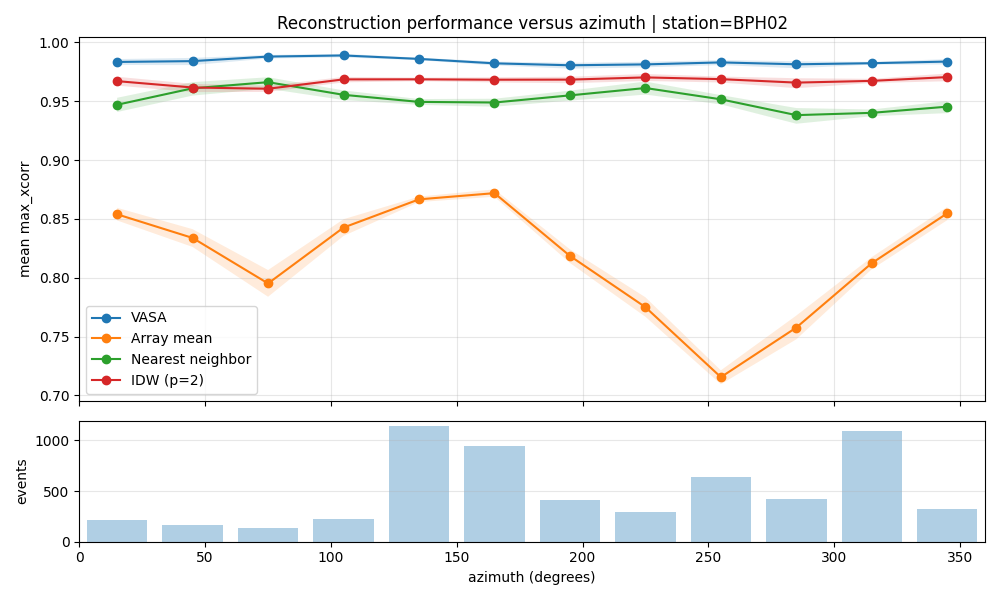

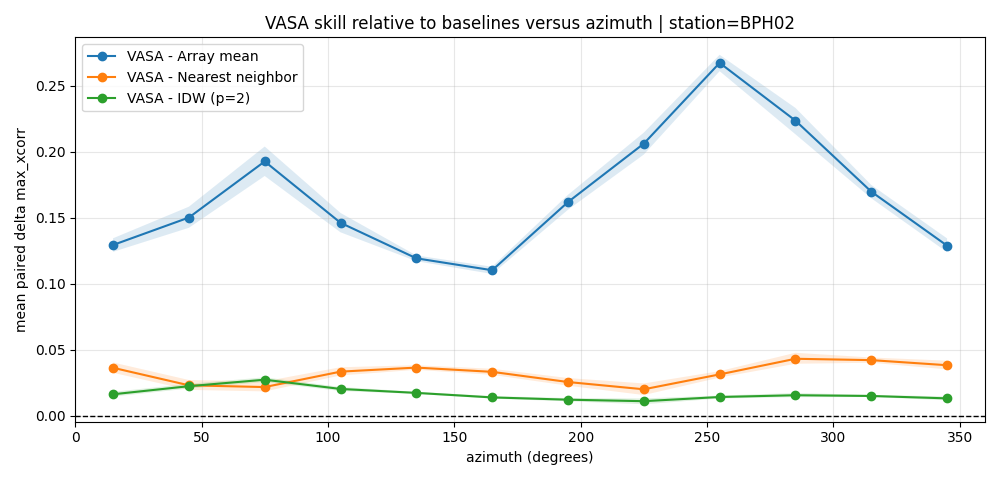

In [45]:
fig_dir = Path("Figures/VASA_v1_baselines")
fig_dir.mkdir(parents=True, exist_ok=True)

results_for_plotting = waveform_fidelity_results
# or, after a full saved run:
# results_for_plotting = waveform_fidelity_results_full

fig, axes, az_summary = plot_performance_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    metric="max_xcorr",
    target_station="BPH02",
    component=None,
)

fig.savefig(fig_dir / "performance_by_azimuth_BPH02_all_components.png", dpi=300, bbox_inches="tight")

fig, ax, skill_summary = plot_vasa_skill_over_baselines_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    target_station="BPH02",
    component=None,
)

fig.savefig(fig_dir / "vasa_skill_by_azimuth_BPH02_all_components.png", dpi=300, bbox_inches="tight")

print(f"Saved figures to {fig_dir.resolve()}")

Saved figures to /users/mronacgiannone/Virtual_Arrays/Figures/VASA_v1_baselines
CPU times: user 7.72 s, sys: 43.8 ms, total: 7.77 s
Wall time: 7.76 s


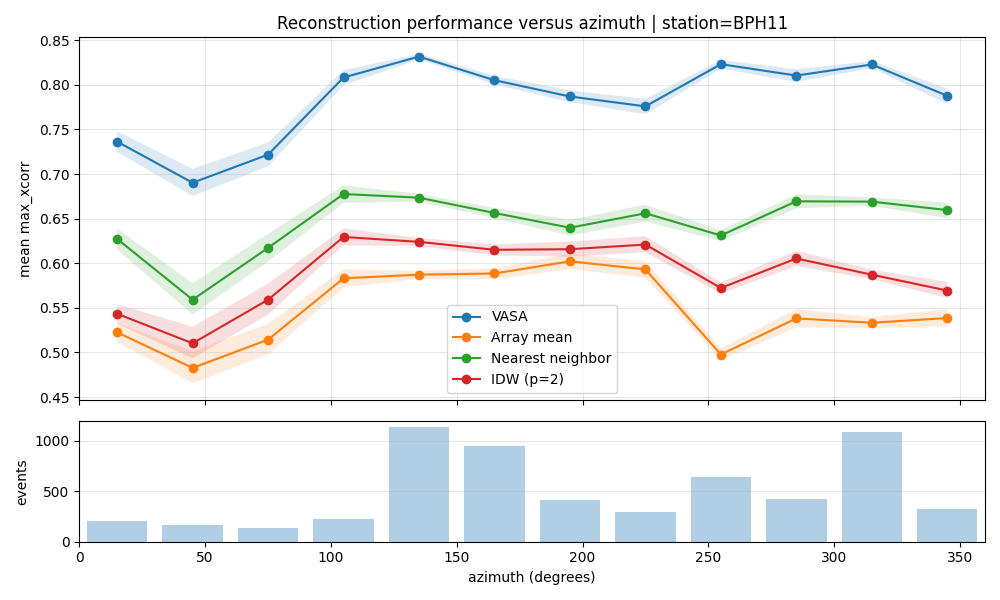

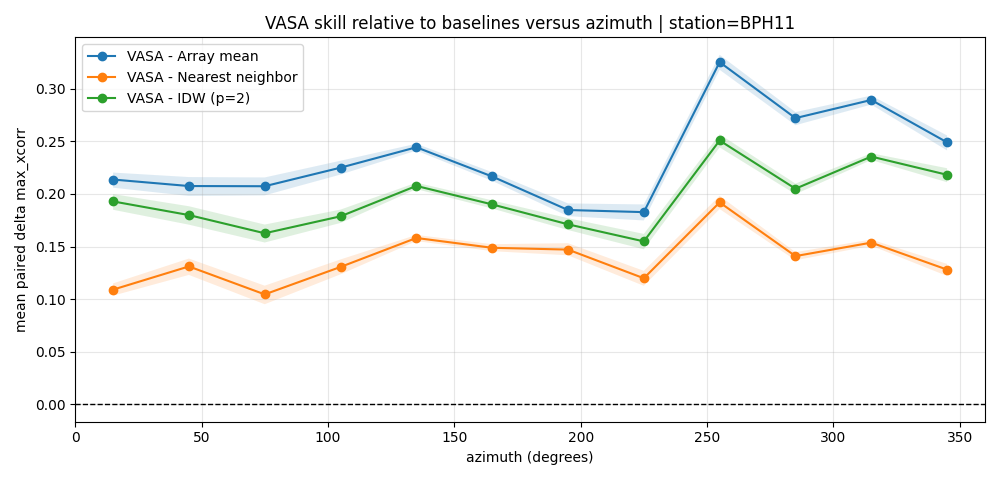

In [43]:
%%time
fig_dir = Path("Figures/VASA_v1_baselines")
fig_dir.mkdir(parents=True, exist_ok=True)

results_for_plotting = waveform_fidelity_results
# or, after a full saved run:
# results_for_plotting = waveform_fidelity_results_full

fig, axes, az_summary = plot_performance_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    metric="max_xcorr",
    target_station="BPH11",
    component=None,
)

fig.savefig(fig_dir / "performance_by_azimuth_BPH11_all_components.png", dpi=300, bbox_inches="tight")

fig, ax, skill_summary = plot_vasa_skill_over_baselines_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    target_station="BPH11",
    component=None,
)

fig.savefig(fig_dir / "vasa_skill_by_azimuth_BPH11_all_components.png", dpi=300, bbox_inches="tight")

print(f"Saved figures to {fig_dir.resolve()}")

---
Absolute best lag

CPU times: user 5.57 s, sys: 11 ms, total: 5.58 s
Wall time: 5.57 s


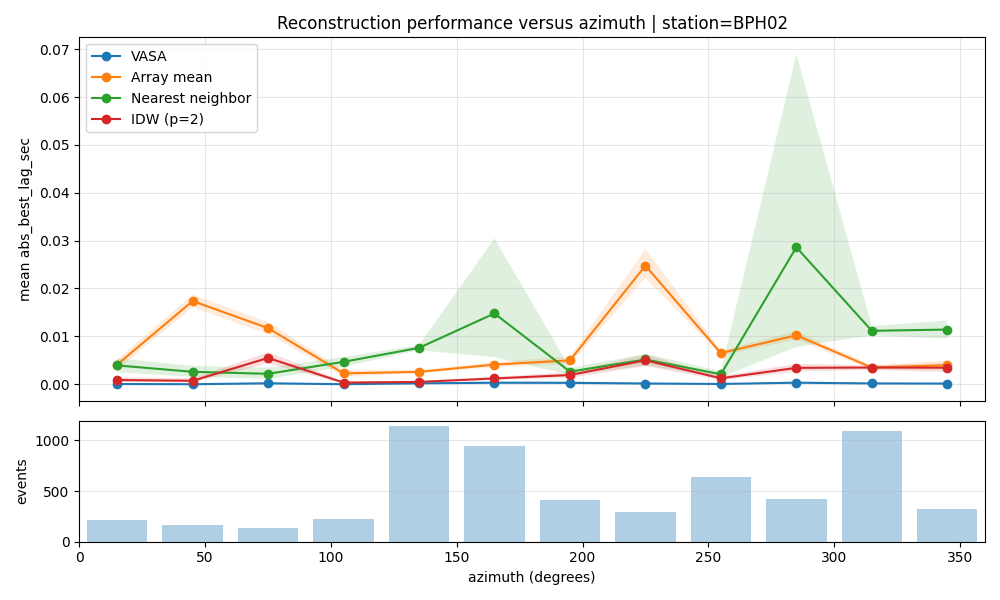

In [46]:
%%time
fig, axes, lag_az_summary = plot_performance_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    metric="abs_best_lag_sec",
    target_station="BPH02",
    component=None,
)

fig.savefig(
    fig_dir / "abs_lag_by_azimuth_BPH02_all_components.png",
    dpi=300,
    bbox_inches="tight",
)

CPU times: user 5.63 s, sys: 3.99 ms, total: 5.63 s
Wall time: 5.63 s


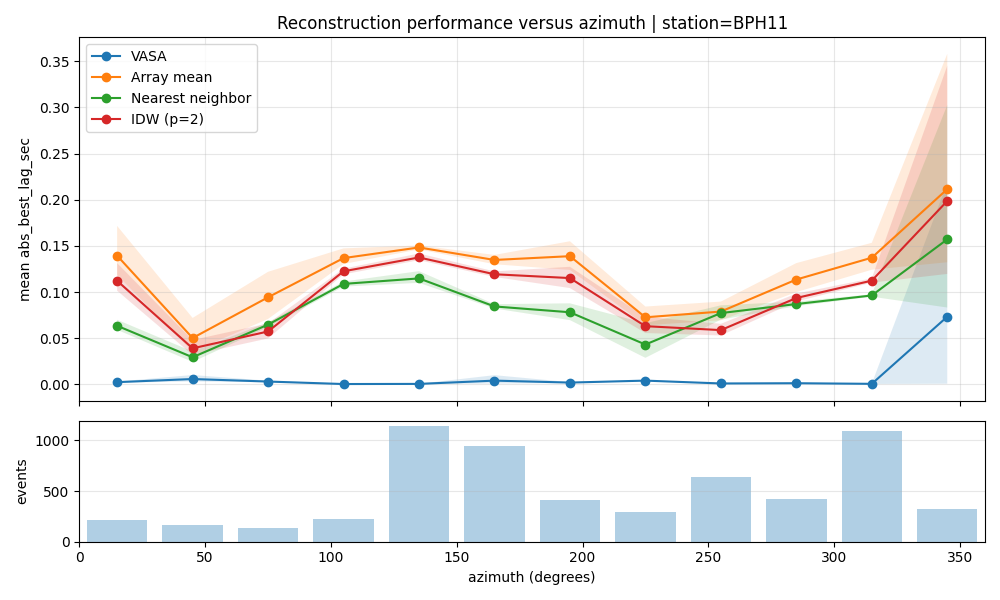

In [47]:
%%time
fig, axes, lag_az_summary = plot_performance_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    metric="abs_best_lag_sec",
    target_station="BPH11",
    component=None,
)

fig.savefig(
    fig_dir / "abs_lag_by_azimuth_BPH11_all_components.png",
    dpi=300,
    bbox_inches="tight",
)

---
RMS amplitude

CPU times: user 5.52 s, sys: 12.9 ms, total: 5.53 s
Wall time: 5.53 s


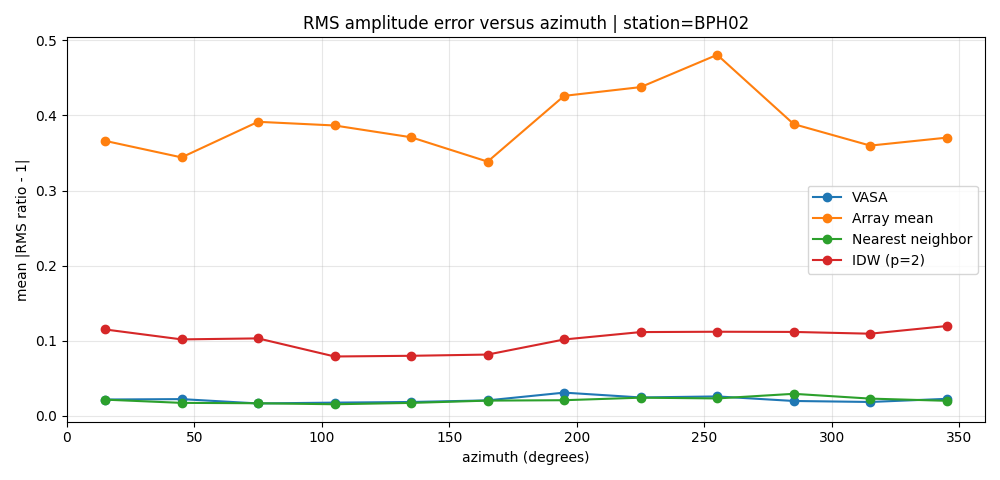

In [48]:
%%time
az_rms_summary = summarize_performance_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    target_station="BPH02",
    component=None,
)

fig, ax = plt.subplots(figsize=(10, 4.8))

method_order = ["VASA", "Array mean", "Nearest neighbor", "IDW (p=2)"]

for method in method_order:
    g = az_rms_summary[az_rms_summary["method"] == method]
    if g.empty:
        continue

    g = g.sort_values("azimuth_bin_center")
    ax.plot(
        g["azimuth_bin_center"],
        g["mean_abs_rms_ratio_error"],
        marker="o",
        label=method,
    )

ax.set_xlim(0, 360)
ax.set_xlabel("azimuth (degrees)")
ax.set_ylabel("mean |RMS ratio - 1|")
ax.set_title("RMS amplitude error versus azimuth | station=BPH02")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(
    fig_dir / "rms_amplitude_error_by_azimuth_BPH02_all_components.png",
    dpi=300,
    bbox_inches="tight",
)

CPU times: user 5.52 s, sys: 12 ms, total: 5.54 s
Wall time: 5.54 s


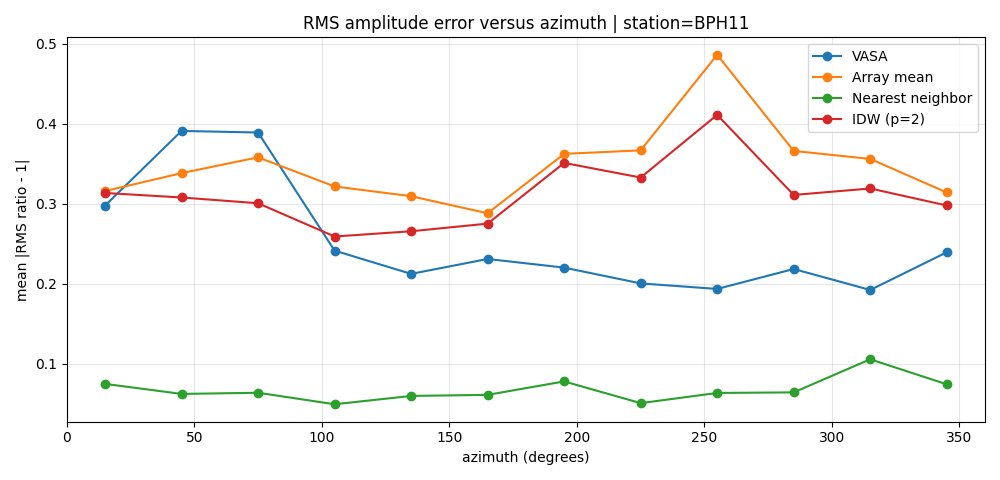

In [49]:
%%time
az_rms_summary = summarize_performance_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    target_station="BPH11",
    component=None,
)

fig, ax = plt.subplots(figsize=(10, 4.8))

method_order = ["VASA", "Array mean", "Nearest neighbor", "IDW (p=2)"]

for method in method_order:
    g = az_rms_summary[az_rms_summary["method"] == method]
    if g.empty:
        continue

    g = g.sort_values("azimuth_bin_center")
    ax.plot(
        g["azimuth_bin_center"],
        g["mean_abs_rms_ratio_error"],
        marker="o",
        label=method,
    )

ax.set_xlim(0, 360)
ax.set_xlabel("azimuth (degrees)")
ax.set_ylabel("mean |RMS ratio - 1|")
ax.set_title("RMS amplitude error versus azimuth | station=BPH11")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(
    fig_dir / "rms_amplitude_error_by_azimuth_BPH11_all_components.png",
    dpi=300,
    bbox_inches="tight",
)

---
Peak amplitude

CPU times: user 5.57 s, sys: 3.82 ms, total: 5.57 s
Wall time: 5.57 s


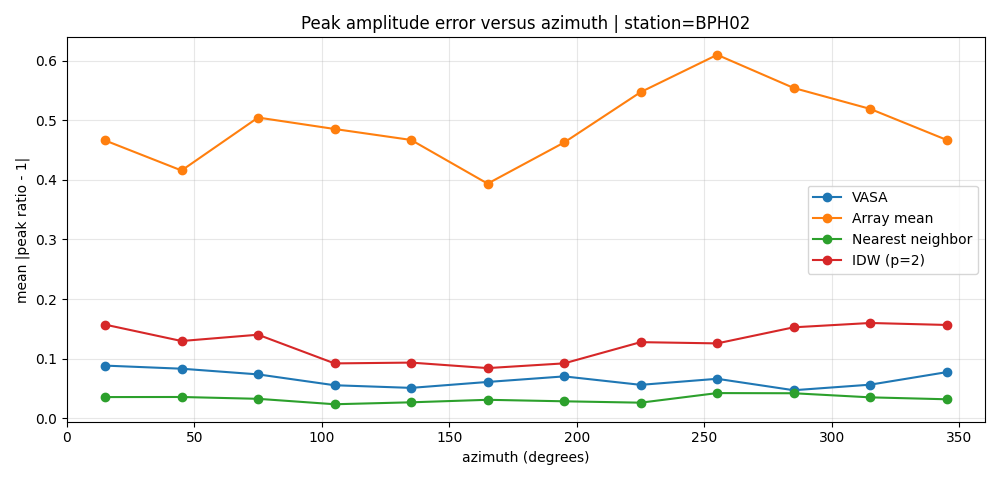

In [50]:
%%time
az_peak_summary = summarize_performance_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    target_station="BPH02",
    component=None,
)

fig, ax = plt.subplots(figsize=(10, 4.8))

method_order = ["VASA", "Array mean", "Nearest neighbor", "IDW (p=2)"]

for method in method_order:
    g = az_peak_summary[az_peak_summary["method"] == method]
    if g.empty:
        continue

    g = g.sort_values("azimuth_bin_center")
    ax.plot(
        g["azimuth_bin_center"],
        g["mean_abs_peak_ratio_error"],
        marker="o",
        label=method,
    )

ax.set_xlim(0, 360)
ax.set_xlabel("azimuth (degrees)")
ax.set_ylabel("mean |peak ratio - 1|")
ax.set_title("Peak amplitude error versus azimuth | station=BPH02")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(
    fig_dir / "peak_amplitude_error_by_azimuth_BPH02_all_components.png",
    dpi=300,
    bbox_inches="tight",
)

CPU times: user 5.5 s, sys: 13.1 ms, total: 5.51 s
Wall time: 5.51 s


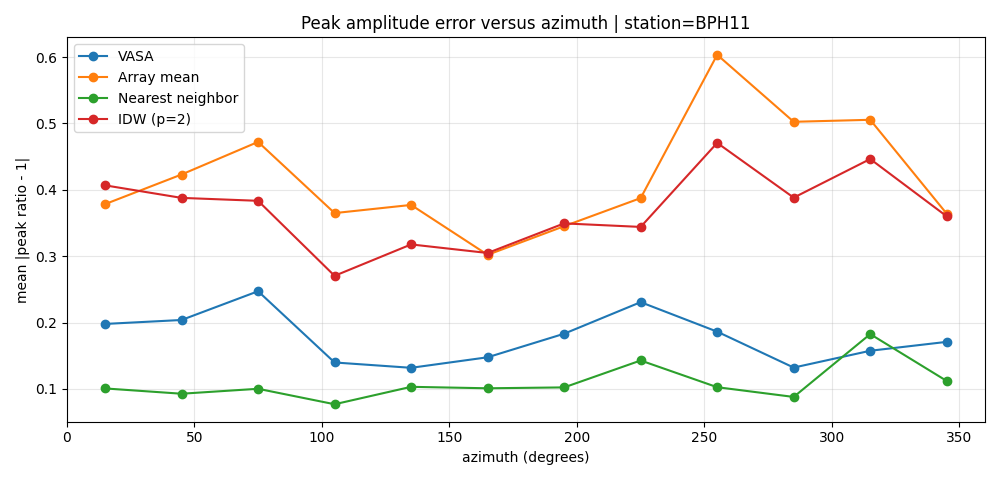

In [51]:
%%time
az_peak_summary = summarize_performance_by_azimuth(
    results_for_plotting,
    bin_width=30,
    statistic="mean",
    target_station="BPH11",
    component=None,
)

fig, ax = plt.subplots(figsize=(10, 4.8))

method_order = ["VASA", "Array mean", "Nearest neighbor", "IDW (p=2)"]

for method in method_order:
    g = az_peak_summary[az_peak_summary["method"] == method]
    if g.empty:
        continue

    g = g.sort_values("azimuth_bin_center")
    ax.plot(
        g["azimuth_bin_center"],
        g["mean_abs_peak_ratio_error"],
        marker="o",
        label=method,
    )

ax.set_xlim(0, 360)
ax.set_xlabel("azimuth (degrees)")
ax.set_ylabel("mean |peak ratio - 1|")
ax.set_title("Peak amplitude error versus azimuth | station=BPH11")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(
    fig_dir / "peak_amplitude_error_by_azimuth_BPH11_all_components.png",
    dpi=300,
    bbox_inches="tight",
)

---
Plot waveforms

In [3]:
%%time
def plot_vasa_v1_single_sensor_reconstruction(
    model,
    X_data,
    D_norm,
    global_center,
    global_scale,
    target_sensor=None,
    meta_df=None,
    station_order=None,
    event_index=None,
    EVID=None,
    seed=None,
    output_gain=1.0,
    final_clip=100.0,
    plot_inverse=True,
    sampling_rate=40.0,
    normalize_each_trace=False,
    save_fig=False,
    save_path=None,
    dpi=300,
    xlim=(0, 60),
    figsize=(16, 12),
    overlay_predictions_on_true=False,
):
    """
    Plot one VASA v1 reconstruction example.

    This version is optimized for the VASA v1 specialist model:
      - exactly one target sensor is masked
      - the other 9 sensors are used as context
      - no arbitrary multi-sensor masking is allowed

    X_data expected shape:
        [N, S, T, 3]

    target_sensor can be:
        - station name, e.g. "BPH11"
        - integer sensor index
        - None, in which case one target sensor is chosen randomly

    Metrics are computed only for the reconstructed target sensor:
      - max normalized cross-correlation
      - best lag at max xcorr
      - RMS amplitude ratio
      - peak amplitude ratio
    """
    rng = np.random.default_rng(seed)

    n_events, sensor_dim, temporal_dim, channel_dim = X_data.shape
    if channel_dim != 3:
        raise ValueError("X_data must have shape [N, S, T, 3].")

    if station_order is None:
        station_order = [f"S{i}" for i in range(sensor_dim)]

    if len(station_order) != sensor_dim:
        raise ValueError("station_order length must match sensor_dim.")

    if EVID is not None:
        if meta_df is None:
            raise ValueError("meta_df must be provided when selecting an event by EVID.")

        evid_col = "EVID" if "EVID" in meta_df.columns else "ev_id" if "ev_id" in meta_df.columns else None
        if evid_col is None:
            raise ValueError("meta_df must contain an 'EVID' or 'ev_id' column when selecting by EVID.")

        if event_index is not None:
            raise ValueError("Provide either event_index or EVID, not both.")

        def _normalize_evid(value):
            return (
                str(value)
                .strip()
                .replace("evid_", "")
                .replace(".0", "")
            )

        target_evid = _normalize_evid(EVID)
        evid_matches = meta_df[evid_col].apply(_normalize_evid) == target_evid

        if not evid_matches.any():
            raise ValueError(f"EVID {EVID!r} not found in meta_df.")

        event_index = int(np.flatnonzero(evid_matches.to_numpy())[0])

    if event_index is None:
        event_index = int(rng.integers(0, n_events))

    if target_sensor is None:
        target_sensor_index = int(rng.integers(0, sensor_dim))
    elif isinstance(target_sensor, str):
        if target_sensor not in station_order:
            raise ValueError(f"target_sensor {target_sensor!r} not found in station_order.")
        target_sensor_index = station_order.index(target_sensor)
    else:
        target_sensor_index = int(target_sensor)
        if not (0 <= target_sensor_index < sensor_dim):
            raise ValueError(f"target_sensor index {target_sensor_index} out of range.")

    masked_indices = [target_sensor_index]
    observed_indices = [i for i in range(sensor_dim) if i != target_sensor_index]

    reconstructed_stations = [station_order[target_sensor_index]]
    observed_stations = [station_order[i] for i in observed_indices]

    x_clean = X_data[event_index].astype(np.float32)

    event_info = None
    title_line_1 = f"Event {event_index}"

    if meta_df is not None:
        event_info = meta_df.iloc[event_index]

        evid = event_info.get("EVID", event_info.get("ev_id", "NA"))
        date_str = event_info.get("YY/MM/DD", event_info.get("YYY/MM/DD", "NA"))
        mag = event_info.get("MAG", "NA")
        dist_km = event_info.get("distance_km", "NA")
        az = event_info.get("azimuth_deg", None)

        mag_str = f"{float(mag):.2f}" if pd.notna(mag) else "NA"
        dist_str = f"{float(dist_km):.1f} km" if pd.notna(dist_km) else "NA"

        title_line_1 = f"EVID: {evid} | Date: {date_str} | Dist: {dist_str} | M: {mag_str}"

        if az is not None and pd.notna(az):
            az_plot = float(az) % 360.0
            title_line_1 += f" | BAZ: {az_plot:.1f}°"

    title_line_2 = (
        f"Observed sensors: 9 | "
        f"Reconstructed sensor: {station_order[target_sensor_index]}"
    )

    x_scaled = VASA.global_asinh_scale(
        tf.constant(x_clean, dtype=tf.float32),
        global_center=tf.constant(global_center, dtype=tf.float32),
        global_scale=tf.constant(global_scale, dtype=tf.float32),
        output_gain=output_gain,
        final_clip=final_clip,
    ).numpy().astype(np.float32)

    observed_mask = np.ones_like(x_scaled, dtype=np.float32)
    observed_mask[target_sensor_index, :, :] = 0.0

    x_observed_scaled = x_scaled * observed_mask

    x_model = np.concatenate(
        [x_observed_scaled, observed_mask],
        axis=-1,
    )[None, ...].astype(np.float32)

    d_model = np.asarray(D_norm, dtype=np.float32)[None, ...]

    preds = model.predict(
        {
            "seismic_input": x_model,
            "distance_input": d_model,
        },
        verbose=0,
    )

    y_pred_scaled = VASA.get_3branch_predictions(preds)[0].astype(np.float32)

    if plot_inverse:
        true_plot = VASA.inverse_global_asinh_scale(
            x_scaled,
            global_center,
            global_scale,
            output_gain,
        )
        pred_plot = VASA.inverse_global_asinh_scale(
            y_pred_scaled,
            global_center,
            global_scale,
            output_gain,
        )
        observed_plot = VASA.inverse_global_asinh_scale(
            x_observed_scaled,
            global_center,
            global_scale,
            output_gain,
        )
        title_suffix = "0.5 - 5 Hz"
    else:
        true_plot = x_scaled
        pred_plot = y_pred_scaled
        observed_plot = x_observed_scaled
        title_suffix = "scaled model space"

    component_names = ["BHZ", "BHN", "BHE"]
    time = np.arange(temporal_dim) / sampling_rate

    def _norm_rows(x, eps=1e-12):
        scale = np.max(np.abs(x), axis=1, keepdims=True) + eps
        return x / scale

    if overlay_predictions_on_true:
        fig, axes = plt.subplots(
            3,
            1,
            figsize=figsize,
            sharex=True,
            clear=True,
        )
    else:
        fig, axes = plt.subplots(
            3,
            2,
            figsize=figsize,
            sharex=True,
            clear=True,
        )

    metrics = {}

    for ci, comp_name in enumerate(component_names):
        true_comp_metric = true_plot[:, :, ci].copy()
        pred_comp_metric = pred_plot[:, :, ci].copy()
        obs_comp_metric = observed_plot[:, :, ci].copy()

        true_comp = true_comp_metric.copy()
        pred_comp = pred_comp_metric.copy()
        obs_comp = obs_comp_metric.copy()

        if normalize_each_trace:
            true_comp = _norm_rows(true_comp)
            pred_comp = _norm_rows(pred_comp)
            obs_comp = _norm_rows(obs_comp)

        global_max = max(
            np.max(np.abs(true_comp)),
            np.max(np.abs(pred_comp)),
            1e-12,
        )

        spacing = 2.0 * global_max
        offsets = np.arange(sensor_dim)[::-1] * spacing

        y_min = -0.8 * spacing
        y_max = offsets[0] + 0.45 * spacing

        if overlay_predictions_on_true:
            left_ax = axes[ci]
            right_ax = None
        else:
            left_ax = axes[ci, 0]
            right_ax = axes[ci, 1]

        for si in range(sensor_dim):
            color = "royalblue" if si in observed_indices else "black"
            alpha = 1.0 if si in observed_indices else 0.85

            left_ax.plot(
                time,
                true_comp[si] + offsets[si],
                color=color,
                linewidth=1.0,
                alpha=alpha,
            )

            if overlay_predictions_on_true and si == target_sensor_index:
                left_ax.plot(
                    time,
                    pred_comp[si] + offsets[si],
                    color="crimson",
                    linewidth=1.2,
                    alpha=0.95,
                )

        if not overlay_predictions_on_true:
            left_ax.set_title(f"True {comp_name}", fontsize=11, pad=8)

            for si in observed_indices:
                right_ax.plot(
                    time,
                    obs_comp[si] + offsets[si],
                    color="royalblue",
                    linewidth=1.0,
                    alpha=1.0,
                )

            right_ax.plot(
                time,
                pred_comp[target_sensor_index] + offsets[target_sensor_index],
                color="crimson",
                linewidth=1.2,
                alpha=0.95,
            )

        lags_sec, x_corr = VASA.norm_xcorr(
            time,
            true_comp_metric[target_sensor_index],
            pred_comp_metric[target_sensor_index],
        )

        best_idx = int(np.argmax(x_corr))
        max_corr = float(x_corr[best_idx])
        best_lag_sec = float(lags_sec[best_idx])

        ratios = VASA.raw_amplitude_ratios(
            true_comp_metric[target_sensor_index],
            pred_comp_metric[target_sensor_index],
        )

        metrics[comp_name] = {
            "max_corr": max_corr,
            "best_lag_sec": best_lag_sec,
            "rms_ratio": float(ratios["rms_ratio"]),
            "peak_ratio": float(ratios["peak_ratio"]),
            "target_station": station_order[target_sensor_index],
        }

        metric_title = (
            f"corr = {max_corr:.3f} | "
            f"lag = {best_lag_sec:.4f} s | "
            f"RMS ratio = {ratios['rms_ratio']:.3f} | "
            f"peak ratio = {ratios['peak_ratio']:.3f}"
        )

        if overlay_predictions_on_true:
            left_ax.set_title(
                f"True and Reconstructed {comp_name}\n{metric_title}",
                fontsize=10,
                pad=8,
            )
        else:
            right_ax.set_title(
                f"Reconstructed {comp_name}\n{metric_title}",
                fontsize=10,
                pad=8,
            )

        left_ax.set_ylabel("")
        left_ax.set_yticks(offsets)
        left_ax.set_yticklabels(station_order)
        left_ax.grid(alpha=0.25)
        left_ax.set_xlim(xlim)
        left_ax.set_ylim(y_min, y_max)

        if not overlay_predictions_on_true:
            right_ax.set_ylabel("")
            right_ax.set_yticks(offsets)
            right_ax.set_yticklabels(station_order)
            right_ax.grid(alpha=0.25)
            right_ax.set_xlim(xlim)
            right_ax.set_ylim(y_min, y_max)

    fig.suptitle(
        f"{title_line_1} | {title_line_2} | {title_suffix}",
        fontsize=10,
        y=0.935,
    )

    if overlay_predictions_on_true:
        axes[-1].set_xlabel("")
    else:
        axes[-1, 0].set_xlabel("")
        axes[-1, 1].set_xlabel("")

    plt.xlabel("Time (s)")
    fig.tight_layout(rect=[0, 0, 1, 0.943])

    if save_fig:
        if save_path is None:
            save_path = (
                f"vasa_v1_reconstruction_event_{event_index}_"
                f"target_{station_order[target_sensor_index]}.png"
            )

        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved figure: {save_path}")

    plt.show()

    return {
        "event_index": event_index,
        "event_idx": event_index,
        "target_sensor_index": target_sensor_index,
        "target_station": station_order[target_sensor_index],
        "observed_indices": observed_indices,
        "observed_stations": observed_stations,
        "masked_indices": masked_indices,
        "reconstructed_stations": reconstructed_stations,
        "event_info": event_info,
        "x_model": x_model,
        "observed_mask": observed_mask,
        "true_scaled": x_scaled,
        "prediction_scaled": y_pred_scaled,
        "true_plot": true_plot,
        "pred_plot": pred_plot,
        "observed_plot": observed_plot,
        "metrics": metrics,
        "figure": fig,
        "axes": axes,
        "save_path": save_path if save_fig else None,
    }

CPU times: user 96 μs, sys: 0 ns, total: 96 μs
Wall time: 111 μs


Saved figure: Figures/VASA_v1/Waveform_Fidelity/Example_2326_Context_Sensors_BPH02_Temporal_Offset.png


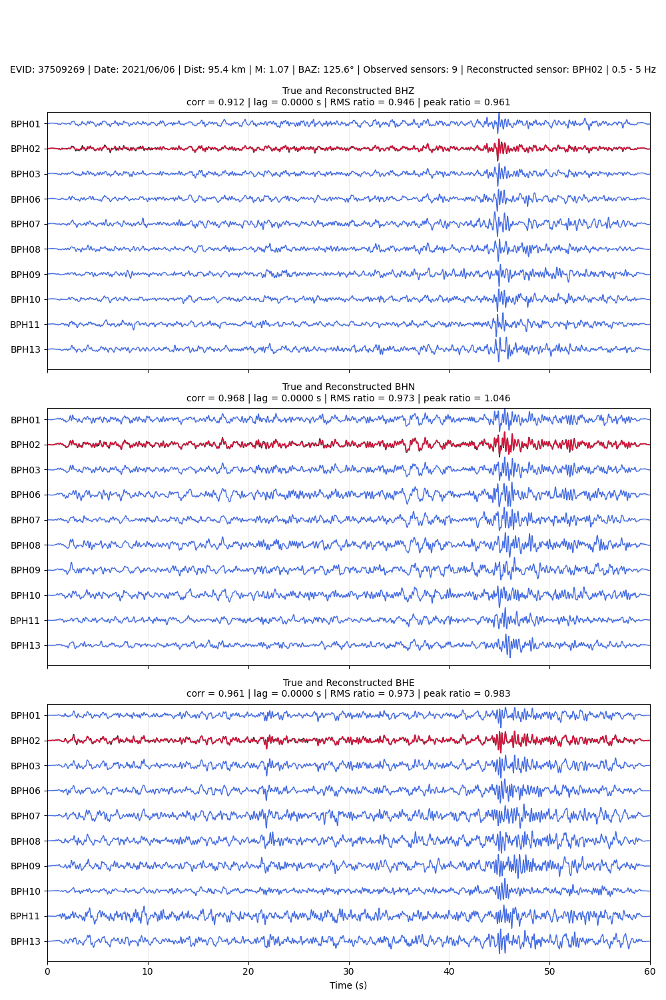

2326
CPU times: user 1.98 s, sys: 331 ms, total: 2.31 s
Wall time: 1.57 s


In [40]:
%%time
# v1 model reconstruction - BPH02
# Examples: 37574684/58 (manuscript); 37277007/5045 (surface waves - supplemental material)
result = plot_vasa_v1_single_sensor_reconstruction(
    model=vasa_v1,
    X_data=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    target_sensor="BPH02",
    meta_df=meta_test,
    station_order=station_order,
    EVID=37509269, # 39121247 - best one, impulsive noise at one sensor-component, suppresses it, also doesn't reconstruct impulsive noise seen on other context sensor
    # 39131887 - impulsive noise coherent across array is reconstructed
    # 37708479 - multievent after
    # 37509269 - temporal offset
    final_clip=100.0,
    plot_inverse=True,
    normalize_each_trace=True,
    xlim=(0, 60), # 7.5, 45
    overlay_predictions_on_true=True,
    figsize=(10,15),
    save_fig=True,
    save_path="Figures/VASA_v1/Waveform_Fidelity/Example_2326_Context_Sensors_BPH02_Temporal_Offset.png"
)
print(result["event_idx"])

Saved figure: Figures/VASA_v1/Waveform_Fidelity/Example_2326_BPH02_Temporal_Offset.png


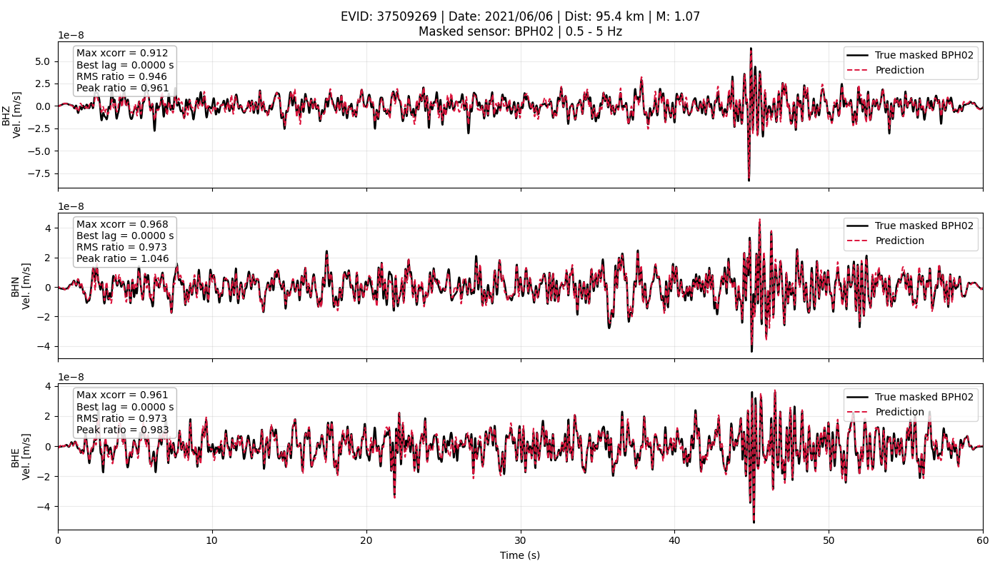

CPU times: user 1.78 s, sys: 97.4 ms, total: 1.88 s
Wall time: 1.16 s


In [41]:
%%time
# Plot single sensor oberved and reconstructed
event_idx = result["event_idx"]
rec_sensor = "BPH02"; rec_sensor_idx = 1
_ = VASA.plot_random_test_reconstruction(
    model=vasa_v1,
    X_test=X_test,
    meta_test=meta_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    station_order=station_order,
    final_clip=100.0,
    event_index=event_idx, 
    sensor_index=rec_sensor_idx,
    seed=42,
    plot_inverse=True,
    show_context_sensors=False,
    save_fig=True,
    save_path="Figures/VASA_v1/Waveform_Fidelity/Example_"+str(event_idx)+"_BPH02_Temporal_Offset.png",
    legend_locs=["upper right", "upper right", "upper right"],
    metric_text_locs=["upper left", "upper left", "upper left"]
) 

Saved figure: Figures/VASA_v1/Waveform_Fidelity/Example_2326_Context_Sensors_BPH11_Temporal_Offset.png


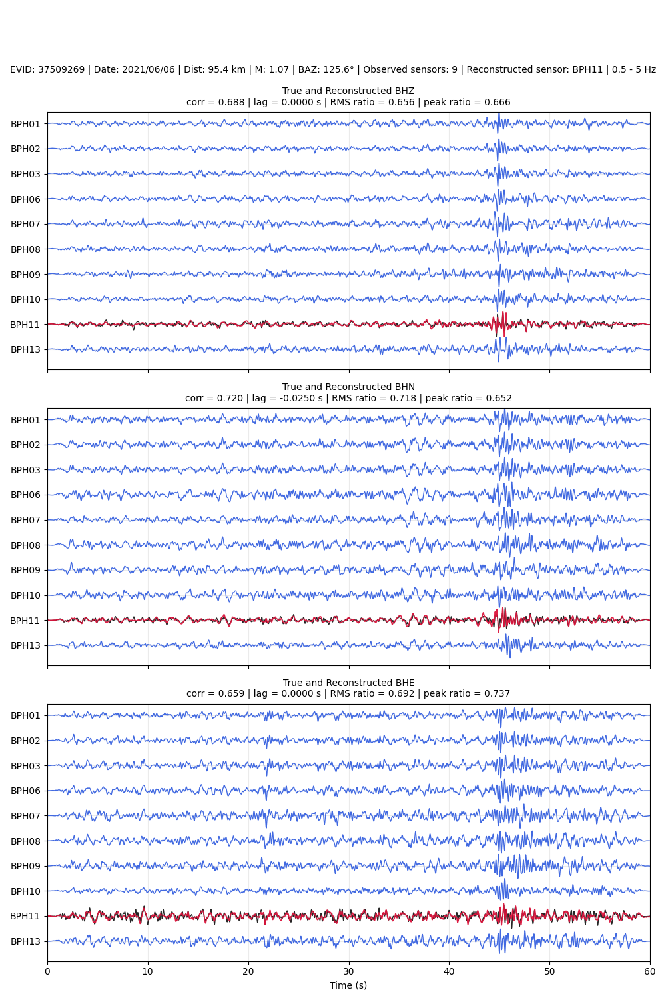

2326
CPU times: user 2.08 s, sys: 166 ms, total: 2.25 s
Wall time: 1.57 s


In [42]:
%%time
# v1 model reconstruction - BPH11
result = plot_vasa_v1_single_sensor_reconstruction(
    model=vasa_v1,
    X_data=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    target_sensor="BPH11",
    meta_df=meta_test,
    station_order=station_order,
    EVID=37509269,
    final_clip=100.0,
    plot_inverse=True,
    normalize_each_trace=True,
    xlim=(0, 60),
    overlay_predictions_on_true=True,
    figsize=(10,15),
    save_fig=True,
    save_path="Figures/VASA_v1/Waveform_Fidelity/Example_2326_Context_Sensors_BPH11_Temporal_Offset.png"
)
print(result["event_idx"])

Saved figure: Figures/VASA_v1/Waveform_Fidelity/Example_2326_BPH11_Temporal_Offset.png


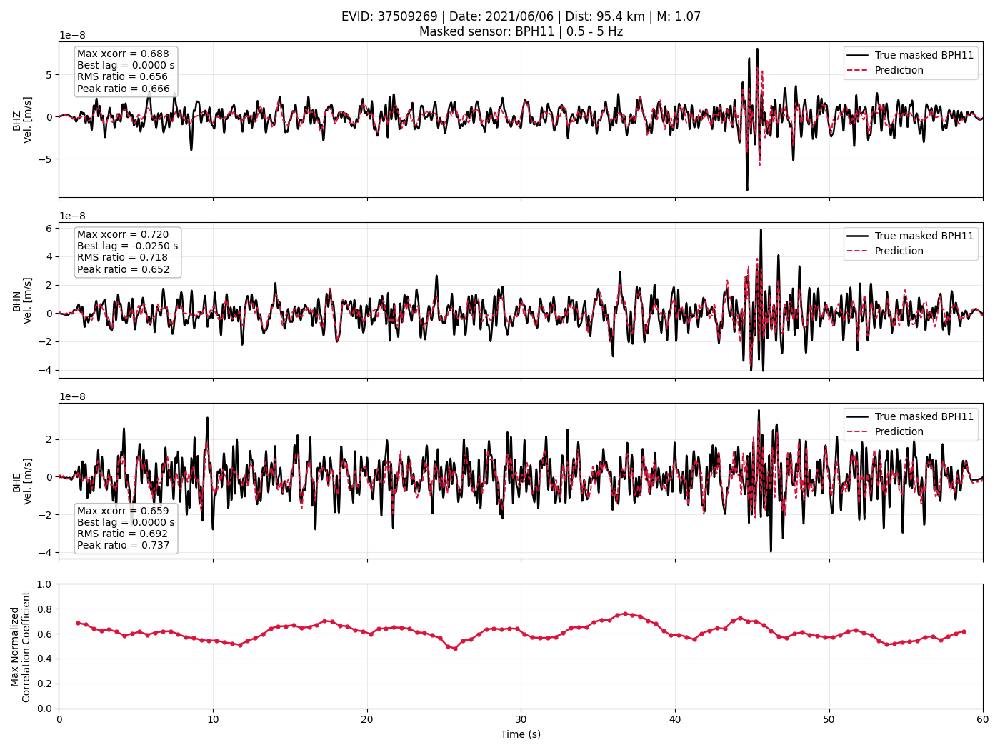

CPU times: user 5.13 s, sys: 163 ms, total: 5.3 s
Wall time: 4.57 s


In [43]:
%%time
# Plot single sensor oberved and reconstructed
event_idx = result["event_idx"]
rec_sensor = "BPH11"; rec_sensor_idx = 8
_ = VASA.plot_random_test_reconstruction(
    model=vasa_v1,
    X_test=X_test,
    meta_test=meta_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    station_order=station_order,
    final_clip=100.0,
    event_index=event_idx, 
    sensor_index=rec_sensor_idx,
    seed=42,
    plot_inverse=True,
    show_context_sensors=False,
    save_fig=True,
    save_path="Figures/VASA_v1/Waveform_Fidelity/Example_"+str(event_idx)+"_BPH11_Temporal_Offset.png",
    legend_locs=["upper right", "upper right", "upper right"],
    metric_text_locs=["upper left", "upper left", "lower left"],
    plot_array_coherence=True,
    coherence_include_target=True,
    coherence_use_reconstructed_target=False,
    coherence_window_length=2.5,
    coherence_step=0.5,
    coherence_component="all",

) 

---
Array processing

In [44]:
%%time
st_full_z, st_masked_z, st_rec_z, info = VASA.build_obspy_streams_for_multisensor_reconstruction(
    model=vasa_v1,
    X_data=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    station_order=station_order,
    site_file="PFO.site",
    component="Z",
    event_index=result["event_idx"],
    observed_sensors=["BPH01","BPH02","BPH03","BPH06","BPH07","BPH08","BPH09","BPH10","BPH13"],
    meta_df=meta_test,
    output_gain=1.0,
    final_clip=100.0,
    plot_inverse=True,
    sampling_rate=40.0,
)

print(st_full_z)
print(st_masked_z)
print(st_rec_z)

10 Trace(s) in Stream:
XX.BPH01..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 samples
XX.BPH02..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 samples
XX.BPH03..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 samples
XX.BPH06..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 samples
XX.BPH07..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 samples
XX.BPH08..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 samples
XX.BPH09..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 samples
XX.BPH10..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 samples
XX.BPH11..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 samples
XX.BPH13..BHZ | 2021-06-06T00:26:41.030000Z - 2021-06-06T00:27:41.005000Z | 40.0 Hz, 2400 sampl

In [45]:
%%time
def subset_geometry_for_stream(st, station_order, x_km_full, y_km_full):
    """
    Return x_km, y_km arrays that match the stations present in `st`,
    in the exact same order as the stream traces.
    """
    geom_map = {
        sta: (float(x), float(y))
        for sta, x, y in zip(station_order, x_km_full, y_km_full)
    }

    stream_stations = [tr.stats.station for tr in st]

    missing = [sta for sta in stream_stations if sta not in geom_map]
    if missing:
        raise ValueError(f"Stations missing from geometry map: {missing}")

    x_km_sub = np.array([geom_map[sta][0] for sta in stream_stations], dtype=float)
    y_km_sub = np.array([geom_map[sta][1] for sta in stream_stations], dtype=float)

    return x_km_sub, y_km_sub

CPU times: user 22 μs, sys: 2 μs, total: 24 μs
Wall time: 30.5 μs


Array centroid: lat=33.6101°, lon=-116.4555°
Array aperture: Δx=0.750 km, Δy=0.789 km, Δ=1.089 km
Number of sensors: 10
CPU times: user 272 ms, sys: 12 ms, total: 285 ms
Wall time: 284 ms


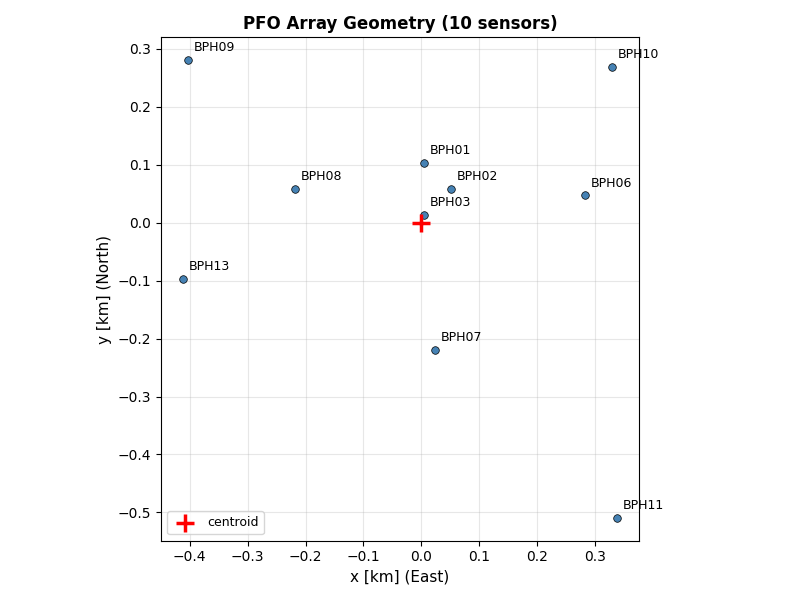

In [46]:
%%time
# Full-array geometry from the full stream
x_km_full, y_km_full = VASA.plot_array_geometry(
    st_full_z,
    figsize=(8, 6),
    fname="Figures/PFO_Array_Geometry.png"
)

# Geometry matched to each stream
x_km_full_use, y_km_full_use = subset_geometry_for_stream(
    st_full_z, station_order, x_km_full, y_km_full
)

x_km_masked, y_km_masked = subset_geometry_for_stream(
    st_masked_z, station_order, x_km_full, y_km_full
)

x_km_rec, y_km_rec = subset_geometry_for_stream(
    st_rec_z, station_order, x_km_full, y_km_full
)

---
Plotting residuals for full waveform sliding window fk using full array as baseline

In [47]:
%%time
# F-K parameters
FK_FREQ_MIN = 0.5  # Hz
FK_FREQ_MAX = 5.0  # Hz
FK_SMAX = 1.0      # s/km
FK_NGRID = 150

# Sliding window parameters
FK_WINDOW_LENGTH = 5.0    # seconds
FK_OVERLAP_PERCENT = 90.0  # percent

# Full FK
T_full, B_full, V_full, S_full = VASA.sliding_window_fk(
    st=st_full_z,
    x_km=x_km_full_use,
    y_km=y_km_full_use,
    freq_min=FK_FREQ_MIN,
    freq_max=FK_FREQ_MAX,
    smax=FK_SMAX,
    ngrid=FK_NGRID,
    window_length=FK_WINDOW_LENGTH,
    overlap_percent=FK_OVERLAP_PERCENT
)

# Masked FK
T_masked, B_masked, V_masked, S_masked = VASA.sliding_window_fk(
    st=st_masked_z,
    x_km=x_km_masked,
    y_km=y_km_masked,
    freq_min=FK_FREQ_MIN,
    freq_max=FK_FREQ_MAX,
    smax=FK_SMAX,
    ngrid=FK_NGRID,
    window_length=FK_WINDOW_LENGTH,
    overlap_percent=FK_OVERLAP_PERCENT
)

# Reconstructed FK
T_rec, B_rec, V_rec, S_rec = VASA.sliding_window_fk(
    st=st_rec_z,
    x_km=x_km_rec,
    y_km=y_km_rec,
    freq_min=FK_FREQ_MIN,
    freq_max=FK_FREQ_MAX,
    smax=FK_SMAX,
    ngrid=FK_NGRID,
    window_length=FK_WINDOW_LENGTH,
    overlap_percent=FK_OVERLAP_PERCENT
)

Running sliding window F-K analysis...
  Window: 5.0s, Overlap: 90.0%
  Note: First run may be slower due to JIT compilation

✓ Complete!
Running sliding window F-K analysis...
  Window: 5.0s, Overlap: 90.0%
  Note: First run may be slower due to JIT compilation

✓ Complete!
Running sliding window F-K analysis...
  Window: 5.0s, Overlap: 90.0%
  Note: First run may be slower due to JIT compilation

✓ Complete!
CPU times: user 5.13 s, sys: 79.9 ms, total: 5.21 s
Wall time: 5.21 s


In [48]:
%%time
def circular_residual_deg(angle_deg, ref_deg):
    """
    Circular residual in degrees, wrapped to [-180, 180).
    """
    angle_deg = np.asarray(angle_deg, dtype=float)
    ref_deg = np.asarray(ref_deg, dtype=float)
    return ((angle_deg - ref_deg + 180.0) % 360.0) - 180.0


def _interp_linear(x_ref, y_ref, x_new):
    """
    Linear interpolation with NaN-safe finite masking.
    """
    x_ref = np.asarray(x_ref, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)
    x_new = np.asarray(x_new, dtype=float)

    keep = np.isfinite(x_ref) & np.isfinite(y_ref)
    if np.sum(keep) < 2:
        return np.full_like(x_new, np.nan, dtype=float)

    return np.interp(x_new, x_ref[keep], y_ref[keep], left=np.nan, right=np.nan)


def _interp_circular_deg(x_ref, angle_ref_deg, x_new):
    """
    Interpolate circular angles in degrees by interpolating unit vectors.
    """
    x_ref = np.asarray(x_ref, dtype=float)
    angle_ref_deg = np.asarray(angle_ref_deg, dtype=float)
    x_new = np.asarray(x_new, dtype=float)

    keep = np.isfinite(x_ref) & np.isfinite(angle_ref_deg)
    if np.sum(keep) < 2:
        return np.full_like(x_new, np.nan, dtype=float)

    ang_rad = np.deg2rad(angle_ref_deg[keep] % 360.0)
    cos_ref = np.cos(ang_rad)
    sin_ref = np.sin(ang_rad)

    cos_new = np.interp(x_new, x_ref[keep], cos_ref, left=np.nan, right=np.nan)
    sin_new = np.interp(x_new, x_ref[keep], sin_ref, left=np.nan, right=np.nan)

    out = (np.rad2deg(np.arctan2(sin_new, cos_new)) + 360.0) % 360.0
    bad = ~np.isfinite(cos_new) | ~np.isfinite(sin_new)
    out[bad] = np.nan
    return out


def plot_fk_full_vs_masked_vs_reconstructed_residuals(
    st_full,
    st_masked,
    st_rec,
    element,
    T_full, B_full, V_full, S_full,
    T_masked, B_masked, V_masked, S_masked,
    T_rec, B_rec, V_rec, S_rec,
    baz_truth_deg,
    semblance_threshold=0.5,
    residual_mae_clip_deg=180.0,
    baz_ylim=(-180, 180),
    vel_ylim=(1, 8),
    xlim=None,
    figsize=(12, 10),
    fname=None,
):
    """
    Compare masked-array and reconstructed-array FK results against
    the full-array FK baseline.

    Panels:
    1. Full-array waveform for one selected element
    2. Full-array FK BAZ through time + ground-truth source BAZ
    3. BAZ residuals relative to full-array FK
    4. Phase velocity comparison relative to full-array FK timing

    Residual convention:
        residual = test_array_BAZ - full_array_BAZ

    Negative delta MAE means reconstruction improved relative to masked.
    """

    baz_truth_deg = float(baz_truth_deg) % 360.0

    # --------------------------------------------------
    # Get waveform from requested element
    # --------------------------------------------------
    tr_full = st_full.select(station=element)[0]
    t_full_wf = np.arange(tr_full.stats.npts) * tr_full.stats.delta
    wf_full = tr_full.data / (np.max(np.abs(tr_full.data)) + 1e-12)

    # --------------------------------------------------
    # Convert to arrays
    # --------------------------------------------------
    T_full = np.asarray(T_full, dtype=float)
    B_full = np.asarray(B_full, dtype=float) % 360.0
    V_full = np.asarray(V_full, dtype=float)
    S_full = np.asarray(S_full, dtype=float)

    T_masked = np.asarray(T_masked, dtype=float)
    B_masked = np.asarray(B_masked, dtype=float) % 360.0
    V_masked = np.asarray(V_masked, dtype=float)
    S_masked = np.asarray(S_masked, dtype=float)

    T_rec = np.asarray(T_rec, dtype=float)
    B_rec = np.asarray(B_rec, dtype=float) % 360.0
    V_rec = np.asarray(V_rec, dtype=float)
    S_rec = np.asarray(S_rec, dtype=float)

    # --------------------------------------------------
    # Interpolate full-array FK onto masked/reconstructed windows
    # --------------------------------------------------
    B_full_on_masked = _interp_circular_deg(T_full, B_full, T_masked)
    B_full_on_rec = _interp_circular_deg(T_full, B_full, T_rec)

    V_full_on_masked = _interp_linear(T_full, V_full, T_masked)
    V_full_on_rec = _interp_linear(T_full, V_full, T_rec)

    S_full_on_masked = _interp_linear(T_full, S_full, T_masked)
    S_full_on_rec = _interp_linear(T_full, S_full, T_rec)

    # --------------------------------------------------
    # Residuals relative to full-array FK
    # --------------------------------------------------
    baz_res_masked = circular_residual_deg(B_masked, B_full_on_masked)
    baz_res_rec = circular_residual_deg(B_rec, B_full_on_rec)

    # --------------------------------------------------
    # Plotting masks
    # --------------------------------------------------
    keep_full = (
        np.isfinite(T_full) &
        np.isfinite(B_full) &
        np.isfinite(V_full) &
        np.isfinite(S_full)
    )

    if semblance_threshold is not None:
        keep_masked = (
            np.isfinite(T_masked) &
            np.isfinite(B_masked) &
            np.isfinite(V_masked) &
            np.isfinite(S_masked) &
            np.isfinite(B_full_on_masked) &
            np.isfinite(V_full_on_masked) &
            np.isfinite(S_full_on_masked) &
            (S_masked > semblance_threshold) &
            (S_full_on_masked > semblance_threshold)
        )
        keep_rec = (
            np.isfinite(T_rec) &
            np.isfinite(B_rec) &
            np.isfinite(V_rec) &
            np.isfinite(S_rec) &
            np.isfinite(B_full_on_rec) &
            np.isfinite(V_full_on_rec) &
            np.isfinite(S_full_on_rec) &
            (S_rec > semblance_threshold) &
            (S_full_on_rec > semblance_threshold)
        )
        keep_full = keep_full & (S_full > semblance_threshold)
    else:
        keep_masked = (
            np.isfinite(T_masked) &
            np.isfinite(B_masked) &
            np.isfinite(V_masked) &
            np.isfinite(S_masked) &
            np.isfinite(B_full_on_masked) &
            np.isfinite(V_full_on_masked)
        )
        keep_rec = (
            np.isfinite(T_rec) &
            np.isfinite(B_rec) &
            np.isfinite(V_rec) &
            np.isfinite(S_rec) &
            np.isfinite(B_full_on_rec) &
            np.isfinite(V_full_on_rec)
        )

    mae_mask_masked = keep_masked & (np.abs(baz_res_masked) <= residual_mae_clip_deg)
    mae_mask_rec = keep_rec & (np.abs(baz_res_rec) <= residual_mae_clip_deg)

    masked_baz_mae = (
        np.mean(np.abs(baz_res_masked[mae_mask_masked]))
        if np.any(mae_mask_masked) else np.nan
    )
    rec_baz_mae = (
        np.mean(np.abs(baz_res_rec[mae_mask_rec]))
        if np.any(mae_mask_rec) else np.nan
    )
    baz_delta_mae = rec_baz_mae - masked_baz_mae

    masked_pv_mae = (
        np.mean(np.abs(V_masked[keep_masked] - V_full_on_masked[keep_masked]))
        if np.any(keep_masked) else np.nan
    )
    rec_pv_mae = (
        np.mean(np.abs(V_rec[keep_rec] - V_full_on_rec[keep_rec]))
        if np.any(keep_rec) else np.nan
    )
    pv_delta_mae = rec_pv_mae - masked_pv_mae

    # --------------------------------------------------
    # Figure layout
    # --------------------------------------------------
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        4, 2,
        width_ratios=[40, 1.4],
        height_ratios=[1.0, 0.8, 1.0, 1.0],
        wspace=0.04,
        hspace=0.16
    )

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
    ax4 = fig.add_subplot(gs[3, 0], sharex=ax1)

    cax_full = fig.add_subplot(gs[1, 1])
    cax_rec = fig.add_subplot(gs[2:, 1])

    # --------------------------------------------------
    # Panel 1: waveform from full array
    # --------------------------------------------------
    masked_station_names = [tr.stats.station for tr in st_masked]
    ax1.plot(
        t_full_wf,
        wf_full,
        color="black",
        lw=1.8,
        label=element
    )
    ax1.set_ylabel("Normalized\nAmplitude")
    ax1.grid(alpha=0.2)
    ax1.tick_params(labelbottom=False)
    ax1.legend(loc="upper right", fontsize=9)
    ax1.set_title("Masked Array: " + ", ".join(masked_station_names), fontsize=15)
    # --------------------------------------------------
    # Panel 2: full-array FK BAZ + truth line
    # --------------------------------------------------
    sc_full = ax2.scatter(
        T_full[keep_full],
        B_full[keep_full],
        c=S_full[keep_full],
        cmap="Greys",
        vmin=0.5, vmax=1.0,
        s=34,
        marker="o",
        edgecolors="black",
        linewidths=0.35,
        alpha=0.95
    )
    ax2.axhline(
        baz_truth_deg,
        color="tab:blue",
        ls="--",
        lw=1.3,
        label=f"Source BAZ = {baz_truth_deg:.1f}°"
    )
    ax2.set_ylabel("Full FK BAZ\n(deg)")
    ax2.set_ylim(0, 360)
    ax2.grid(alpha=0.2)
    ax2.tick_params(labelbottom=False)
    ax2.legend(loc="lower right", fontsize=8)

    cb_full = fig.colorbar(sc_full, cax=cax_full)
    cb_full.set_label("Full-array Semblance")

    # --------------------------------------------------
    # Panel 3: BAZ residuals vs full-array FK
    # --------------------------------------------------
    ax3.scatter(
        T_masked[keep_masked],
        baz_res_masked[keep_masked],
        c="0.65",
        s=36,
        marker="o",
        edgecolors="black",
        linewidths=0.4,
        alpha=0.95,
        label=f"Masked (MAE={masked_baz_mae:.2f}°)"
    )

    sc_rec = ax3.scatter(
        T_rec[keep_rec],
        baz_res_rec[keep_rec],
        c=S_rec[keep_rec],
        cmap="hot_r",
        vmin=0.5, vmax=1.0,
        s=44,
        marker="^",
        edgecolors="black",
        linewidths=0.4,
        alpha=0.95,
        label=f"Reconstructed (MAE={rec_baz_mae:.2f}°)"
    )

    ax3.axhline(0.0, color="tab:blue", ls="--", lw=1.2)
    ax3.set_ylabel("BAZ Residual\n(deg)")
    ax3.set_ylim(baz_ylim)
    ax3.grid(alpha=0.2)
    ax3.tick_params(labelbottom=False)
    ax3.legend(loc="upper right", fontsize=8)

    # --------------------------------------------------
    # Panel 4: phase velocity vs full-array FK
    # --------------------------------------------------
    ax4.scatter(
        T_masked[keep_masked],
        V_masked[keep_masked],
        c="0.65",
        s=36,
        marker="o",
        edgecolors="black",
        linewidths=0.4,
        alpha=0.95,
        label=f"Masked (MAE={masked_pv_mae:.2f})"
    )

    ax4.scatter(
        T_rec[keep_rec],
        V_rec[keep_rec],
        c=S_rec[keep_rec],
        cmap="hot_r",
        vmin=0.5, vmax=1.0,
        s=44,
        marker="^",
        edgecolors="black",
        linewidths=0.4,
        alpha=0.95,
        label=f"Reconstructed (MAE={rec_pv_mae:.2f})"
    )

    ax4.plot(
        T_full[keep_full],
        V_full[keep_full],
        color="tab:blue",
        lw=1.3,
        ls="--",
        alpha=0.95,
        label="Full-array FK"
    )

    ax4.set_ylabel("Phase Vel.\n(km/s)")
    ax4.set_xlabel(
        "Time [s] after " +
        str(tr_full.stats.starttime).split(".")[0].replace("T", " ")
    )
    ax4.set_ylim(vel_ylim)
    ax4.grid(alpha=0.2)
    ax4.legend(loc="upper right", fontsize=8)

    if xlim is not None:
        ax1.set_xlim(xlim)
    else:
        ax1.set_xlim([t_full_wf[0], t_full_wf[-1]])

    # --------------------------------------------------
    # Reconstructed semblance colorbar
    # --------------------------------------------------
    cb_rec = fig.colorbar(sc_rec, cax=cax_rec)
    cb_rec.set_label("Reconstructed Semblance")

    plt.tight_layout()

    if fname is not None:
        fig.savefig(fname, dpi=300, bbox_inches="tight")

    info = {
        "baz_truth_deg": baz_truth_deg,
        "masked_baz_mae": masked_baz_mae,
        "reconstructed_baz_mae": rec_baz_mae,
        "baz_delta_mae": baz_delta_mae,
        "masked_pv_mae": masked_pv_mae,
        "reconstructed_pv_mae": rec_pv_mae,
        "pv_delta_mae": pv_delta_mae,
        "T_full": T_full,
        "B_full": B_full,
        "V_full": V_full,
        "S_full": S_full,
        "T_masked": T_masked,
        "B_masked": B_masked,
        "V_masked": V_masked,
        "S_masked": S_masked,
        "T_rec": T_rec,
        "B_rec": B_rec,
        "V_rec": V_rec,
        "S_rec": S_rec,
        "B_full_on_masked": B_full_on_masked,
        "B_full_on_rec": B_full_on_rec,
        "V_full_on_masked": V_full_on_masked,
        "V_full_on_rec": V_full_on_rec,
        "baz_res_masked": baz_res_masked,
        "baz_res_rec": baz_res_rec,
        "semblance_threshold": semblance_threshold,
        "residual_mae_clip_deg": residual_mae_clip_deg,
    }

    return fig, (ax1, ax2, ax3, ax4), info

CPU times: user 56 μs, sys: 0 ns, total: 56 μs
Wall time: 62.2 μs


CPU times: user 743 ms, sys: 28.2 ms, total: 771 ms
Wall time: 772 ms


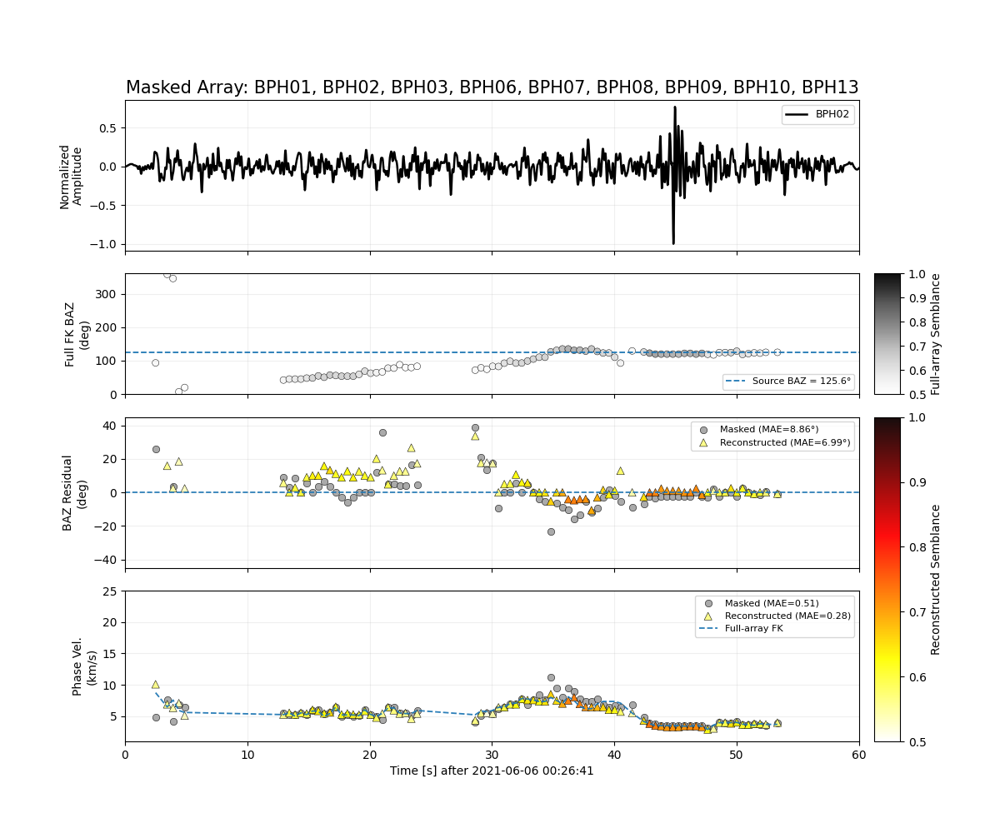

In [50]:
%%time
fig, axes, fk_info = plot_fk_full_vs_masked_vs_reconstructed_residuals(
    st_full=st_full_z,
    st_masked=st_masked_z,
    st_rec=st_rec_z,
    element="BPH02",
    T_full=T_full, B_full=B_full, V_full=V_full, S_full=S_full,
    T_masked=T_masked, B_masked=B_masked, V_masked=V_masked, S_masked=S_masked,
    T_rec=T_rec, B_rec=B_rec, V_rec=V_rec, S_rec=S_rec,
    baz_truth_deg=meta_test.iloc[result["event_idx"]]["azimuth_deg"] % 360.0,
    semblance_threshold=0.5,
    residual_mae_clip_deg=180.0,
    baz_ylim=(-45, 45),
    vel_ylim=(1,25),
    xlim=(0, 60),
    fname="Figures/VASA_v1/Physical_Validation/Example_"+str(result["event_idx"])+"_Temporal_Offset.png",
)

---
Comprehensive FK analysis

In [58]:
%%time
# Comprehensive FK analysis for VASA v1 single-sensor specialist
# Full array FK is the baseline. Each event has 10 evaluations:
# one reconstructed target sensor + the other 9 sensors as context.

def circular_residual_deg(angle_deg, ref_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    ref_deg = np.asarray(ref_deg, dtype=float)
    return ((angle_deg - ref_deg + 180.0) % 360.0) - 180.0


def _interp_linear(x_ref, y_ref, x_new):
    x_ref = np.asarray(x_ref, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)
    x_new = np.asarray(x_new, dtype=float)

    keep = np.isfinite(x_ref) & np.isfinite(y_ref)
    if np.sum(keep) < 2:
        return np.full_like(x_new, np.nan, dtype=float)

    return np.interp(x_new, x_ref[keep], y_ref[keep], left=np.nan, right=np.nan)


def _interp_circular_deg(x_ref, angle_ref_deg, x_new):
    x_ref = np.asarray(x_ref, dtype=float)
    angle_ref_deg = np.asarray(angle_ref_deg, dtype=float)
    x_new = np.asarray(x_new, dtype=float)

    keep = np.isfinite(x_ref) & np.isfinite(angle_ref_deg)
    if np.sum(keep) < 2:
        return np.full_like(x_new, np.nan, dtype=float)

    ang_rad = np.deg2rad(angle_ref_deg[keep] % 360.0)
    cos_new = np.interp(x_new, x_ref[keep], np.cos(ang_rad), left=np.nan, right=np.nan)
    sin_new = np.interp(x_new, x_ref[keep], np.sin(ang_rad), left=np.nan, right=np.nan)

    out = (np.rad2deg(np.arctan2(sin_new, cos_new)) + 360.0) % 360.0
    out[~np.isfinite(cos_new) | ~np.isfinite(sin_new)] = np.nan
    return out


def _component_to_index(component):
    mapping = {"Z": 0, "N": 1, "E": 2, "BHZ": 0, "BHN": 1, "BHE": 2}
    component = component.upper()
    if component not in mapping:
        raise ValueError("component must be one of Z, N, E, BHZ, BHN, BHE")
    return mapping[component]


def _run_fk_raw(
    data_all,
    x_km,
    y_km,
    sampling_rate,
    freq_min=0.5,
    freq_max=5.0,
    smax=1.0,
    ngrid=150,
    window_length=5.0,
    overlap_percent=50.0,
):
    data_all = np.asarray(data_all, dtype=float)
    x_km = np.asarray(x_km, dtype=float)
    y_km = np.asarray(y_km, dtype=float)

    T_fk, B_fk, V_fk, S_fk = VASA.cardinal_fk.sliding_window_fk(
        data_all,
        x_km,
        y_km,
        sampling_rate,
        fmin=freq_min,
        fmax=freq_max,
        window_length=window_length,
        overlap_percent=overlap_percent,
        smax=smax,
        ngrid=ngrid,
        detrend_data=False,
        apply_taper=False,
    )

    return {
        "T": np.asarray(T_fk, dtype=float),
        "B": np.asarray(B_fk, dtype=float) % 360.0,
        "V": np.asarray(V_fk, dtype=float),
        "S": np.asarray(S_fk, dtype=float),
    }


def _align_or_interp_to_full_time(T_src, values, T_full):
    T_src = np.asarray(T_src, dtype=float)
    values = np.asarray(values, dtype=float)
    T_full = np.asarray(T_full, dtype=float)

    if len(T_src) == len(T_full) and np.allclose(T_src, T_full, atol=1e-8, equal_nan=True):
        return values.astype(np.float32)

    return _interp_linear(T_src, values, T_full).astype(np.float32)


def build_vasa_v1_single_sensor_combo_table(station_order):
    rows = []
    sensor_dim = len(station_order)

    for target_idx, target_station in enumerate(station_order):
        observed_indices = tuple(i for i in range(sensor_dim) if i != target_idx)
        masked_indices = (target_idx,)

        rows.append({
            "combo_id": target_idx,
            "num_masked": 1,
            "target_sensor_index": target_idx,
            "target_station": target_station,
            "masked_indices": masked_indices,
            "observed_indices": observed_indices,
            "masked_station_str": target_station,
            "observed_station_str": "|".join(station_order[i] for i in observed_indices),
            "mask_bitstring": "".join("1" if i == target_idx else "0" for i in range(sensor_dim)),
        })

    return pd.DataFrame(rows)


def make_fk_xy_from_station_coords(station_coords_used, station_order):
    """
    Build x/y geometry in km from station_coords_used if x_km_full/y_km_full
    are not already available from VASA.plot_array_geometry().
    """
    site_df = station_coords_used.copy()
    if "station" in site_df.columns:
        site_df = site_df.set_index("station")
    site_df = site_df.loc[station_order]

    lat0 = float(site_df.iloc[0]["latitude"])
    lon0 = float(site_df.iloc[0]["longitude"])

    x_km = []
    y_km = []

    for _, row in site_df.iterrows():
        dist_m, az_deg, _ = gps2dist_azimuth(lat0, lon0, float(row["latitude"]), float(row["longitude"]))
        dist_km = dist_m / 1000.0
        az_rad = np.deg2rad(az_deg)
        x_km.append(dist_km * np.sin(az_rad))
        y_km.append(dist_km * np.cos(az_rad))

    return np.asarray(x_km, dtype=float), np.asarray(y_km, dtype=float)


if "x_km_full" not in globals() or "y_km_full" not in globals():
    x_km_full, y_km_full = make_fk_xy_from_station_coords(station_coords_used, station_order)

vasa_v1_sensor_combo_df = build_vasa_v1_single_sensor_combo_table(station_order)

display(vasa_v1_sensor_combo_df)
print("x_km_full:", x_km_full)
print("y_km_full:", y_km_full)

,combo_id,num_masked,target_sensor_index,target_station,masked_indices,observed_indices,masked_station_str,observed_station_str,mask_bitstring
0,0,1,0,BPH01,"(0,)","(1, 2, 3, 4, 5, 6, 7, 8, 9)",BPH01,BPH02|BPH03|BPH06|BPH07|BPH08|BPH09|BPH10|BPH1...,1000000000
1,1,1,1,BPH02,"(1,)","(0, 2, 3, 4, 5, 6, 7, 8, 9)",BPH02,BPH01|BPH03|BPH06|BPH07|BPH08|BPH09|BPH10|BPH1...,0100000000
2,2,1,2,BPH03,"(2,)","(0, 1, 3, 4, 5, 6, 7, 8, 9)",BPH03,BPH01|BPH02|BPH06|BPH07|BPH08|BPH09|BPH10|BPH1...,0010000000
3,3,1,3,BPH06,"(3,)","(0, 1, 2, 4, 5, 6, 7, 8, 9)",BPH06,BPH01|BPH02|BPH03|BPH07|BPH08|BPH09|BPH10|BPH1...,0001000000
4,4,1,4,BPH07,"(4,)","(0, 1, 2, 3, 5, 6, 7, 8, 9)",BPH07,BPH01|BPH02|BPH03|BPH06|BPH08|BPH09|BPH10|BPH1...,0000100000
5,5,1,5,BPH08,"(5,)","(0, 1, 2, 3, 4, 6, 7, 8, 9)",BPH08,BPH01|BPH02|BPH03|BPH06|BPH07|BPH09|BPH10|BPH1...,0000010000
6,6,1,6,BPH09,"(6,)","(0, 1, 2, 3, 4, 5, 7, 8, 9)",BPH09,BPH01|BPH02|BPH03|BPH06|BPH07|BPH08|BPH10|BPH1...,0000001000
7,7,1,7,BPH10,"(7,)","(0, 1, 2, 3, 4, 5, 6, 8, 9)",BPH10,BPH01|BPH02|BPH03|BPH06|BPH07|BPH08|BPH09|BPH1...,0000000100
8,8,1,8,BPH11,"(8,)","(0, 1, 2, 3, 4, 5, 6, 7, 9)",BPH11,BPH01|BPH02|BPH03|BPH06|BPH07|BPH08|BPH09|BPH1...,0000000010
9,9,1,9,BPH13,"(9,)","(0, 1, 2, 3, 4, 5, 6, 7, 8)",BPH13,BPH01|BPH02|BPH03|BPH06|BPH07|BPH08|BPH09|BPH1...,0000000001


x_km_full: [ 0.00478772  0.0509054   0.00460251  0.28241988  0.02321627 -0.21774399
 -0.40286296  0.32872277  0.33798335 -0.41203094]
y_km_full: [ 0.10231045  0.05783248  0.01335451  0.04671299 -0.22004364  0.05783248
  0.27999994  0.26910284 -0.50926164 -0.09784042]
CPU times: user 18 ms, sys: 0 ns, total: 18 ms
Wall time: 18.5 ms


In [59]:
%%time
def _compute_full_fk_for_event(
    X_data,
    event_index,
    component,
    x_km_full,
    y_km_full,
    sampling_rate,
    fk_kwargs,
):
    comp_idx = _component_to_index(component)
    true_comp = X_data[event_index].astype(np.float32)[:, :, comp_idx]
    return _run_fk_raw(true_comp, x_km_full, y_km_full, sampling_rate=sampling_rate, **fk_kwargs)


def precompute_full_fk_cache_v1(
    X_data,
    x_km_full,
    y_km_full,
    component="Z",
    event_indices=None,
    save_dir="FK_Eval/Earthquakes/fk_vasa_v1/full_fk_cache",
    sampling_rate=40.0,
    fk_freq_min=0.5,
    fk_freq_max=5.0,
    fk_smax=1.0,
    fk_ngrid=150,
    fk_window_length=5.0,
    fk_overlap_percent=50.0,
    resume=True,
    print_progress=True,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if event_indices is None:
        event_indices = np.arange(X_data.shape[0], dtype=int)
    else:
        event_indices = np.asarray(event_indices, dtype=int)

    fk_kwargs = dict(
        freq_min=fk_freq_min,
        freq_max=fk_freq_max,
        smax=fk_smax,
        ngrid=fk_ngrid,
        window_length=fk_window_length,
        overlap_percent=fk_overlap_percent,
    )

    for ii, event_index in enumerate(event_indices, start=1):
        cache_path = save_dir / f"event_{event_index:05d}_full_fk.npz"

        if resume and cache_path.exists():
            if print_progress:
                print(f"Skipping full FK for event {event_index} ({ii}/{len(event_indices)}): cached")
            continue

        if print_progress:
            print(f"Computing full FK for event {event_index} ({ii}/{len(event_indices)})")

        full_fk = _compute_full_fk_for_event(
            X_data=X_data,
            event_index=event_index,
            component=component,
            x_km_full=x_km_full,
            y_km_full=y_km_full,
            sampling_rate=sampling_rate,
            fk_kwargs=fk_kwargs,
        )

        np.savez_compressed(
            cache_path,
            event_idx=np.int32(event_index),
            T=np.asarray(full_fk["T"], dtype=np.float32),
            B=np.asarray(full_fk["B"], dtype=np.float32),
            V=np.asarray(full_fk["V"], dtype=np.float32),
            S=np.asarray(full_fk["S"], dtype=np.float32),
        )

    return {
        "full_fk_cache_dir": save_dir,
        "n_cached": len(list(save_dir.glob("event_*_full_fk.npz"))),
    }


def _load_full_fk_cache_v1(full_fk_cache_dir, event_index):
    cache_path = Path(full_fk_cache_dir) / f"event_{event_index:05d}_full_fk.npz"
    if not cache_path.exists():
        return None

    with np.load(cache_path) as z:
        return {
            "T": z["T"].astype(float),
            "B": z["B"].astype(float),
            "V": z["V"].astype(float),
            "S": z["S"].astype(float),
        }


def _compute_single_sensor_fk_metrics(
    combo_row,
    true_comp,
    pred_comp,
    x_km_full,
    y_km_full,
    sampling_rate,
    fk_kwargs,
    full_fk,
    xlim=(0, 60),
    semblance_threshold=0.5,
    residual_mae_clip_deg=180.0,
):
    combo_id = int(combo_row["combo_id"])
    target_idx = int(combo_row["target_sensor_index"])
    target_station = combo_row["target_station"]
    observed_indices = tuple(combo_row["observed_indices"])

    reduced_comp = true_comp[np.asarray(observed_indices), :]
    x_km_reduced = np.asarray(x_km_full)[np.asarray(observed_indices)]
    y_km_reduced = np.asarray(y_km_full)[np.asarray(observed_indices)]

    reconstructed_comp = true_comp.copy()
    reconstructed_comp[target_idx, :] = pred_comp[target_idx, :]

    reduced_fk = _run_fk_raw(
        reduced_comp,
        x_km_reduced,
        y_km_reduced,
        sampling_rate=sampling_rate,
        **fk_kwargs,
    )

    rec_fk = _run_fk_raw(
        reconstructed_comp,
        x_km_full,
        y_km_full,
        sampling_rate=sampling_rate,
        **fk_kwargs,
    )

    T_full = full_fk["T"]

    B_full_on_reduced = _interp_circular_deg(full_fk["T"], full_fk["B"], reduced_fk["T"])
    B_full_on_rec = _interp_circular_deg(full_fk["T"], full_fk["B"], rec_fk["T"])

    V_full_on_reduced = _interp_linear(full_fk["T"], full_fk["V"], reduced_fk["T"])
    V_full_on_rec = _interp_linear(full_fk["T"], full_fk["V"], rec_fk["T"])

    reduced_baz_abs = np.abs(circular_residual_deg(reduced_fk["B"], B_full_on_reduced))
    rec_baz_abs = np.abs(circular_residual_deg(rec_fk["B"], B_full_on_rec))

    reduced_pv_abs = np.abs(reduced_fk["V"] - V_full_on_reduced)
    rec_pv_abs = np.abs(rec_fk["V"] - V_full_on_rec)

    reduced_baz_on_full = _align_or_interp_to_full_time(reduced_fk["T"], reduced_baz_abs, T_full)
    rec_baz_on_full = _align_or_interp_to_full_time(rec_fk["T"], rec_baz_abs, T_full)

    reduced_pv_on_full = _align_or_interp_to_full_time(reduced_fk["T"], reduced_pv_abs, T_full)
    rec_pv_on_full = _align_or_interp_to_full_time(rec_fk["T"], rec_pv_abs, T_full)

    S_rec_on_full = _align_or_interp_to_full_time(rec_fk["T"], rec_fk["S"], T_full)

    if xlim is not None:
        t0, t1 = xlim
        time_keep = (T_full >= t0) & (T_full <= t1)
    else:
        time_keep = np.ones_like(T_full, dtype=bool)

    if semblance_threshold is not None:
        valid_baz = (
            time_keep
            & np.isfinite(rec_baz_on_full)
            & np.isfinite(reduced_baz_on_full)
            & np.isfinite(S_rec_on_full)
            & (S_rec_on_full > semblance_threshold)
            & (rec_baz_on_full <= residual_mae_clip_deg)
            & (reduced_baz_on_full <= residual_mae_clip_deg)
        )
        valid_pv = (
            time_keep
            & np.isfinite(rec_pv_on_full)
            & np.isfinite(reduced_pv_on_full)
            & np.isfinite(S_rec_on_full)
            & (S_rec_on_full > semblance_threshold)
        )
    else:
        valid_baz = (
            time_keep
            & np.isfinite(rec_baz_on_full)
            & np.isfinite(reduced_baz_on_full)
            & (rec_baz_on_full <= residual_mae_clip_deg)
            & (reduced_baz_on_full <= residual_mae_clip_deg)
        )
        valid_pv = time_keep & np.isfinite(rec_pv_on_full) & np.isfinite(reduced_pv_on_full)

    reduced_baz_valid = reduced_baz_on_full.astype(np.float32)
    rec_baz_valid = rec_baz_on_full.astype(np.float32)
    reduced_pv_valid = reduced_pv_on_full.astype(np.float32)
    rec_pv_valid = rec_pv_on_full.astype(np.float32)

    reduced_baz_valid[~valid_baz] = np.nan
    rec_baz_valid[~valid_baz] = np.nan
    reduced_pv_valid[~valid_pv] = np.nan
    rec_pv_valid[~valid_pv] = np.nan

    reduced_baz_mae = float(np.nanmean(reduced_baz_valid)) if np.any(np.isfinite(reduced_baz_valid)) else np.nan
    rec_baz_mae = float(np.nanmean(rec_baz_valid)) if np.any(np.isfinite(rec_baz_valid)) else np.nan
    reduced_pv_mae = float(np.nanmean(reduced_pv_valid)) if np.any(np.isfinite(reduced_pv_valid)) else np.nan
    rec_pv_mae = float(np.nanmean(rec_pv_valid)) if np.any(np.isfinite(rec_pv_valid)) else np.nan

    return {
        "summary": {
            "combo_id": combo_id,
            "num_masked": 1,
            "target_sensor_index": target_idx,
            "target_station": target_station,
            "reduced_baz_mae": reduced_baz_mae,
            "reconstructed_baz_mae": rec_baz_mae,
            "baz_improvement_mae": reduced_baz_mae - rec_baz_mae if np.isfinite(reduced_baz_mae) and np.isfinite(rec_baz_mae) else np.nan,
            "baz_delta_mae": rec_baz_mae - reduced_baz_mae if np.isfinite(reduced_baz_mae) and np.isfinite(rec_baz_mae) else np.nan,
            "reduced_pv_mae": reduced_pv_mae,
            "reconstructed_pv_mae": rec_pv_mae,
            "pv_improvement_mae": reduced_pv_mae - rec_pv_mae if np.isfinite(reduced_pv_mae) and np.isfinite(rec_pv_mae) else np.nan,
            "pv_delta_mae": rec_pv_mae - reduced_pv_mae if np.isfinite(reduced_pv_mae) and np.isfinite(rec_pv_mae) else np.nan,
            "n_common_baz_windows": int(np.sum(np.isfinite(rec_baz_valid))),
            "n_common_pv_windows": int(np.sum(np.isfinite(rec_pv_valid))),
        },
        "window": {
            "combo_id": combo_id,
            "target_sensor_index": target_idx,
            "target_station": target_station,
            "reduced_baz_abs": reduced_baz_valid,
            "reconstructed_baz_abs": rec_baz_valid,
            "baz_improvement": reduced_baz_valid - rec_baz_valid,
            "reduced_pv_abs": reduced_pv_valid,
            "reconstructed_pv_abs": rec_pv_valid,
            "pv_improvement": reduced_pv_valid - rec_pv_valid,
        },
    }

CPU times: user 9 μs, sys: 1 μs, total: 10 μs
Wall time: 20.3 μs


In [60]:
%%time
def evaluate_fk_vasa_v1_for_event(
    model,
    X_data,
    D_norm,
    global_center,
    global_scale,
    station_order,
    x_km_full,
    y_km_full,
    event_index,
    meta_df=None,
    component="Z",
    output_gain=1.0,
    final_clip=100.0,
    sampling_rate=40.0,
    n_fk_workers=5,
    xlim=(0, 60),
    semblance_threshold=0.5,
    residual_mae_clip_deg=180.0,
    fk_freq_min=0.5,
    fk_freq_max=5.0,
    fk_smax=1.0,
    fk_ngrid=150,
    fk_window_length=5.0,
    fk_overlap_percent=50.0,
    full_fk=None,
):
    comp_idx = _component_to_index(component)
    sensor_dim = X_data.shape[1]

    combo_df = build_vasa_v1_single_sensor_combo_table(station_order)
    x_clean = X_data[event_index].astype(np.float32)
    true_comp = x_clean[:, :, comp_idx]

    fk_kwargs = dict(
        freq_min=fk_freq_min,
        freq_max=fk_freq_max,
        smax=fk_smax,
        ngrid=fk_ngrid,
        window_length=fk_window_length,
        overlap_percent=fk_overlap_percent,
    )

    if full_fk is None:
        full_fk = _run_fk_raw(
            true_comp,
            x_km_full,
            y_km_full,
            sampling_rate=sampling_rate,
            **fk_kwargs,
        )

    x_scaled = VASA.global_asinh_scale(
        tf.constant(x_clean, dtype=tf.float32),
        global_center=tf.constant(global_center, dtype=tf.float32),
        global_scale=tf.constant(global_scale, dtype=tf.float32),
        output_gain=output_gain,
        final_clip=final_clip,
    ).numpy().astype(np.float32)

    observed_mask_batch = np.ones((sensor_dim, sensor_dim, x_scaled.shape[1], x_scaled.shape[2]), dtype=np.float32)
    for target_idx in range(sensor_dim):
        observed_mask_batch[target_idx, target_idx, :, :] = 0.0

    x_observed_batch = x_scaled[None, ...] * observed_mask_batch
    x_model_batch = np.concatenate([x_observed_batch, observed_mask_batch], axis=-1).astype(np.float32)
    d_model_batch = np.repeat(np.asarray(D_norm, dtype=np.float32)[None, :, :], sensor_dim, axis=0)

    preds = model.predict(
        {"seismic_input": x_model_batch, "distance_input": d_model_batch},
        batch_size=sensor_dim,
        verbose=0,
    )

    y_pred_scaled_batch = VASA.get_3branch_predictions(preds)
    pred_event_batch = VASA.inverse_global_asinh_scale(
        y_pred_scaled_batch,
        global_center,
        global_scale,
        output_gain=output_gain,
    ).astype(np.float32)

    n_combo = len(combo_df)
    n_full_windows = len(full_fk["T"])

    reduced_baz_abs_all = np.full((n_combo, n_full_windows), np.nan, dtype=np.float32)
    rec_baz_abs_all = np.full((n_combo, n_full_windows), np.nan, dtype=np.float32)
    baz_improvement_all = np.full((n_combo, n_full_windows), np.nan, dtype=np.float32)

    reduced_pv_abs_all = np.full((n_combo, n_full_windows), np.nan, dtype=np.float32)
    rec_pv_abs_all = np.full((n_combo, n_full_windows), np.nan, dtype=np.float32)
    pv_improvement_all = np.full((n_combo, n_full_windows), np.nan, dtype=np.float32)

    summary_rows = []

    with ThreadPoolExecutor(max_workers=n_fk_workers) as ex:
        futures = {}

        for row in combo_df.itertuples(index=False):
            target_idx = int(row.target_sensor_index)
            pred_comp = pred_event_batch[target_idx, :, :, comp_idx]

            combo_row = {
                "combo_id": row.combo_id,
                "target_sensor_index": row.target_sensor_index,
                "target_station": row.target_station,
                "observed_indices": row.observed_indices,
            }

            fut = ex.submit(
                _compute_single_sensor_fk_metrics,
                combo_row=combo_row,
                true_comp=true_comp,
                pred_comp=pred_comp,
                x_km_full=x_km_full,
                y_km_full=y_km_full,
                sampling_rate=sampling_rate,
                fk_kwargs=fk_kwargs,
                full_fk=full_fk,
                xlim=xlim,
                semblance_threshold=semblance_threshold,
                residual_mae_clip_deg=residual_mae_clip_deg,
            )
            futures[fut] = target_idx

        for fut in as_completed(futures):
            out = fut.result()
            combo_id = int(out["summary"]["combo_id"])
            summary_rows.append(out["summary"])

            reduced_baz_abs_all[combo_id, :] = out["window"]["reduced_baz_abs"]
            rec_baz_abs_all[combo_id, :] = out["window"]["reconstructed_baz_abs"]
            baz_improvement_all[combo_id, :] = out["window"]["baz_improvement"]

            reduced_pv_abs_all[combo_id, :] = out["window"]["reduced_pv_abs"]
            rec_pv_abs_all[combo_id, :] = out["window"]["reconstructed_pv_abs"]
            pv_improvement_all[combo_id, :] = out["window"]["pv_improvement"]

    event_summary_df = pd.DataFrame(summary_rows).sort_values("combo_id").reset_index(drop=True)

    if meta_df is not None:
        meta_row = meta_df.iloc[event_index]
        event_summary_df.insert(0, "event_idx", event_index)
        event_summary_df.insert(1, "EVID", meta_row.get("EVID", np.nan))
        event_summary_df.insert(2, "azimuth_deg", meta_row.get("azimuth_deg", np.nan))
        event_summary_df.insert(3, "distance_km", meta_row.get("distance_km", np.nan))
        event_summary_df.insert(4, "MAG", meta_row.get("MAG", np.nan))
    else:
        event_summary_df.insert(0, "event_idx", event_index)

    window_payload = {
        "event_idx": event_index,
        "fk_time": np.asarray(full_fk["T"], dtype=np.float32),
        "combo_id": combo_df["combo_id"].to_numpy(dtype=np.int32),
        "target_sensor_index": combo_df["target_sensor_index"].to_numpy(dtype=np.int32),
        "target_station": combo_df["target_station"].to_numpy(dtype=str),
        "reduced_baz_abs": reduced_baz_abs_all,
        "reconstructed_baz_abs": rec_baz_abs_all,
        "baz_improvement": baz_improvement_all,
        "reduced_pv_abs": reduced_pv_abs_all,
        "reconstructed_pv_abs": rec_pv_abs_all,
        "pv_improvement": pv_improvement_all,
        "full_baz": np.asarray(full_fk["B"], dtype=np.float32),
        "full_pv": np.asarray(full_fk["V"], dtype=np.float32),
        "full_semblance": np.asarray(full_fk["S"], dtype=np.float32),
    }

    return event_summary_df, window_payload


def evaluate_fk_vasa_v1_resume(
    model,
    X_data,
    D_norm,
    global_center,
    global_scale,
    station_order,
    x_km_full,
    y_km_full,
    meta_df=None,
    component="Z",
    event_indices=None,
    save_dir="FK_Eval/Earthquakes/fk_vasa_v1_0000_0999",
    full_fk_cache_dir="FK_Eval/Earthquakes/fk_vasa_v1/full_fk_cache",
    precompute_missing_full_fk=True,
    output_gain=1.0,
    final_clip=100.0,
    sampling_rate=40.0,
    n_fk_workers=5,
    xlim=(0, 60),
    semblance_threshold=0.5,
    residual_mae_clip_deg=180.0,
    fk_freq_min=0.5,
    fk_freq_max=5.0,
    fk_smax=1.0,
    fk_ngrid=150,
    fk_window_length=5.0,
    fk_overlap_percent=50.0,
    resume=True,
    write_combined_summary=True,
    print_progress=True,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    summary_dir = save_dir / "event_summary_csv"
    windows_dir = save_dir / "event_window_npz"
    summary_dir.mkdir(exist_ok=True)
    windows_dir.mkdir(exist_ok=True)

    full_fk_cache_dir = Path(full_fk_cache_dir)
    full_fk_cache_dir.mkdir(parents=True, exist_ok=True)

    combo_df = build_vasa_v1_single_sensor_combo_table(station_order)
    combo_df_to_save = combo_df.copy()
    combo_df_to_save["masked_indices"] = combo_df_to_save["masked_indices"].apply(lambda x: json.dumps(list(x)))
    combo_df_to_save["observed_indices"] = combo_df_to_save["observed_indices"].apply(lambda x: json.dumps(list(x)))
    combo_df_to_save.to_csv(save_dir / "single_sensor_combo_table.csv", index=False)

    if event_indices is None:
        event_indices = np.arange(X_data.shape[0], dtype=int)
    else:
        event_indices = np.asarray(event_indices, dtype=int)

    fk_kwargs = dict(
        freq_min=fk_freq_min,
        freq_max=fk_freq_max,
        smax=fk_smax,
        ngrid=fk_ngrid,
        window_length=fk_window_length,
        overlap_percent=fk_overlap_percent,
    )

    for ii, event_index in enumerate(event_indices, start=1):
        t0 = time.time()

        summary_path = summary_dir / f"event_{event_index:05d}_summary.csv"
        window_path = windows_dir / f"event_{event_index:05d}_windows.npz"

        if resume and summary_path.exists() and window_path.exists():
            if print_progress:
                print(f"Skipping event {event_index} ({ii}/{len(event_indices)}): already done")
            continue

        full_fk = _load_full_fk_cache_v1(full_fk_cache_dir, event_index)

        if full_fk is None and precompute_missing_full_fk:
            if print_progress:
                print(f"Full FK cache missing for event {event_index}; computing")

            full_fk = _compute_full_fk_for_event(
                X_data=X_data,
                event_index=event_index,
                component=component,
                x_km_full=x_km_full,
                y_km_full=y_km_full,
                sampling_rate=sampling_rate,
                fk_kwargs=fk_kwargs,
            )

            np.savez_compressed(
                full_fk_cache_dir / f"event_{event_index:05d}_full_fk.npz",
                event_idx=np.int32(event_index),
                T=np.asarray(full_fk["T"], dtype=np.float32),
                B=np.asarray(full_fk["B"], dtype=np.float32),
                V=np.asarray(full_fk["V"], dtype=np.float32),
                S=np.asarray(full_fk["S"], dtype=np.float32),
            )

        if print_progress:
            print(f"Running event {event_index} ({ii}/{len(event_indices)})")

        event_summary_df, window_payload = evaluate_fk_vasa_v1_for_event(
            model=model,
            X_data=X_data,
            D_norm=D_norm,
            global_center=global_center,
            global_scale=global_scale,
            station_order=station_order,
            x_km_full=x_km_full,
            y_km_full=y_km_full,
            event_index=event_index,
            meta_df=meta_df,
            component=component,
            output_gain=output_gain,
            final_clip=final_clip,
            sampling_rate=sampling_rate,
            n_fk_workers=n_fk_workers,
            xlim=xlim,
            semblance_threshold=semblance_threshold,
            residual_mae_clip_deg=residual_mae_clip_deg,
            fk_freq_min=fk_freq_min,
            fk_freq_max=fk_freq_max,
            fk_smax=fk_smax,
            fk_ngrid=fk_ngrid,
            fk_window_length=fk_window_length,
            fk_overlap_percent=fk_overlap_percent,
            full_fk=full_fk,
        )

        event_summary_df.to_csv(summary_path, index=False)

        np.savez_compressed(
            window_path,
            event_idx=np.int32(window_payload["event_idx"]),
            fk_time=window_payload["fk_time"],
            combo_id=window_payload["combo_id"],
            target_sensor_index=window_payload["target_sensor_index"],
            target_station=window_payload["target_station"],
            reduced_baz_abs=window_payload["reduced_baz_abs"],
            reconstructed_baz_abs=window_payload["reconstructed_baz_abs"],
            baz_improvement=window_payload["baz_improvement"],
            reduced_pv_abs=window_payload["reduced_pv_abs"],
            reconstructed_pv_abs=window_payload["reconstructed_pv_abs"],
            pv_improvement=window_payload["pv_improvement"],
            full_baz=window_payload["full_baz"],
            full_pv=window_payload["full_pv"],
            full_semblance=window_payload["full_semblance"],
        )

        if print_progress:
            print(f"Saved event {event_index} in {(time.time() - t0) / 60:.2f} min")

    combined_summary_df = None
    if write_combined_summary:
        summary_files = sorted(summary_dir.glob("event_*_summary.csv"))
        if len(summary_files) > 0:
            combined_summary_df = pd.concat([pd.read_csv(f) for f in summary_files], ignore_index=True)
            combined_summary_df.to_csv(save_dir / "fk_vasa_v1_summary_all_events.csv", index=False)

    return {
        "save_dir": save_dir,
        "combo_df": combo_df,
        "combined_summary_df": combined_summary_df,
        "summary_dir": summary_dir,
        "windows_dir": windows_dir,
        "full_fk_cache_dir": full_fk_cache_dir,
    }

CPU times: user 9 μs, sys: 1e+03 ns, total: 10 μs
Wall time: 20.5 μs


In [61]:
%%time
# Run comprehensive test (10 combinations per event for reduced and reconstructed array)
fk_vasa_v1_results = evaluate_fk_vasa_v1_resume(
    model=vasa_v1,
    X_data=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    station_order=station_order,
    x_km_full=x_km_full,
    y_km_full=y_km_full,
    meta_df=meta_test,
    component="Z",
    event_indices=None,
    save_dir="FK_Eval/Earthquakes/fk_vasa_v1",
    full_fk_cache_dir="FK_Eval/Earthquakes/fk_vasa_v1/full_fk_cache",
    precompute_missing_full_fk=True,
    final_clip=100.0,
    sampling_rate=40.0,
    n_fk_workers=5,
    xlim=(0, 60),
    semblance_threshold=0.5,
    residual_mae_clip_deg=180.0,
    fk_freq_min=0.5,
    fk_freq_max=5.0,
    fk_smax=1.0,
    fk_ngrid=150,
    fk_window_length=5.0,
    fk_overlap_percent=50.0,
    resume=True,
    write_combined_summary=True,
    print_progress=True,
)

fk_summary_df = fk_vasa_v1_results["combined_summary_df"]
display(fk_summary_df.head())

Full FK cache missing for event 0; computing
Running event 0 (1/6000)
Saved event 0 in 0.30 min
Full FK cache missing for event 1; computing
Running event 1 (2/6000)
Saved event 1 in 0.26 min
Full FK cache missing for event 2; computing
Running event 2 (3/6000)
Saved event 2 in 0.24 min
Full FK cache missing for event 3; computing
Running event 3 (4/6000)
Saved event 3 in 0.25 min
Full FK cache missing for event 4; computing
Running event 4 (5/6000)
Saved event 4 in 0.25 min
Full FK cache missing for event 5; computing
Running event 5 (6/6000)
Saved event 5 in 0.26 min
Full FK cache missing for event 6; computing
Running event 6 (7/6000)
Saved event 6 in 0.25 min
Full FK cache missing for event 7; computing
Running event 7 (8/6000)
Saved event 7 in 0.25 min
Full FK cache missing for event 8; computing
Running event 8 (9/6000)
Saved event 8 in 0.25 min
Full FK cache missing for event 9; computing
Running event 9 (10/6000)
Saved event 9 in 0.26 min
Full FK cache missing for event 10; com

,event_idx,EVID,azimuth_deg,distance_km,MAG,combo_id,num_masked,target_sensor_index,target_station,reduced_baz_mae,reconstructed_baz_mae,baz_improvement_mae,baz_delta_mae,reduced_pv_mae,reconstructed_pv_mae,pv_improvement_mae,pv_delta_mae,n_common_baz_windows,n_common_pv_windows
0,0,37393936,-41.318771,64.392013,1.39,0,1,0,BPH01,16.129839,0.625534,15.504305,-15.504305,3.004691,0.171198,2.833493,-2.833493,22,22
1,0,37393936,-41.318771,64.392013,1.39,1,1,1,BPH02,11.035359,0.276641,10.758718,-10.758718,3.278347,0.128281,3.150067,-3.150067,20,20
2,0,37393936,-41.318771,64.392013,1.39,2,1,2,BPH03,9.561916,0.297058,9.264858,-9.264858,3.026824,0.024540,3.002284,-3.002284,20,20
3,0,37393936,-41.318771,64.392013,1.39,3,1,3,BPH06,17.668339,10.166383,7.501956,-7.501956,5.579756,4.299816,1.279940,-1.279940,20,20
4,0,37393936,-41.318771,64.392013,1.39,4,1,4,BPH07,19.554100,26.277195,-6.723095,6.723095,4.375614,4.968261,-0.592647,0.592647,21,21


CPU times: user 1d 12h 39min 46s, sys: 3h 40min 4s, total: 1d 16h 19min 51s
Wall time: 15h 58min 24s


In [8]:
%%time
# Load runs
def load_all_fk_vasa_v1_runs(
    base_dir="FK_Eval/Earthquakes",
    run_prefix="fk_vasa_v1",
):
    base_dir = Path(base_dir)

    run_dirs = sorted([
        p for p in base_dir.iterdir()
        if p.is_dir() and p.name.startswith(run_prefix)
    ])

    if len(run_dirs) == 0:
        raise FileNotFoundError(f"No run dirs found in {base_dir} with prefix {run_prefix!r}")

    summary_parts = []
    window_rows = []
    combo_df = None

    for run_dir in run_dirs:
        combo_path = run_dir / "single_sensor_combo_table.csv"
        if combo_path.exists() and combo_df is None:
            combo_df = pd.read_csv(combo_path)

        summary_dir = run_dir / "event_summary_csv"
        windows_dir = run_dir / "event_window_npz"

        for f in sorted(summary_dir.glob("event_*_summary.csv")):
            tmp = pd.read_csv(f)
            tmp["run_dir"] = str(run_dir)
            summary_parts.append(tmp)

        for f in sorted(windows_dir.glob("event_*_windows.npz")):
            with np.load(f) as z:
                event_idx = int(z["event_idx"])
                fk_time = z["fk_time"].astype(float)
                target_station = z["target_station"].astype(str)

            window_rows.append({
                "run_dir": str(run_dir),
                "event_idx": event_idx,
                "window_file": str(f),
                "n_fk_windows": len(fk_time),
                "target_station_str": "|".join(target_station),
            })

    fk_summary_df = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()
    window_index_df = pd.DataFrame(window_rows)

    return {
        "run_dirs": run_dirs,
        "combo_df": combo_df,
        "summary_df": fk_summary_df,
        "window_index_df": window_index_df,
    }


fk_vasa_v1_all = load_all_fk_vasa_v1_runs(
    base_dir="FK_Eval/Earthquakes",
    run_prefix="fk_vasa_v1",
)

v1_combo_df = fk_vasa_v1_all["combo_df"]
fk_summary_df = fk_vasa_v1_all["summary_df"]
window_index_df = fk_vasa_v1_all["window_index_df"]

print("Run folders loaded:", len(fk_vasa_v1_all["run_dirs"]))
print("Summary shape:", fk_summary_df.shape)
print("Window index shape:", window_index_df.shape)

display(fk_summary_df.head())
display(window_index_df.head())

Run folders loaded: 1
Summary shape: (60000, 20)
Window index shape: (6000, 5)


,event_idx,EVID,azimuth_deg,distance_km,MAG,combo_id,num_masked,target_sensor_index,target_station,reduced_baz_mae,reconstructed_baz_mae,baz_improvement_mae,baz_delta_mae,reduced_pv_mae,reconstructed_pv_mae,pv_improvement_mae,pv_delta_mae,n_common_baz_windows,n_common_pv_windows,run_dir
0,0,37393936,-41.318771,64.392013,1.39,0,1,0,BPH01,16.129839,0.625534,15.504305,-15.504305,3.004691,0.171198,2.833493,-2.833493,22,22,FK_Eval/Earthquakes/fk_vasa_v1
1,0,37393936,-41.318771,64.392013,1.39,1,1,1,BPH02,11.035359,0.276641,10.758718,-10.758718,3.278347,0.128281,3.150067,-3.150067,20,20,FK_Eval/Earthquakes/fk_vasa_v1
2,0,37393936,-41.318771,64.392013,1.39,2,1,2,BPH03,9.561916,0.297058,9.264858,-9.264858,3.026824,0.024540,3.002284,-3.002284,20,20,FK_Eval/Earthquakes/fk_vasa_v1
3,0,37393936,-41.318771,64.392013,1.39,3,1,3,BPH06,17.668339,10.166383,7.501956,-7.501956,5.579756,4.299816,1.279940,-1.279940,20,20,FK_Eval/Earthquakes/fk_vasa_v1
4,0,37393936,-41.318771,64.392013,1.39,4,1,4,BPH07,19.554100,26.277195,-6.723095,6.723095,4.375614,4.968261,-0.592647,0.592647,21,21,FK_Eval/Earthquakes/fk_vasa_v1


,run_dir,event_idx,window_file,n_fk_windows,target_station_str
0,FK_Eval/Earthquakes/fk_vasa_v1,0,FK_Eval/Earthquakes/fk_vasa_v1/event_window_np...,23,BPH01|BPH02|BPH03|BPH06|BPH07|BPH08|BPH09|BPH1...
1,FK_Eval/Earthquakes/fk_vasa_v1,1,FK_Eval/Earthquakes/fk_vasa_v1/event_window_np...,23,BPH01|BPH02|BPH03|BPH06|BPH07|BPH08|BPH09|BPH1...
2,FK_Eval/Earthquakes/fk_vasa_v1,2,FK_Eval/Earthquakes/fk_vasa_v1/event_window_np...,23,BPH01|BPH02|BPH03|BPH06|BPH07|BPH08|BPH09|BPH1...
3,FK_Eval/Earthquakes/fk_vasa_v1,3,FK_Eval/Earthquakes/fk_vasa_v1/event_window_np...,23,BPH01|BPH02|BPH03|BPH06|BPH07|BPH08|BPH09|BPH1...
4,FK_Eval/Earthquakes/fk_vasa_v1,4,FK_Eval/Earthquakes/fk_vasa_v1/event_window_np...,23,BPH01|BPH02|BPH03|BPH06|BPH07|BPH08|BPH09|BPH1...


CPU times: user 10.8 s, sys: 1.09 s, total: 11.9 s
Wall time: 1min 43s


---
Plot FK improvement using full array FK as baseline

In [12]:
%%time
def plot_fk_improvement_sensor_time_heatmap_from_loaded(
    combo_df,
    window_index_df,
    metric="baz",              # "baz" or "pv"
    statistic="mean",          # "mean" or "median"
    event_indices=None,
    station_order=None,
    cmap="RdBu_r",
    figsize=(12, 5.5),
    vmin=None,
    vmax=None,
    save_path=None,
    dpi=300,
    mark_extrema=True,
):
    metric = metric.lower()
    if metric not in {"baz", "pv"}:
        raise ValueError("metric must be 'baz' or 'pv'")

    statistic = statistic.lower()
    if statistic not in {"mean", "median"}:
        raise ValueError("statistic must be 'mean' or 'median'")

    metric_key = f"{metric}_improvement"

    combo_sensor = dict(
        zip(
            combo_df["combo_id"].astype(int),
            combo_df["target_station"].astype(str),
        )
    )

    sensor_labels = (
        list(station_order)
        if station_order is not None
        else list(combo_df["target_station"].astype(str))
    )

    window_df = window_index_df.copy()
    if event_indices is not None:
        event_indices = set(int(i) for i in event_indices)
        window_df = window_df[window_df["event_idx"].isin(event_indices)].copy()

    if len(window_df) == 0:
        raise ValueError("No window files found for the requested selection.")

    fk_time = None
    rows_by_sensor = {sta: [] for sta in sensor_labels}

    for _, row in window_df.iterrows():
        with np.load(row["window_file"]) as z:
            combo_ids = z["combo_id"].astype(int)
            fk_time_this = z["fk_time"].astype(float)
            improvement_arr = z[metric_key].astype(float)

        if fk_time is None:
            fk_time = fk_time_this
        elif not np.allclose(fk_time, fk_time_this, atol=1e-8, equal_nan=True):
            raise ValueError("FK time axes differ between events; cannot stack safely.")

        for combo_row_idx, combo_id in enumerate(combo_ids):
            sensor = combo_sensor[int(combo_id)]
            rows_by_sensor[sensor].append(improvement_arr[combo_row_idx])

    heatmap = []
    for sensor in sensor_labels:
        arrs = rows_by_sensor[sensor]
        if len(arrs) == 0:
            row = np.full_like(fk_time, np.nan, dtype=float)
        else:
            stack = np.vstack(arrs)
            row = (
                np.nanmedian(stack, axis=0)
                if statistic == "median"
                else np.nanmean(stack, axis=0)
            )
        heatmap.append(row)

    heatmap = np.asarray(heatmap, dtype=float)
    finite = heatmap[np.isfinite(heatmap)]
    if finite.size == 0:
        raise ValueError("Heatmap contains no finite values.")

    if vmin is None or vmax is None:
        lim = np.nanmax(np.abs(finite))
        if vmin is None:
            vmin = -lim
        if vmax is None:
            vmax = lim

    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize, clear=True)

    im = ax.imshow(
        heatmap,
        aspect="auto",
        origin="lower",
        cmap=cmap,
        norm=norm,
        extent=[fk_time[0], fk_time[-1], -0.5, len(sensor_labels) - 0.5],
    )

    cbar = fig.colorbar(im, ax=ax)
    unit = "deg" if metric == "baz" else "km/s"
    cbar.set_label(f"Reduced Error - Reconstructed Error ({unit})")

    ax.set_xlabel("FK window time (s)")
    ax.set_ylabel("Reconstructed sensor")
    ax.set_yticks(np.arange(len(sensor_labels)))
    ax.set_yticklabels(sensor_labels)

    if metric == "baz":
        ax.set_title("Back-Azimuth FK Improvement By Reconstructed Sensor")
    else:
        ax.set_title("Phase-Velocity FK Improvement By Reconstructed Sensor")

    if mark_extrema:
        max_idx = np.unravel_index(np.nanargmax(heatmap), heatmap.shape)
        min_idx = np.unravel_index(np.nanargmin(heatmap), heatmap.shape)

        max_t = fk_time[max_idx[1]]
        max_y = max_idx[0]
        max_value = heatmap[max_idx]

        min_t = fk_time[min_idx[1]]
        min_y = min_idx[0]
        min_value = heatmap[min_idx]

        ax.scatter(
            max_t,
            max_y,
            s=110,
            facecolors="none",
            edgecolors="white",
            linewidths=1.8,
            zorder=5,
        )
        ax.scatter(
            min_t,
            min_y,
            s=110,
            facecolors="none",
            edgecolors="black",
            linewidths=1.8,
            zorder=5,
        )

        # Offset labels slightly so they do not sit directly on top of the circles.
        x_span = fk_time[-1] - fk_time[0]
        x_offset = 0.015 * x_span if np.isfinite(x_span) and x_span > 0 else 0.5

        ax.text(
            max_t + x_offset,
            max_y + 0.18,
            f"max {max_value:.2f} {unit}",
            ha="left",
            va="bottom",
            fontsize=9,
            color="white",
            weight="bold",
            bbox=dict(facecolor="black", alpha=0.45, edgecolor="none", pad=2.0),
            zorder=6,
        )

        ax.text(
            min_t + x_offset,
            min_y - 0.18,
            f"min {min_value:.2f} {unit}",
            ha="left",
            va="top",
            fontsize=9,
            color="black",
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=2.0),
            zorder=6,
        )

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return fig, ax, cbar, {
        "fk_time": fk_time,
        "heatmap": heatmap,
        "rows_by_sensor": rows_by_sensor,
        "metric": metric,
        "statistic": statistic,
    }

CPU times: user 14 μs, sys: 0 ns, total: 14 μs
Wall time: 19.3 μs


CPU times: user 7.66 s, sys: 629 ms, total: 8.29 s
Wall time: 9.08 s


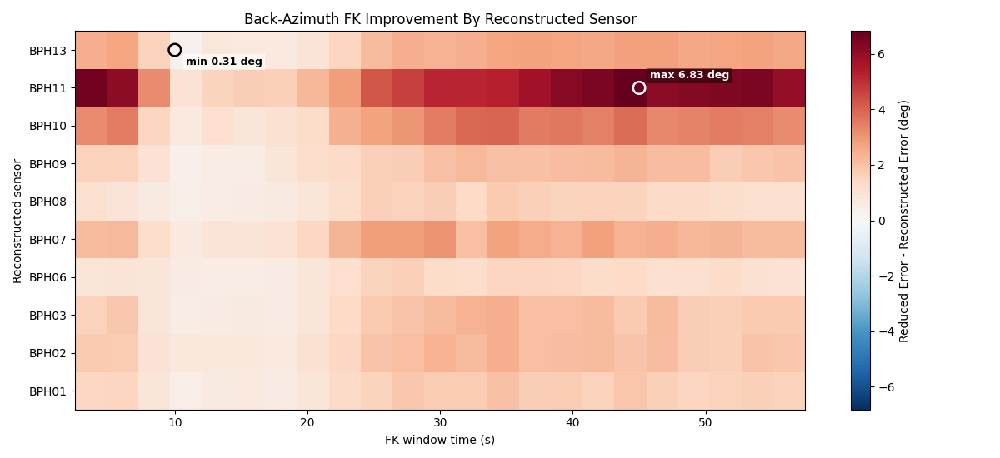

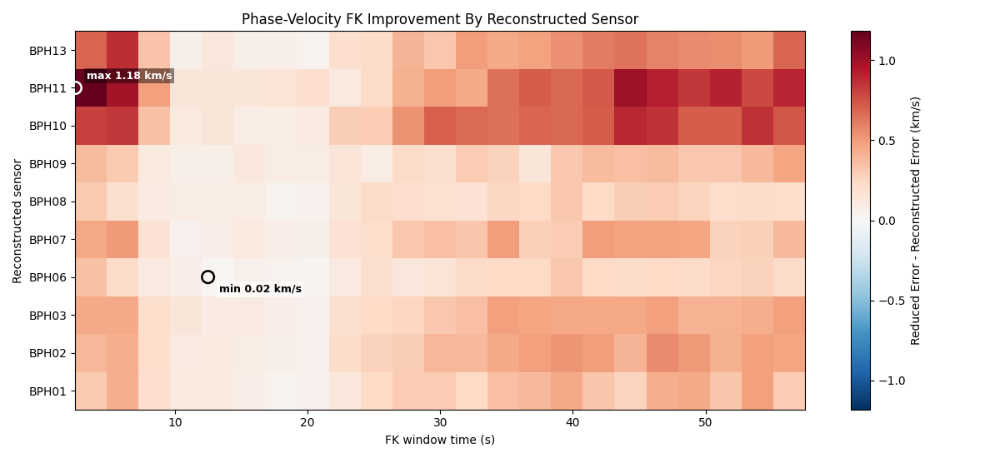

In [13]:
%%time
fig, ax, cbar, out = plot_fk_improvement_sensor_time_heatmap_from_loaded(
    combo_df=v1_combo_df,
    window_index_df=window_index_df,
    metric="baz",
    statistic="mean",
    station_order=station_order,
    save_path="Figures/VASA_v1/Physical_Validation/BAZ_Improvement_By_Sensor_And_Window.png",
)

fig, ax, cbar, out = plot_fk_improvement_sensor_time_heatmap_from_loaded(
    combo_df=v1_combo_df,
    window_index_df=window_index_df,
    metric="pv",
    statistic="mean",
    station_order=station_order,
    save_path="Figures/VASA_v1/Physical_Validation/PV_Improvement_By_Sensor_And_Window.png",
)

---
Component ablation experiment

In [4]:
%%time
COMPONENT_ABLATION_OUT_DIR = Path("Eval_Spreadsheets/VASA_v1/Component_Ablation")
COMPONENT_ABLATION_OUT_DIR.mkdir(parents=True, exist_ok=True)

COMPONENT_NAMES_DEFAULT = ["BHZ", "BHN", "BHE"]
CONFIG_LABELS = {
    "baseline": "All context components",
    "ablated": "Horizontal components withheld",
}

COMPONENT_ABLATION_REQUIRED_COLUMNS = [
    "pair_id", "event_index", "EVID", "target_sensor_index", "target_station", "component",
    "baseline_max_xcorr", "baseline_best_lag_sec", "baseline_abs_best_lag_sec",
    "baseline_rmse", "baseline_rms_ratio", "baseline_peak_ratio",
    "baseline_rms_ratio_error", "baseline_peak_ratio_error",
    "baseline_valid_correlation", "baseline_valid_abs_lag",
    "baseline_valid_rms_ratio", "baseline_valid_peak_ratio",
    "baseline_valid_all", "baseline_invalid_reason",
    "ablated_max_xcorr", "ablated_best_lag_sec", "ablated_abs_best_lag_sec",
    "ablated_rmse", "ablated_rms_ratio", "ablated_peak_ratio",
    "ablated_rms_ratio_error", "ablated_peak_ratio_error",
    "ablated_valid_correlation", "ablated_valid_abs_lag",
    "ablated_valid_rms_ratio", "ablated_valid_peak_ratio",
    "ablated_valid_all", "ablated_invalid_reason",
    "paired_valid_correlation", "paired_valid_abs_lag",
    "paired_valid_rms_error", "paired_valid_peak_error",
    "delta_correlation", "delta_abs_lag", "delta_rms_error", "delta_peak_error",
    "completed",
]


def _empty_component_ablation_results():
    return pd.DataFrame(columns=COMPONENT_ABLATION_REQUIRED_COLUMNS)


def _atomic_write_csv(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w", suffix=".tmp", prefix=path.name + ".", dir=path.parent, delete=False
    ) as tmp:
        tmp_path = Path(tmp.name)
        df.to_csv(tmp, index=index)
    os.replace(tmp_path, path)


def _atomic_write_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w", suffix=".tmp", prefix=path.name + ".", dir=path.parent, delete=False
    ) as tmp:
        tmp_path = Path(tmp.name)
        json.dump(obj, tmp, indent=2, sort_keys=True, default=str)
    os.replace(tmp_path, path)


def _hash_array(arr, max_bytes=2_000_000):
    arr = np.asarray(arr)
    h = hashlib.sha256()
    h.update(str(arr.shape).encode())
    h.update(str(arr.dtype).encode())

    flat = np.ascontiguousarray(arr).view(np.uint8)
    if flat.size:
        h.update(flat[: min(flat.size, max_bytes)])
        h.update(flat[-min(flat.size, max_bytes):])

    return h.hexdigest()


def _hash_file(path):
    if path is None:
        return None
    path = Path(path)
    if not path.exists():
        return None

    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def infer_component_indices(component_names=COMPONENT_NAMES_DEFAULT):
    upper = [str(c).upper() for c in component_names]

    z = [i for i, c in enumerate(upper) if c in {"Z", "BHZ", "HHZ", "EHZ"} or c.endswith("Z")]
    n = [i for i, c in enumerate(upper) if c in {"N", "BHN", "HHN", "EHN"} or c.endswith("N")]
    e = [i for i, c in enumerate(upper) if c in {"E", "BHE", "HHE", "EHE"} or c.endswith("E")]

    if len(z) != 1 or len(n) != 1 or len(e) != 1:
        raise ValueError(f"Could not infer Z/N/E component indices from {component_names}")

    return {"Z": z[0], "N": n[0], "E": e[0]}


def validate_component_ablation_inputs(
    X_test,
    meta_test,
    station_order,
    D_norm,
    global_center,
    global_scale,
    component_names=COMPONENT_NAMES_DEFAULT,
):
    X_test = np.asarray(X_test)

    if X_test.ndim != 4:
        raise ValueError(f"Expected X_test [N, S, T, C], got {X_test.shape}")

    n_events, sensor_dim, temporal_dim, channel_dim = X_test.shape

    if channel_dim != 3:
        raise ValueError(f"Expected 3 waveform components, got {channel_dim}")

    if len(station_order) != sensor_dim:
        raise ValueError("station_order length does not match X_test sensor dimension")

    if np.asarray(D_norm).shape != (sensor_dim, sensor_dim):
        raise ValueError("D_norm shape does not match station dimension")

    if meta_test is not None and len(meta_test) != n_events:
        raise ValueError(f"meta_test has {len(meta_test)} rows but X_test has {n_events}")

    comp_idx = infer_component_indices(component_names)

    if np.asarray(global_center).shape[-1] != 3 or np.asarray(global_scale).shape[-1] != 3:
        raise ValueError("global_center/global_scale must have component dimension length 3")

    return {
        "n_events": n_events,
        "sensor_dim": sensor_dim,
        "temporal_dim": temporal_dim,
        "channel_dim": channel_dim,
        "component_indices": comp_idx,
        "vertical_index": comp_idx["Z"],
        "horizontal_indices": [comp_idx["N"], comp_idx["E"]],
    }


def _event_id_from_meta(meta_test, event_index):
    if meta_test is None:
        return event_index

    row = meta_test.iloc[int(event_index)]
    for col in ["EVID", "ev_id", "event_id", "id"]:
        if col in row.index and pd.notna(row[col]):
            return row[col]

    return event_index


def _metadata_fields(meta_test, event_index):
    out = {}
    if meta_test is None:
        return out

    row = meta_test.iloc[int(event_index)]

    for col in ["EVID", "ev_id", "event_id", "YY/MM/DD", "YYY/MM/DD", "origin_time", "time", "date"]:
        if col in row.index:
            out[col] = row[col]

    for col in ["azimuth_deg", "AZ", "BAZ", "distance_km", "DIST", "MAG", "LAT", "LON"]:
        if col in row.index:
            val = pd.to_numeric(row[col], errors="coerce")
            if col.lower() in {"azimuth_deg", "az", "baz"} and pd.notna(val):
                val = float(val) % 360.0
            out[col] = val

    return out


def make_component_ablation_manifest(
    X_test,
    meta_test,
    station_order,
    D_norm,
    global_center,
    global_scale,
    component_names=COMPONENT_NAMES_DEFAULT,
    event_indices=None,
    final_clip=100.0,
    output_gain=1.0,
    sampling_rate=40.0,
    model_checkpoint_path=None,
    dataset_id=None,
):
    event_indices = list(range(np.asarray(X_test).shape[0])) if event_indices is None else [int(i) for i in event_indices]

    manifest = {
        "experiment": "VASA_v1_inference_time_horizontal_component_ablation",
        "dataset_id": str(dataset_id) if dataset_id is not None else None,
        "model_checkpoint_path": str(model_checkpoint_path) if model_checkpoint_path is not None else None,
        "model_checkpoint_sha256": _hash_file(model_checkpoint_path),
        "X_test_shape": list(np.asarray(X_test).shape),
        "X_test_fingerprint": _hash_array(X_test),
        "meta_test_rows": None if meta_test is None else int(len(meta_test)),
        "station_order": list(station_order),
        "component_names": list(component_names),
        "component_indices": infer_component_indices(component_names),
        "D_norm_shape": list(np.asarray(D_norm).shape),
        "D_norm_fingerprint": _hash_array(D_norm),
        "global_center": np.asarray(global_center).astype(float).tolist(),
        "global_scale": np.asarray(global_scale).astype(float).tolist(),
        "global_center_fingerprint": _hash_array(global_center),
        "global_scale_fingerprint": _hash_array(global_scale),
        "event_indices_start": int(min(event_indices)) if event_indices else None,
        "event_indices_stop": int(max(event_indices)) if event_indices else None,
        "n_event_indices": int(len(event_indices)),
        "final_clip": float(final_clip),
        "output_gain": float(output_gain),
        "sampling_rate": float(sampling_rate),
        "metric_settings": {
            "xcorr": "VASA.norm_xcorr over full 60 s vertical trace",
            "amplitude_ratios": "VASA.raw_amplitude_ratios convention",
            "lag": "signed best lag from VASA.norm_xcorr, seconds",
            "rmse": "sqrt(mean((prediction - observation)^2))",
        },
        "ablation": {
            "baseline": "target sensor waveform and observed-mask channels zeroed for all components",
            "ablated": "same target masking, plus N/E waveform and observed-mask channels zeroed at all context sensors",
            "input_layout": "concatenate([scaled_waveforms, observed_mask], axis=-1)",
        },
        "software": {
            "python": platform.python_version(),
            "platform": platform.platform(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
        },
    }

    manifest["manifest_fingerprint"] = hashlib.sha256(
        json.dumps(manifest, sort_keys=True, default=str).encode()
    ).hexdigest()

    return manifest


def _check_or_write_manifest(out_dir, manifest, overwrite=False):
    out_dir = Path(out_dir)
    manifest_path = out_dir / "component_ablation_manifest.json"

    if manifest_path.exists():
        old = json.loads(manifest_path.read_text())
        if old.get("manifest_fingerprint") != manifest.get("manifest_fingerprint"):
            if overwrite:
                warnings.warn("Overwriting incompatible manifest because overwrite=True.")
                _atomic_write_json(manifest, manifest_path)
            else:
                raise RuntimeError(
                    "Existing manifest is incompatible with this run. "
                    f"Use a new output directory or overwrite=True.\nExisting: {manifest_path}"
                )
    else:
        _atomic_write_json(manifest, manifest_path)

    return manifest_path


def build_component_ablation_inputs_for_pairs(
    X_batch,
    target_indices,
    global_center,
    global_scale,
    horizontal_indices,
    output_gain=1.0,
    final_clip=100.0,
):
    X_batch = np.asarray(X_batch, dtype=np.float32)
    target_indices = np.asarray(target_indices, dtype=int)
    horizontal_indices = [int(i) for i in horizontal_indices]

    scaled = VASA.global_asinh_scale(
        tf.constant(X_batch),
        global_center=tf.constant(global_center, dtype=tf.float32),
        global_scale=tf.constant(global_scale, dtype=tf.float32),
        output_gain=output_gain,
        final_clip=final_clip,
    ).numpy().astype(np.float32)

    baseline_observed = np.ones_like(scaled, dtype=np.float32)
    ablated_observed = np.ones_like(scaled, dtype=np.float32)

    for bi, target_idx in enumerate(target_indices):
        target_idx = int(target_idx)

        baseline_observed[bi, target_idx, :, :] = 0.0
        ablated_observed[bi, target_idx, :, :] = 0.0

        context_indices = [si for si in range(scaled.shape[1]) if si != target_idx]

        for comp_idx in horizontal_indices:
            ablated_observed[bi, context_indices, :, comp_idx] = 0.0

    baseline_input = np.concatenate(
        [scaled * baseline_observed, baseline_observed],
        axis=-1,
    ).astype(np.float32)

    ablated_input = np.concatenate(
        [scaled * ablated_observed, ablated_observed],
        axis=-1,
    ).astype(np.float32)

    return baseline_input, ablated_input, scaled, baseline_observed, ablated_observed


def verify_component_ablation_masks(
    X_batch,
    target_indices,
    global_center,
    global_scale,
    horizontal_indices,
    vertical_index,
    output_gain=1.0,
    final_clip=100.0,
):
    horizontal_indices = [int(i) for i in horizontal_indices]
    vertical_index = int(vertical_index)

    baseline_input, ablated_input, scaled, baseline_obs, ablated_obs = build_component_ablation_inputs_for_pairs(
        X_batch=X_batch,
        target_indices=target_indices,
        global_center=global_center,
        global_scale=global_scale,
        horizontal_indices=horizontal_indices,
        output_gain=output_gain,
        final_clip=final_clip,
    )

    target_indices = np.asarray(target_indices, dtype=int)
    sensor_dim = scaled.shape[1]

    for bi, target_idx in enumerate(target_indices):
        target_idx = int(target_idx)

        if not np.all(baseline_obs[bi, target_idx, :, :] == 0.0):
            raise AssertionError("Baseline target sensor is not fully withheld.")

        if not np.all(ablated_obs[bi, target_idx, :, :] == 0.0):
            raise AssertionError("Ablated target sensor is not fully withheld.")

        context_indices = [si for si in range(sensor_dim) if si != target_idx]

        if not np.all(baseline_obs[bi, context_indices, :, :] == 1.0):
            raise AssertionError("Baseline context observations are not fully available.")

        if not np.all(ablated_obs[bi, context_indices, :, vertical_index] == 1.0):
            raise AssertionError("Ablated vertical context observations were changed.")

        for comp_idx in horizontal_indices:
            if not np.all(ablated_obs[bi, context_indices, :, comp_idx] == 0.0):
                raise AssertionError("Ablated horizontal context observations were not withheld.")

        if not np.allclose(
            baseline_input[bi, context_indices, :, vertical_index],
            ablated_input[bi, context_indices, :, vertical_index],
            equal_nan=True,
        ):
            raise AssertionError("Vertical context waveform inputs differ between configurations.")

    return {
        "verified": True,
        "n_differing_input_entries": int(np.sum(np.not_equal(baseline_input, ablated_input))),
        "baseline_input_shape": baseline_input.shape,
        "ablated_input_shape": ablated_input.shape,
    }


def _safe_vertical_metrics(y_true, y_pred, time_vector):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    out = {
        "valid_correlation": False,
        "valid_abs_lag": False,
        "valid_rms_ratio": False,
        "valid_peak_ratio": False,
        "valid_all": False,
        "invalid_reason": "",
        "max_xcorr": np.nan,
        "best_lag_sec": np.nan,
        "abs_best_lag_sec": np.nan,
        "rmse": np.nan,
        "rms_ratio": np.nan,
        "peak_ratio": np.nan,
        "rms_ratio_error": np.nan,
        "peak_ratio_error": np.nan,
    }

    reasons = []

    if y_true.shape != y_pred.shape:
        reasons.append(f"shape_mismatch true={y_true.shape} pred={y_pred.shape}")

    if not np.all(np.isfinite(y_true)):
        reasons.append("nonfinite_true")

    if not np.all(np.isfinite(y_pred)):
        reasons.append("nonfinite_prediction")

    true_rms = float(np.sqrt(np.mean(y_true ** 2))) if y_true.size else np.nan
    true_peak = float(np.max(np.abs(y_true))) if y_true.size else np.nan
    pred_rms = float(np.sqrt(np.mean(y_pred ** 2))) if y_pred.size else np.nan
    pred_peak = float(np.max(np.abs(y_pred))) if y_pred.size else np.nan

    if not np.isfinite(true_rms) or true_rms == 0:
        reasons.append("zero_or_nonfinite_true_rms")

    if not np.isfinite(true_peak) or true_peak == 0:
        reasons.append("zero_or_nonfinite_true_peak")

    if not np.isfinite(np.nanstd(y_true)) or np.nanstd(y_true) == 0:
        reasons.append("zero_or_nonfinite_true_std")

    if not np.isfinite(np.nanstd(y_pred)) or np.nanstd(y_pred) == 0:
        reasons.append("zero_or_nonfinite_pred_std")

    if len(reasons) == 0:
        try:
            lags_sec, xcorr = VASA.norm_xcorr(time_vector, y_true, y_pred)

            if np.any(np.isfinite(xcorr)):
                best_idx = int(np.nanargmax(xcorr))
                out["max_xcorr"] = float(xcorr[best_idx])
                out["best_lag_sec"] = float(lags_sec[best_idx])
                out["abs_best_lag_sec"] = abs(out["best_lag_sec"])
                out["valid_correlation"] = True
                out["valid_abs_lag"] = True
            else:
                reasons.append("nonfinite_xcorr")

        except Exception as exc:
            reasons.append(f"xcorr_failed:{type(exc).__name__}")

    if np.all(np.isfinite(y_true)) and np.all(np.isfinite(y_pred)):
        out["rmse"] = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

    if np.isfinite(true_rms) and true_rms > 0 and np.isfinite(pred_rms):
        out["rms_ratio"] = float(pred_rms / true_rms)
        out["rms_ratio_error"] = abs(out["rms_ratio"] - 1.0)
        out["valid_rms_ratio"] = True

    if np.isfinite(true_peak) and true_peak > 0 and np.isfinite(pred_peak):
        out["peak_ratio"] = float(pred_peak / true_peak)
        out["peak_ratio_error"] = abs(out["peak_ratio"] - 1.0)
        out["valid_peak_ratio"] = True

    out["valid_all"] = bool(
        out["valid_correlation"]
        and out["valid_abs_lag"]
        and out["valid_rms_ratio"]
        and out["valid_peak_ratio"]
        and np.isfinite(out["rmse"])
    )

    out["invalid_reason"] = ";".join(sorted(set(reasons)))
    return out


def _predict_two_configs(model, baseline_input, ablated_input, D_norm, batch_size=32):
    n = baseline_input.shape[0]
    d_batch = np.repeat(np.asarray(D_norm, dtype=np.float32)[None, :, :], n, axis=0)

    baseline_preds = model.predict(
        {"seismic_input": baseline_input, "distance_input": d_batch},
        batch_size=batch_size,
        verbose=0,
    )

    ablated_preds = model.predict(
        {"seismic_input": ablated_input, "distance_input": d_batch},
        batch_size=batch_size,
        verbose=0,
    )

    baseline_scaled = VASA.get_3branch_predictions(baseline_preds).astype(np.float32)
    ablated_scaled = VASA.get_3branch_predictions(ablated_preds).astype(np.float32)

    return baseline_scaled, ablated_scaled


def evaluate_component_ablation_batch(
    model,
    X_test,
    pairs,
    D_norm,
    global_center,
    global_scale,
    station_order,
    meta_test=None,
    component_names=COMPONENT_NAMES_DEFAULT,
    sampling_rate=40.0,
    output_gain=1.0,
    final_clip=100.0,
    model_batch_size=32,
):
    info = validate_component_ablation_inputs(
        X_test=X_test,
        meta_test=meta_test,
        station_order=station_order,
        D_norm=D_norm,
        global_center=global_center,
        global_scale=global_scale,
        component_names=component_names,
    )

    vertical_index = info["vertical_index"]
    horizontal_indices = info["horizontal_indices"]

    event_indices = np.asarray([p[0] for p in pairs], dtype=int)
    target_indices = np.asarray([p[1] for p in pairs], dtype=int)

    X_batch = np.asarray(X_test[event_indices], dtype=np.float32)

    baseline_input, ablated_input, scaled, _, _ = build_component_ablation_inputs_for_pairs(
        X_batch=X_batch,
        target_indices=target_indices,
        global_center=global_center,
        global_scale=global_scale,
        horizontal_indices=horizontal_indices,
        output_gain=output_gain,
        final_clip=final_clip,
    )

    baseline_pred_scaled, ablated_pred_scaled = _predict_two_configs(
        model=model,
        baseline_input=baseline_input,
        ablated_input=ablated_input,
        D_norm=D_norm,
        batch_size=model_batch_size,
    )

    true_full = VASA.inverse_global_asinh_scale(scaled, global_center, global_scale, output_gain)
    baseline_full = VASA.inverse_global_asinh_scale(baseline_pred_scaled, global_center, global_scale, output_gain)
    ablated_full = VASA.inverse_global_asinh_scale(ablated_pred_scaled, global_center, global_scale, output_gain)

    time_vector = np.arange(X_test.shape[2], dtype=float) / float(sampling_rate)

    rows = []

    for i, (event_index, target_index) in enumerate(pairs):
        y_true = true_full[i, target_index, :, vertical_index]
        y_base = baseline_full[i, target_index, :, vertical_index]
        y_abl = ablated_full[i, target_index, :, vertical_index]

        base_m = _safe_vertical_metrics(y_true, y_base, time_vector)
        abl_m = _safe_vertical_metrics(y_true, y_abl, time_vector)

        row = {
            "pair_id": f"{int(event_index)}__{int(target_index)}",
            "event_index": int(event_index),
            "EVID": _event_id_from_meta(meta_test, int(event_index)),
            "target_sensor_index": int(target_index),
            "target_station": station_order[int(target_index)],
            "component": component_names[vertical_index],
            "vertical_component_index": int(vertical_index),
            "horizontal_component_indices": json.dumps([int(x) for x in horizontal_indices]),
        }

        row.update(_metadata_fields(meta_test, int(event_index)))

        for prefix, metrics in [("baseline", base_m), ("ablated", abl_m)]:
            for key, val in metrics.items():
                row[f"{prefix}_{key}"] = val

        paired_corr = bool(base_m["valid_correlation"] and abl_m["valid_correlation"])
        paired_lag = bool(base_m["valid_abs_lag"] and abl_m["valid_abs_lag"])
        paired_rms = bool(base_m["valid_rms_ratio"] and abl_m["valid_rms_ratio"])
        paired_peak = bool(base_m["valid_peak_ratio"] and abl_m["valid_peak_ratio"])

        row["paired_valid_correlation"] = paired_corr
        row["paired_valid_abs_lag"] = paired_lag
        row["paired_valid_rms_error"] = paired_rms
        row["paired_valid_peak_error"] = paired_peak

        row["delta_correlation"] = abl_m["max_xcorr"] - base_m["max_xcorr"] if paired_corr else np.nan
        row["delta_abs_lag"] = abl_m["abs_best_lag_sec"] - base_m["abs_best_lag_sec"] if paired_lag else np.nan
        row["delta_rms_error"] = abl_m["rms_ratio_error"] - base_m["rms_ratio_error"] if paired_rms else np.nan
        row["delta_peak_error"] = abl_m["peak_ratio_error"] - base_m["peak_ratio_error"] if paired_peak else np.nan
        row["completed"] = True

        rows.append(row)

    return pd.DataFrame(rows)


def load_component_ablation_results(out_dir=COMPONENT_ABLATION_OUT_DIR):
    """Merge the combined CSV and all completed batch chunks."""
    out_dir = Path(out_dir)
    combined_path = out_dir / "component_ablation_results.csv"

    files = [combined_path] if combined_path.exists() else []
    files += sorted(
        (out_dir / "chunks").glob("component_ablation_chunk_*.csv")
    )

    tables = []
    required = {
        "pair_id", "event_index", "target_sensor_index", "completed"
    }

    for path in files:
        # Fail visibly on damaged CSVs; atomic-write temporary files
        # do not match the chunk filename pattern.
        df = pd.read_csv(path)
        if df.empty:
            continue

        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"Missing columns in {path}: {missing}")

        expected_ids = (
            df["event_index"].astype(int).astype(str)
            + "__"
            + df["target_sensor_index"].astype(int).astype(str)
        )
        if not df["pair_id"].astype(str).eq(expected_ids).all():
            raise ValueError(f"Inconsistent event-target IDs in {path}")

        complete = (
            df["completed"].astype(str).str.lower().isin(["true", "1"])
        )
        tables.append(df.loc[complete])

    if not tables:
        return _empty_component_ablation_results()

    return (
        pd.concat(tables, ignore_index=True)
        .drop_duplicates("pair_id", keep="last")
        .sort_values(["event_index", "target_sensor_index"])
        .reset_index(drop=True)
    )


def _completed_event_counts(results_df):
    if results_df is None or len(results_df) == 0 or "event_index" not in results_df.columns:
        return {}

    return {
        int(k): set(v.astype(str))
        for k, v in results_df.groupby("event_index")["pair_id"]
    }


def evaluate_component_ablation_resumable(
    model,
    X_test,
    D_norm,
    global_center,
    global_scale,
    station_order,
    meta_test=None,
    component_names=COMPONENT_NAMES_DEFAULT,
    out_dir=COMPONENT_ABLATION_OUT_DIR,
    event_indices=None,
    max_events=None,
    target_sensor_indices=None,
    batch_size=32,
    checkpoint_every_pairs=320,
    resume=True,
    overwrite=False,
    sampling_rate=40.0,
    output_gain=1.0,
    final_clip=100.0,
    model_checkpoint_path=None,
    dataset_id=None,
    print_each_event=True,
):
    out_dir = Path(out_dir)
    chunk_dir = out_dir / "chunks"
    out_dir.mkdir(parents=True, exist_ok=True)
    chunk_dir.mkdir(parents=True, exist_ok=True)

    info = validate_component_ablation_inputs(
        X_test=X_test,
        meta_test=meta_test,
        station_order=station_order,
        D_norm=D_norm,
        global_center=global_center,
        global_scale=global_scale,
        component_names=component_names,
    )

    n_events = info["n_events"]
    sensor_dim = info["sensor_dim"]

    if event_indices is None:
        event_indices = list(range(n_events))
    else:
        event_indices = [int(i) for i in event_indices]

    if max_events is not None:
        event_indices = event_indices[: int(max_events)]

    if target_sensor_indices is None:
        target_sensor_indices = list(range(sensor_dim))
    else:
        target_sensor_indices = [int(i) for i in target_sensor_indices]

    manifest = make_component_ablation_manifest(
        X_test=X_test,
        meta_test=meta_test,
        station_order=station_order,
        D_norm=D_norm,
        global_center=global_center,
        global_scale=global_scale,
        component_names=component_names,
        event_indices=event_indices,
        final_clip=final_clip,
        output_gain=output_gain,
        sampling_rate=sampling_rate,
        model_checkpoint_path=model_checkpoint_path,
        dataset_id=dataset_id,
    )

    manifest_path = _check_or_write_manifest(out_dir, manifest, overwrite=overwrite)

    all_pairs = [(ei, si) for ei in event_indices for si in target_sensor_indices]

    if overwrite:
        for old in chunk_dir.glob("component_ablation_chunk_*.csv"):
            old.unlink()

        for old_name in [
            "component_ablation_results.csv",
            "component_ablation_failures.csv",
            "component_ablation_performance_by_sensor.csv",
            "component_ablation_paired_delta_by_sensor.csv",
        ]:
            old_path = out_dir / old_name
            if old_path.exists():
                old_path.unlink()

        existing = _empty_component_ablation_results()

    elif resume:
        existing = load_component_ablation_results(out_dir)

    else:
        existing = _empty_component_ablation_results()

        if (out_dir / "component_ablation_results.csv").exists():
            raise RuntimeError("Existing results found. Use resume=True or overwrite=True.")

    completed_ids = (
        set(existing["pair_id"].astype(str))
        if len(existing) and "pair_id" in existing.columns
        else set()
    )

    missing_pairs = [
        pair for pair in all_pairs
        if f"{int(pair[0])}__{int(pair[1])}" not in completed_ids
    ]

    event_done_pairs = _completed_event_counts(existing)
    printed_completed_events = set()

    for event_idx, done_set in event_done_pairs.items():
        expected = {f"{int(event_idx)}__{int(si)}" for si in target_sensor_indices}
        if expected.issubset(done_set):
            printed_completed_events.add(int(event_idx))

    print(f"Output directory: {out_dir.resolve()}")
    print(f"Manifest: {manifest_path.resolve()}")
    print(f"Requested pairs: {len(all_pairs)}")
    print(f"Already completed: {len(completed_ids)}")
    print(f"Missing pairs to run: {len(missing_pairs)}")

    if len(missing_pairs) == 0:
        final_df = existing.drop_duplicates("pair_id", keep="last").reset_index(drop=True)
        _atomic_write_csv(final_df, out_dir / "component_ablation_results.csv", index=False)

        print("No missing pairs. Existing run is complete.")

        return {
            "results": final_df,
            "out_dir": out_dir,
            "manifest": manifest,
            "status": "complete",
            "failures": pd.DataFrame(),
        }

    started = time.time()
    processed = 0
    failures = []

    for batch_start in range(0, len(missing_pairs), batch_size):
        batch_pairs = missing_pairs[batch_start:batch_start + batch_size]

        try:
            batch_df = evaluate_component_ablation_batch(
                model=model,
                X_test=X_test,
                pairs=batch_pairs,
                D_norm=D_norm,
                global_center=global_center,
                global_scale=global_scale,
                station_order=station_order,
                meta_test=meta_test,
                component_names=component_names,
                sampling_rate=sampling_rate,
                output_gain=output_gain,
                final_clip=final_clip,
                model_batch_size=batch_size,
            )

            timestamp = time.strftime("%Y%m%d_%H%M%S")
            chunk_path = (
                chunk_dir
                / f"component_ablation_chunk_{timestamp}_{batch_start:08d}_{batch_start + len(batch_pairs) - 1:08d}.csv"
            )

            _atomic_write_csv(batch_df, chunk_path, index=False)
            processed += len(batch_df)

            if print_each_event:
                for event_idx, pair_ids in batch_df.groupby("event_index")["pair_id"]:
                    event_idx = int(event_idx)

                    if event_idx not in event_done_pairs:
                        event_done_pairs[event_idx] = set()

                    event_done_pairs[event_idx].update(pair_ids.astype(str).tolist())

                    expected = {f"{event_idx}__{int(si)}" for si in target_sensor_indices}

                    if event_idx not in printed_completed_events and expected.issubset(event_done_pairs[event_idx]):
                        elapsed_min = (time.time() - started) / 60.0
                        print(
                            f"Done with event {event_idx} "
                            f"({len(printed_completed_events) + 1}/{len(event_indices)} events complete) | "
                            f"elapsed {elapsed_min:.1f} min"
                        )
                        printed_completed_events.add(event_idx)

        except Exception as exc:
            for event_index, target_index in batch_pairs:
                failures.append({
                    "pair_id": f"{int(event_index)}__{int(target_index)}",
                    "event_index": int(event_index),
                    "target_sensor_index": int(target_index),
                    "target_station": station_order[int(target_index)],
                    "error": repr(exc),
                })

            warnings.warn(f"Batch failed at batch_start={batch_start}: {exc}")

        should_checkpoint = (
            processed > 0
            and (
                processed % int(checkpoint_every_pairs) == 0
                or batch_start + batch_size >= len(missing_pairs)
            )
        )

        if should_checkpoint:
            combined = load_component_ablation_results(out_dir)

            if len(combined):
                combined = combined.drop_duplicates("pair_id", keep="last").reset_index(drop=True)
                _atomic_write_csv(combined, out_dir / "component_ablation_results.csv", index=False)

            if failures:
                _atomic_write_csv(
                    pd.DataFrame(failures),
                    out_dir / "component_ablation_failures.csv",
                    index=False,
                )

            elapsed_min = (time.time() - started) / 60.0
            print(
                f"Checkpoint: processed new={processed}, "
                f"total complete={len(combined)}, "
                f"failures={len(failures)}, "
                f"elapsed={elapsed_min:.1f} min"
            )

    final_df = load_component_ablation_results(out_dir)

    if len(final_df):
        final_df = final_df.drop_duplicates("pair_id", keep="last").reset_index(drop=True)
        _atomic_write_csv(final_df, out_dir / "component_ablation_results.csv", index=False)
    else:
        final_df = _empty_component_ablation_results()

    failures_df = pd.DataFrame(failures)

    if len(failures_df):
        _atomic_write_csv(
            failures_df,
            out_dir / "component_ablation_failures.csv",
            index=False,
        )

    expected_n = len(all_pairs)

    print(f"Done. Complete rows: {len(final_df)} / {expected_n}")
    print(f"Results: {(out_dir / 'component_ablation_results.csv').resolve()}")

    if len(failures_df):
        print(f"Failures: {(out_dir / 'component_ablation_failures.csv').resolve()}")
        display(failures_df.head())

    return {
        "results": final_df,
        "out_dir": out_dir,
        "manifest": manifest,
        "failures": failures_df,
        "status": "complete" if len(final_df) == expected_n else "partial",
    }


def bootstrap_mean_ci(values, n_boot=1000, seed=42, ci=95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return np.nan, np.nan, np.nan, 0

    mean = float(np.mean(values))

    if values.size == 1:
        return mean, np.nan, np.nan, 1

    rng = np.random.default_rng(seed)
    boot = np.empty(int(n_boot), dtype=float)

    for i in range(int(n_boot)):
        boot[i] = np.mean(rng.choice(values, size=values.size, replace=True))

    alpha = (100 - ci) / 2
    lo, hi = np.nanpercentile(boot, [alpha, 100 - alpha])

    return mean, float(lo), float(hi), int(values.size)


def summarize_component_ablation_by_sensor(
    results_df,
    station_order,
    n_boot=1000,
    seed=42,
    sensor_subset=None,
):
    df = results_df.copy()

    if len(df) == 0:
        raise RuntimeError(
            "No component-ablation result rows were found. "
            "Check component_ablation_failures.csv in the output directory."
        )

    missing = [c for c in ["target_station", "target_sensor_index", "pair_id"] if c not in df.columns]
    if missing:
        raise RuntimeError(f"Results table is missing required columns: {missing}")

    if sensor_subset is not None:
        df = df[df["target_station"].isin(sensor_subset)].copy()

    station_order_use = [s for s in station_order if s in set(df["target_station"])]

    performance_specs = [
        ("max_xcorr", "correlation", "valid_correlation"),
        ("abs_best_lag_sec", "abs_lag", "valid_abs_lag"),
        ("rms_ratio", "rms_ratio", "valid_rms_ratio"),
        ("peak_ratio", "peak_ratio", "valid_peak_ratio"),
        ("rms_ratio_error", "rms_error", "valid_rms_ratio"),
        ("peak_ratio_error", "peak_error", "valid_peak_ratio"),
    ]

    perf_rows = []

    for station in station_order_use:
        g = df[df["target_station"] == station]

        for config in ["baseline", "ablated"]:
            for metric_col, metric_name, valid_name in performance_specs:
                col = f"{config}_{metric_col}"
                valid_col = f"{config}_{valid_name}"

                if col not in g.columns or valid_col not in g.columns:
                    vals = np.asarray([], dtype=float)
                else:
                    vals = g.loc[g[valid_col].astype(bool), col].astype(float).to_numpy()

                mean, lo, hi, n_valid = bootstrap_mean_ci(vals, n_boot=n_boot, seed=seed)

                perf_rows.append({
                    "target_station": station,
                    "target_sensor_index": int(g["target_sensor_index"].iloc[0]) if len(g) else np.nan,
                    "configuration": config,
                    "configuration_label": CONFIG_LABELS[config],
                    "metric": metric_name,
                    "mean": mean,
                    "ci_low": lo,
                    "ci_high": hi,
                    "n_valid_events": n_valid,
                })

    delta_specs = [
        ("delta_correlation", "delta_correlation", "paired_valid_correlation"),
        ("delta_abs_lag", "delta_abs_lag", "paired_valid_abs_lag"),
        ("delta_rms_error", "delta_rms_error", "paired_valid_rms_error"),
        ("delta_peak_error", "delta_peak_error", "paired_valid_peak_error"),
    ]

    delta_rows = []

    for station in station_order_use:
        g = df[df["target_station"] == station]

        for col, metric_name, valid_col in delta_specs:
            if col not in g.columns or valid_col not in g.columns:
                vals = np.asarray([], dtype=float)
            else:
                vals = g.loc[g[valid_col].astype(bool), col].astype(float).to_numpy()

            mean, lo, hi, n_valid = bootstrap_mean_ci(vals, n_boot=n_boot, seed=seed)

            delta_rows.append({
                "target_station": station,
                "target_sensor_index": int(g["target_sensor_index"].iloc[0]) if len(g) else np.nan,
                "metric": metric_name,
                "mean": mean,
                "ci_low": lo,
                "ci_high": hi,
                "n_valid_events": n_valid,
            })

    perf_summary = pd.DataFrame(perf_rows)
    delta_summary = pd.DataFrame(delta_rows)

    if len(perf_summary):
        perf_summary["target_station"] = pd.Categorical(
            perf_summary["target_station"],
            categories=station_order_use,
            ordered=True,
        )
        perf_summary = perf_summary.sort_values(
            ["target_station", "configuration", "metric"]
        ).reset_index(drop=True)

    if len(delta_summary):
        delta_summary["target_station"] = pd.Categorical(
            delta_summary["target_station"],
            categories=station_order_use,
            ordered=True,
        )
        delta_summary = delta_summary.sort_values(
            ["target_station", "metric"]
        ).reset_index(drop=True)

    return {
        "performance_by_sensor": perf_summary,
        "paired_delta_by_sensor": delta_summary,
    }


def save_component_ablation_summaries(
    results_df,
    station_order,
    out_dir=COMPONENT_ABLATION_OUT_DIR,
    n_boot=1000,
    seed=42,
):
    out_dir = Path(out_dir)

    summaries = summarize_component_ablation_by_sensor(
        results_df=results_df,
        station_order=station_order,
        n_boot=n_boot,
        seed=seed,
    )

    _atomic_write_csv(
        summaries["performance_by_sensor"],
        out_dir / "component_ablation_performance_by_sensor.csv",
        index=False,
    )

    _atomic_write_csv(
        summaries["paired_delta_by_sensor"],
        out_dir / "component_ablation_paired_delta_by_sensor.csv",
        index=False,
    )

    return summaries


def _summary_metric(summary_df, metric):
    return summary_df[summary_df["metric"] == metric].copy()


def plot_component_ablation_performance_by_sensor(
    performance_summary,
    station_order,
    sensor_subset=None,
    figsize=(13, 8),
    colors=None,
    save_path_png=None,
    save_path_pdf=None,
    dpi=300,
):
    if colors is None:
        colors = {"baseline": "black", "ablated": "crimson"}

    station_order_use = list(station_order)

    if sensor_subset is not None:
        station_order_use = [s for s in station_order_use if s in set(sensor_subset)]

    df = performance_summary.copy()
    df = df[df["target_station"].isin(station_order_use)].copy()

    metrics = [
        ("correlation", "Maximum normalized cross-correlation", None),
        ("abs_lag", "Absolute best lag (s)", 0.0),
        ("rms_ratio", "RMS amplitude ratio", 1.0),
        ("peak_ratio", "Peak amplitude ratio", 1.0),
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
    axes = axes.ravel()
    x = np.arange(len(station_order_use))

    for ax, (metric, ylabel, refline) in zip(axes, metrics):
        gm = _summary_metric(df, metric)

        for config in ["baseline", "ablated"]:
            g = gm[gm["configuration"] == config].copy()
            g["target_station"] = pd.Categorical(
                g["target_station"],
                categories=station_order_use,
                ordered=True,
            )
            g = g.sort_values("target_station")

            y = g["mean"].to_numpy(dtype=float)
            lo = g["ci_low"].to_numpy(dtype=float)
            hi = g["ci_high"].to_numpy(dtype=float)

            yerr = np.vstack([y - lo, hi - y])
            yerr[:, ~np.all(np.isfinite(yerr), axis=0)] = np.nan

            offset = -0.08 if config == "baseline" else 0.08

            ax.errorbar(
                x + offset,
                y,
                yerr=yerr,
                fmt="o",
                color=colors[config],
                ecolor=colors[config],
                capsize=3,
                linewidth=1.5,
                label=CONFIG_LABELS[config],
            )

        if refline is not None:
            ax.axhline(refline, color="0.4", linestyle="--", linewidth=1.0)

        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

    axes[0].legend(frameon=True)
    axes[0].set_title("All context components vs horizontal components withheld")
    axes[1].set_title("Vertical reconstruction at withheld target sensor")

    for ax in axes[2:]:
        ax.set_xticks(x)
        ax.set_xticklabels(station_order_use, rotation=45, ha="right")

    fig.tight_layout()

    if save_path_png is not None:
        Path(save_path_png).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path_png, dpi=dpi, bbox_inches="tight")

    if save_path_pdf is not None:
        Path(save_path_pdf).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path_pdf, bbox_inches="tight")

    return fig, axes


def plot_component_ablation_paired_effects_by_sensor(
    delta_summary,
    station_order,
    sensor_subset=None,
    figsize=(13, 8),
    color="royalblue",
    save_path_png=None,
    save_path_pdf=None,
    dpi=300,
):
    station_order_use = list(station_order)

    if sensor_subset is not None:
        station_order_use = [s for s in station_order_use if s in set(sensor_subset)]

    df = delta_summary.copy()
    df = df[df["target_station"].isin(station_order_use)].copy()

    metrics = [
        ("delta_correlation", "Ablated - baseline\ncorrelation"),
        ("delta_abs_lag", "Ablated - baseline\nabsolute lag (s)"),
        ("delta_rms_error", "Ablated - baseline\n|RMS ratio - 1|"),
        ("delta_peak_error", "Ablated - baseline\n|Peak ratio - 1|"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
    axes = axes.ravel()
    x = np.arange(len(station_order_use))

    for ax, (metric, ylabel) in zip(axes, metrics):
        g = _summary_metric(df, metric)
        g["target_station"] = pd.Categorical(
            g["target_station"],
            categories=station_order_use,
            ordered=True,
        )
        g = g.sort_values("target_station")

        y = g["mean"].to_numpy(dtype=float)
        lo = g["ci_low"].to_numpy(dtype=float)
        hi = g["ci_high"].to_numpy(dtype=float)

        yerr = np.vstack([y - lo, hi - y])
        yerr[:, ~np.all(np.isfinite(yerr), axis=0)] = np.nan

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o",
            color=color,
            ecolor=color,
            capsize=3,
            linewidth=1.5,
        )

        ax.axhline(0.0, color="0.35", linestyle="--", linewidth=1.0)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

    axes[0].set_title("Paired horizontal-component ablation effect")
    axes[1].set_title("Negative correlation change indicates degradation")
    axes[2].set_title("Positive lag/error changes indicate degradation")

    for ax in axes[2:]:
        ax.set_xticks(x)
        ax.set_xticklabels(station_order_use, rotation=45, ha="right")

    fig.tight_layout()

    if save_path_png is not None:
        Path(save_path_png).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path_png, dpi=dpi, bbox_inches="tight")

    if save_path_pdf is not None:
        Path(save_path_pdf).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path_pdf, bbox_inches="tight")

    return fig, axes

CPU times: user 162 μs, sys: 17 μs, total: 179 μs
Wall time: 355 μs


In [6]:
%%time
# Run processing
component_ablation_full = evaluate_component_ablation_resumable(
    model=vasa_v1,
    X_test=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    station_order=station_order,
    meta_test=meta_test,
    component_names=["BHZ", "BHN", "BHE"],
    out_dir=COMPONENT_ABLATION_OUT_DIR,
    event_indices=None,
    max_events=None,
    target_sensor_indices=None,
    batch_size=32,
    checkpoint_every_pairs=320,
    resume=True,
    overwrite=False,
    sampling_rate=40.0,
    final_clip=100.0,
    model_checkpoint_path="Models/vasa_v1_1000epochs_extracted/model.weights.h5",
    dataset_id="X_test5.npy",
)

component_ablation_results = component_ablation_full["results"]

component_ablation_summaries = save_component_ablation_summaries(
    component_ablation_results,
    station_order=station_order,
    out_dir=COMPONENT_ABLATION_OUT_DIR,
    n_boot=1000,
    seed=42,
)

print(f"Saved results to {COMPONENT_ABLATION_OUT_DIR.resolve()}")
display(component_ablation_summaries["performance_by_sensor"])
display(component_ablation_summaries["paired_delta_by_sensor"])

Output directory: /users/mronacgiannone/Virtual_Arrays/Eval_Spreadsheets/VASA_v1/Component_Ablation
Manifest: /users/mronacgiannone/Virtual_Arrays/Eval_Spreadsheets/VASA_v1/Component_Ablation/component_ablation_manifest.json
Requested pairs: 60000
Already completed: 60000
Missing pairs to run: 0
No missing pairs. Existing run is complete.
Saved results to /users/mronacgiannone/Virtual_Arrays/Eval_Spreadsheets/VASA_v1/Component_Ablation


,target_station,target_sensor_index,configuration,configuration_label,metric,mean,ci_low,ci_high,n_valid_events
0,BPH01,0,ablated,Horizontal components withheld,abs_lag,0.003017,0.001354,0.005646,6000
1,BPH01,0,ablated,Horizontal components withheld,correlation,0.949451,0.947450,0.951496,6000
2,BPH01,0,ablated,Horizontal components withheld,peak_error,0.118368,0.115713,0.121371,6000
3,BPH01,0,ablated,Horizontal components withheld,peak_ratio,1.043456,1.039763,1.047248,6000
4,BPH01,0,ablated,Horizontal components withheld,rms_error,0.065573,0.063264,0.067828,6000
...,...,...,...,...,...,...,...,...,...
115,BPH13,9,baseline,All context components,correlation,0.887918,0.886395,0.889429,6000
116,BPH13,9,baseline,All context components,peak_error,0.163163,0.160133,0.166325,6000
117,BPH13,9,baseline,All context components,peak_ratio,0.958473,0.953577,0.963446,6000
118,BPH13,9,baseline,All context components,rms_error,0.150273,0.147731,0.152727,6000


,target_station,target_sensor_index,metric,mean,ci_low,ci_high,n_valid_events
0,BPH01,0,delta_abs_lag,0.000229,0.000171,0.000300,6000
1,BPH01,0,delta_correlation,-0.000212,-0.000263,-0.000165,6000
2,BPH01,0,delta_peak_error,0.003262,0.002449,0.004046,6000
3,BPH01,0,delta_rms_error,-0.002281,-0.002498,-0.002069,6000
4,BPH02,1,delta_abs_lag,0.000000,-0.000017,0.000017,6000
5,BPH02,1,delta_correlation,-0.000007,-0.000027,0.000010,6000
6,BPH02,1,delta_peak_error,-0.001154,-0.001837,-0.000447,6000
7,BPH02,1,delta_rms_error,0.000369,0.000092,0.000651,6000
8,BPH03,2,delta_abs_lag,0.000000,-0.000013,0.000008,6000
9,BPH03,2,delta_correlation,-0.000078,-0.000104,-0.000052,6000


CPU times: user 18 s, sys: 422 ms, total: 18.5 s
Wall time: 28.9 s


---
Load results

In [5]:
%%time
COMPONENT_ABLATION_OUT_DIR = Path(
    "Eval_Spreadsheets/VASA_v1/Component_Ablation"
)

component_ablation_results = pd.read_csv(
    COMPONENT_ABLATION_OUT_DIR / "component_ablation_results.csv"
)

component_ablation_summaries = {
    "performance_by_sensor": pd.read_csv(
        COMPONENT_ABLATION_OUT_DIR
        / "component_ablation_performance_by_sensor.csv"
    ),
    "paired_delta_by_sensor": pd.read_csv(
        COMPONENT_ABLATION_OUT_DIR
        / "component_ablation_paired_delta_by_sensor.csv"
    ),
}

if component_ablation_results.duplicated(
    ["event_index", "target_sensor_index"]
).any():
    raise ValueError("Duplicate event-target comparisons found.")

print(f"Loaded from: {COMPONENT_ABLATION_OUT_DIR.resolve()}")
print(f"Comparisons: {len(component_ablation_results):,}")
print(f"Unique events: {component_ablation_results['event_index'].nunique():,}")
print(f"Target sensors: {component_ablation_results['target_station'].nunique()}")

display(component_ablation_summaries["performance_by_sensor"])
display(component_ablation_summaries["paired_delta_by_sensor"])

Loaded from: /users/mronacgiannone/Virtual_Arrays/Eval_Spreadsheets/VASA_v1/Component_Ablation
Comparisons: 60,000
Unique events: 6,000
Target sensors: 10


,target_station,target_sensor_index,configuration,configuration_label,metric,mean,ci_low,ci_high,n_valid_events
0,BPH01,0,ablated,Horizontal components withheld,abs_lag,0.003017,0.001354,0.005646,6000
1,BPH01,0,ablated,Horizontal components withheld,correlation,0.949451,0.947450,0.951496,6000
2,BPH01,0,ablated,Horizontal components withheld,peak_error,0.118368,0.115713,0.121371,6000
3,BPH01,0,ablated,Horizontal components withheld,peak_ratio,1.043456,1.039763,1.047248,6000
4,BPH01,0,ablated,Horizontal components withheld,rms_error,0.065573,0.063264,0.067828,6000
...,...,...,...,...,...,...,...,...,...
115,BPH13,9,baseline,All context components,correlation,0.887918,0.886395,0.889429,6000
116,BPH13,9,baseline,All context components,peak_error,0.163163,0.160133,0.166325,6000
117,BPH13,9,baseline,All context components,peak_ratio,0.958473,0.953577,0.963446,6000
118,BPH13,9,baseline,All context components,rms_error,0.150273,0.147731,0.152727,6000


,target_station,target_sensor_index,metric,mean,ci_low,ci_high,n_valid_events
0,BPH01,0,delta_abs_lag,0.000229,0.000171,0.000300,6000
1,BPH01,0,delta_correlation,-0.000212,-0.000263,-0.000165,6000
2,BPH01,0,delta_peak_error,0.003262,0.002449,0.004046,6000
3,BPH01,0,delta_rms_error,-0.002281,-0.002498,-0.002069,6000
4,BPH02,1,delta_abs_lag,0.000000,-0.000017,0.000017,6000
5,BPH02,1,delta_correlation,-0.000007,-0.000027,0.000010,6000
6,BPH02,1,delta_peak_error,-0.001154,-0.001837,-0.000447,6000
7,BPH02,1,delta_rms_error,0.000369,0.000092,0.000651,6000
8,BPH03,2,delta_abs_lag,0.000000,-0.000013,0.000008,6000
9,BPH03,2,delta_correlation,-0.000078,-0.000104,-0.000052,6000


CPU times: user 243 ms, sys: 24.6 ms, total: 268 ms
Wall time: 481 ms


---
Plotting

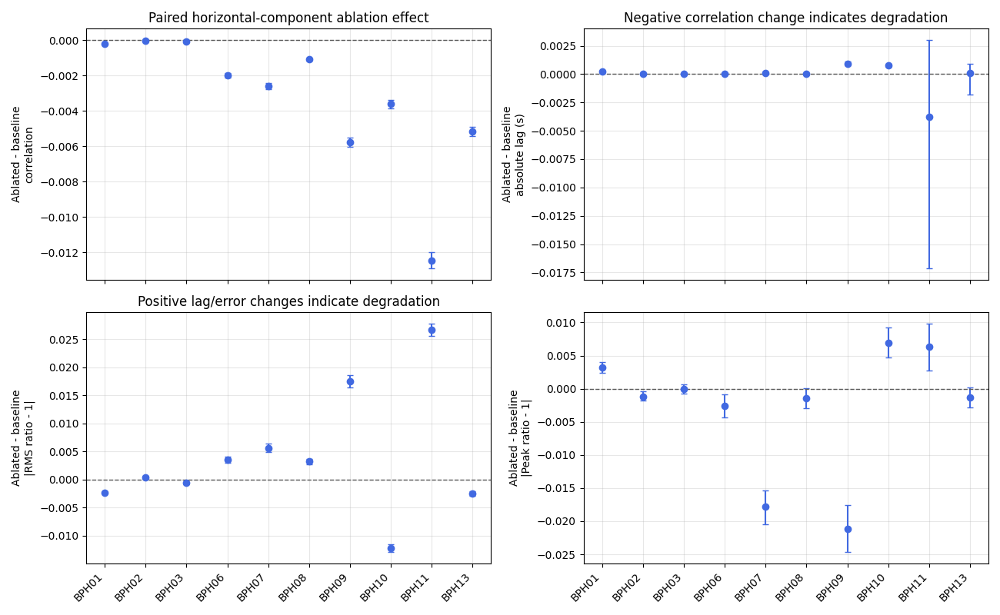

Saved figures to: /users/mronacgiannone/Virtual_Arrays/Figures/VASA_v1/Component_Ablation
CPU times: user 2.31 s, sys: 139 ms, total: 2.44 s
Wall time: 3.92 s


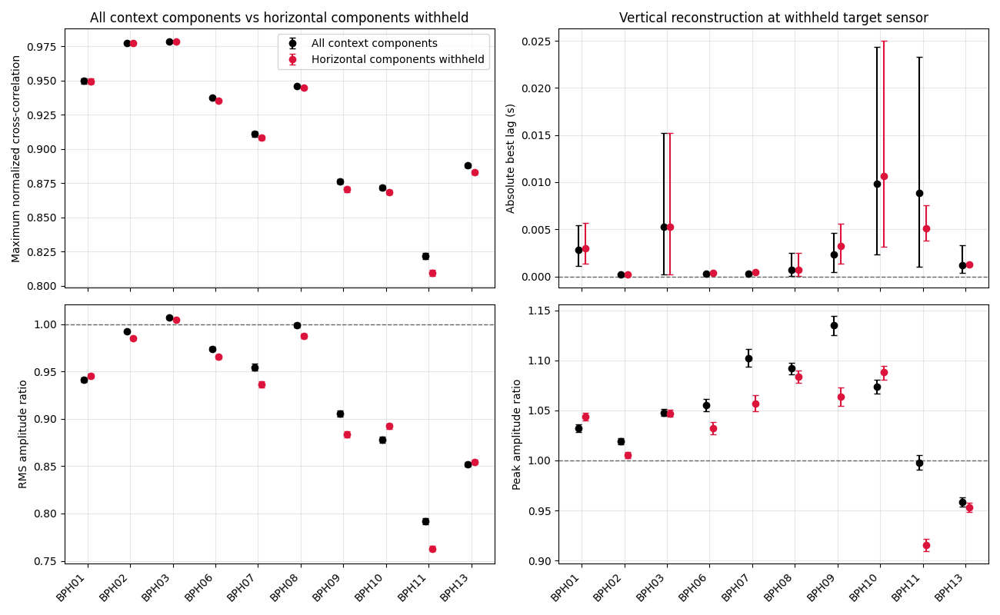

In [6]:
%%time
fig_dir = Path("Figures/VASA_v1/Component_Ablation")
fig_dir.mkdir(parents=True, exist_ok=True)

sensor_subset = None  # Or ["BPH02", "BPH09", "BPH11"]

# Baseline and ablated performance.
fig_performance, axes_performance = (
    plot_component_ablation_performance_by_sensor(
        performance_summary=component_ablation_summaries[
            "performance_by_sensor"
        ],
        station_order=station_order,
        sensor_subset=sensor_subset,
        figsize=(13, 8),
        colors={"baseline": "black", "ablated": "crimson"},
        save_path_png=fig_dir / "performance_by_sensor.png",
        dpi=300,
    )
)

# Paired changes: ablated minus baseline.
fig_effects, axes_effects = (
    plot_component_ablation_paired_effects_by_sensor(
        delta_summary=component_ablation_summaries[
            "paired_delta_by_sensor"
        ],
        station_order=station_order,
        sensor_subset=sensor_subset,
        figsize=(13, 8),
        color="royalblue",
        save_path_png=fig_dir / "paired_effects_by_sensor.png",
        dpi=300,
    )
)

plt.show()

print(f"Saved figures to: {fig_dir.resolve()}")